# 05 — Initial ABCD working point: legacy / 6D / loose comparison (2μ2e)

Compare the old and current iso–iso outputs with the initial working point and all selectable cuts held fixed. The horizontal axis is **muon-LJ isolation** and the vertical axis is **eγ-LJ isolation**. SR requires muon-LJ maximum pixel hits ≤2 **AND** eγ-LJ minimum lost hits ≥1. The single VR requires maximum pixel hits >2 **AND** minimum lost hits <1. Require $m_{\mathrm{LJ,LJ}}\ge150$ GeV and $|\Delta\phi|\ge2$ in both SR and VR.

The figures use three panels: old output at (0.25, 0.25), current 6D output at (0.25, 0.25), and current 6D output at (0.50, 0.50). The third panel changes only the isolation boundaries. MC preparation is followed by a conditional VR DATA comparison; SR DATA is excluded from the analysis.

Reproduce the initial iso–iso ABCD working point before interpreting changes in the 6D production. The three comparison cases are **old output, isolation (0.25, 0.25)**; **current 6D output, isolation (0.25, 0.25)**; and **current 6D output, isolation (0.50, 0.50)**. All three retain the same remaining selections: $m_{\mathrm{LJ,LJ}}\ge150$ GeV, $|\Delta\phi|\ge2$, and the initial displacement thresholds. Thus the first two cases test the output change at matching selectable boundaries; the last two test the isolation-boundary change within one output.

Use only the displacement-inverted VR. Both displacement requirements are inverted together with an **AND**; mixed pass/fail categories are excluded from SR and VR. The loose (0.50, 0.50) case is a comparison point, not a newly selected final WP.

The calculation begins with MC backgrounds and four displaced reference signals. A separate late section evaluates conditional **VR DATA only**; DATA SR A remains blinded. Cached DATA values in the reference notebook are historical context and are not verified inputs to this comparison.

In [1]:
from pathlib import Path
import ast
import gc
import hashlib
import json
import sys
from datetime import datetime, timezone

SIDM_DIR = next((p for p in (Path.cwd(), *Path.cwd().parents) if p.name == "sidm"), None)
if SIDM_DIR is None:
    raise RuntimeError("Run this notebook from within the sidm repository.")
if str(SIDM_DIR.parent) not in sys.path:
    sys.path.insert(0, str(SIDM_DIR.parent))
NOTEBOOK_DIR = SIDM_DIR / "studies" / "ABCD_plane_summary"
STUDIES_DIR = SIDM_DIR / "studies"

# Import coffea/pyarrow before registering NumPy 2 pickle compatibility aliases.
import coffea.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
if int(np.__version__.split(".")[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.multiarray as _numpy_multiarray
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault("numpy._core", _numpy_core)
    sys.modules.setdefault("numpy._core.multiarray", _numpy_multiarray)
    sys.modules.setdefault("numpy._core.numeric", _numpy_numeric)
plt.rcParams.update({"figure.dpi": 100, "font.size": 10, "pdf.fonttype": 42})
pd.set_option("display.max_columns", 20)


## 1. Inputs and fixed comparison settings

The initial reference is [ABCD_Study/10](../ABCD_Study/10_ABCD_CV_full_analysis.ipynb), using the current `ABCD_golden_hotspot_iso025_v1` merged outputs. The 6D inputs are the `ABCD_6D_inclusive_eHEM_skimv1_v1` merged outputs described in [00](00_6D_output_check.ipynb). Read each background file and retain only the required small iso–iso projections.

The actual old isolation histogram has **40 bins from 0 to 2**, with width 0.05; both 0.25 and 0.50 are exact stored edges. The old background yields at the initial WP have been independently recalculated from the golden files and agree with the saved SR/VR A/B/C/D, prediction, and $\kappa$ values in notebook 10. This verifies the old MC numerical reference; it does not verify cached DATA provenance.

The 18 background sample manifests agree in sample identity, input URI, and cross section between these productions. This supports comparison of the same configured inputs, but does not establish event-level equivalence. Record the resolved files, histogram/channel names, axis edges, sample inventory, and available production metadata alongside the numerical results. Full producer definitions for the 6D baseline are unavailable, so matching the selectable axes cannot by itself certify identical upstream selection.

All calculation and plotting helpers are included in this notebook. Use **Restart → Run All**; no execution of the companion notebook or temporary helper files is required.

In [2]:
TOPOLOGY = '2mu2e'
NOTEBOOK_NAME = '05_Initial_ABCD_2mu2e_6D_comparison.ipynb'
MASS_MIN = 150.0
DPHI_MIN = 2.0
PIXEL_MAX = 2
LOST_MIN = 1
ISO_SCAN = np.array([.05, .10, .15, .20, .25, .30, .40, .50])  # Common 2D grid only.
ONE_D_ISO_MAX = 1.0
SR_YIELD_YLIM = (0.0, 100.0)  # Display only; full values remain in tables.
SAVE_FIGURES = True
EXPORT_TABLES = True
OUTPUT_DIR = NOTEBOOK_DIR / '05_Initial_ABCD_2mu2e_6D_comparison_outputs'
# The optional late DATA section evaluates the VR only after the MC gate.
RUN_DATA = True
MAX_SIGNAL_FRACTION = .10  # Contamination diagnostic only.
GATE_MODE = "leakage"
LEAKAGE_LIMIT = .15
LEAKAGE_CONTEXTS = ("SR",)
SHAPE_SIGNAL_SCALE = {}  # Independent optional shape overrides; empty means raw stored weights.
SIGNAL_REFERENCES = {'mA200': '2Mu2E_200GeV_0p25GeV_1p0mm', 'mA500': '2Mu2E_500GeV_0p25GeV_0p4mm', 'mA800': '2Mu2E_800GeV_0p25GeV_0p25mm', 'mA1000': '2Mu2E_1000GeV_0p25GeV_0p2mm'}
SIGNAL_SCALE = {}
SIGNAL_NORMALIZATION_VERIFIED = False
MIN_NEFF = 10.
CONFIG = {
    "topology": TOPOLOGY,
    "legacy_dir": STUDIES_DIR / "ABCD_Study" / "ABCD_golden_hotspot_iso025_v1_bkg_merged_samples_v1",
    "current_dir": NOTEBOOK_DIR / "ABCD_6D_inclusive_eHEM_skimv1_v1_bkg_merged_samples_v1",
    "legacy_hist": 'mulj_egmlj_iso',
    "legacy_channels": {"SR": 'test_SR_2mu2e_spread_cosAlpha_mu_veto',
                        "VR": 'test_VR_2mu2e_invDisplaced_spread_cosAlpha_mu_veto'},
    "current_hist": "abcd6d_" + TOPOLOGY,
    "expected_current_channel": "abcd6d_inclusive_" + TOPOLOGY + "_dxySpread_cosAlpha_mu_veto_eHEM",
    "iso_scan": ISO_SCAN,
    "wp_tight": .25,
    "wp_loose": .5,
    "mass_min": MASS_MIN,
    "dphi_min": DPHI_MIN,
    "pixel_max": PIXEL_MAX,
    "lost_min": LOST_MIN,
    "x_label": 'Mu-LJ isolation',
    "y_label": 'EGM-LJ isolation',
    "legacy_expected": {'SR': {'A': 31.0037668, 'B': 36.8687131, 'C': 12.1434586, 'D': 228.1917382}, 'VR': {'A': 522.0823978, 'B': 1431.7119804, 'C': 1574.0242649, 'D': 3761.5662967}},
}
print("Legacy MC:", CONFIG["legacy_dir"])
print("Current MC:", CONFIG["current_dir"])
print("Columns: legacy 0.25 / current 6D 0.25 / current 6D 0.5")
print("The MC preparation does not query DATA. The late DATA section selects only VR.")

CONFIG.update(
    source_label="MC", min_neff=MIN_NEFF,
    gate_mode=GATE_MODE, leakage_limit=LEAKAGE_LIMIT, leakage_contexts=LEAKAGE_CONTEXTS,
    shape_signal_scale=SHAPE_SIGNAL_SCALE,
    one_d_iso_max=ONE_D_ISO_MAX, yield_ylim_by_context={"SR": SR_YIELD_YLIM},
    legacy_signal_dir=STUDIES_DIR / "ABCD_Study" / "ABCD_golden_hotspot_iso025_v1_signal_merged_samples_v1",
    current_signal_dir=NOTEBOOK_DIR / "ABCD_6D_inclusive_eHEM_skimv1_v1_signal_merged_samples_v1",
    legacy_data_dir=STUDIES_DIR / "ABCD_Study" / "ABCD_golden_hotspot_iso025_v1_data_merged_samples_v1",
    current_data_dir=NOTEBOOK_DIR / "ABCD_6D_inclusive_eHEM_skimv1_v1_data_merged_samples_v1",
    signal_references=SIGNAL_REFERENCES, signal_scale=SIGNAL_SCALE,
    signal_reference_avg_transverse_cm=30.0,
    max_signal_fraction=MAX_SIGNAL_FRACTION, run_data=RUN_DATA,
    expected_data_count=68,
)
DATA_RESULTS = None
print("Signal references:", SIGNAL_REFERENCES)
print("MC preparation first; conditional VR DATA is enabled in the late section:", RUN_DATA)


Legacy MC: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_golden_hotspot_iso025_v1_bkg_merged_samples_v1
Current MC: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_skimv1_v1_bkg_merged_samples_v1
Columns: legacy 0.25 / current 6D 0.25 / current 6D 0.5
The MC preparation does not query DATA. The late DATA section selects only VR.
Signal references: {'mA200': '2Mu2E_200GeV_0p25GeV_1p0mm', 'mA500': '2Mu2E_500GeV_0p25GeV_0p4mm', 'mA800': '2Mu2E_800GeV_0p25GeV_0p25mm', 'mA1000': '2Mu2E_1000GeV_0p25GeV_0p2mm'}
MC preparation first; conditional VR DATA is enabled in the late section: True


## 2. Calculation conventions and shared helpers

Isolation passes when it is **strictly below** its boundary. Define A=pass/pass, B=fail/pass, C=pass/fail, and D=fail/fail. Sum the background components first, then calculate

$$P=\frac{BC}{D},\qquad \kappa=\frac{A}{P},\qquad N_{\mathrm{eff}}=\frac{(\sum w)^2}{\sum w^2}.$$

The total-background prediction is generally different from the sum of separate process predictions because $BC/D$ is nonlinear. Keep component yields and total-background closure distinct. Use the stored weighted sums and variances directly; do not apply luminosity or cross-section normalization again.

For the matched comparison, exclude isolation underflow and retain isolation overflow in the fail regions, following notebook 10. Apply the same convention to old and 6D projections. Displacement quantities use muons from PF+DSA and eγ constituents from electrons+photons. The photon lost-hit sentinel 999 lies in displacement-axis overflow and is retained where the lost-hit requirement selects it; it is not an isolation value. The mass and angular cuts are applied explicitly to the stored axes.

Yield errors are $\sqrt{\sum w^2}$. Prediction and $\kappa$ errors use first-order propagation of the disjoint A/B/C/D variances. Match the actual ratio conventions of notebook 10: prediction is undefined for a nonpositive D or nonfinite control input; κ requires a positive prediction, and its propagated uncertainty additionally requires positive A. Nonpositive B/C yields are flagged explicitly without changing the legacy calculator rules. Retain low-statistics cases and label their support; first-order errors are not exact low-count intervals or significances. Old/new productions and nested WPs may share events, so do not interpret their differences using an independent-sample significance.

Correlation uses common regular iso 0–2 bins, with no flow or high-tail folding. Signal ratios use each reference separately; the late VR DATA section uses the existing conditional four-reference displaced gate.

Use **four displaced signal references**, one at each bound-state mass, with $m_{Z_d}=0.25$ GeV. Their proper lifetimes are chosen to preserve the previous displaced reference's configured average lab-frame transverse decay length of **30 cm**:

| $m_A$ (GeV) | $c\tau$ (mm) | Grid conversion factor (cm/mm) | Configured average transverse decay length (cm) |
|---:|---:|---:|---:|
| 200 | 1.00 | 30 | 30 |
| 500 | 0.40 | 75 | 30 |
| 800 | 0.25 | 120 | 30 |
| 1000 | 0.20 | 150 | 30 |

The conversion follows [signal_grid.yaml](../../configs/signal_grid.yaml). The 30 cm value is a configured average lab-frame quantity, not the proper lifetime or a reconstructed event displacement. Use the corresponding 2Mu2E or 4Mu sample for the notebook's decay topology. Compare each hypothesis separately in the old and current productions; do not sum signals from different masses. No prompt reference is loaded. These four benchmarks do not cover the full signal grid, and their stored normalization remains provisional.

The DATA gate uses **SR signal leakage only**. Each of the four displaced references must independently satisfy
\(S_{BCD}/S_{ABCD}<0.15\); equality fails. Contamination \(S/(S+B_{MC})\) and VR leakage remain diagnostics and do not veto a point in this mode.
An empty, negative, or nonfinite signal support remains unsupported. `MC gate blocked` marks a failed reference-signal criterion, not a missing DATA file or an observed DATA closure test.


In [3]:
"""Streaming MC-only reproduction of the initial isolation ABCD study.

This source is embedded into the two comparison notebooks so each notebook can
be run without an extra repository module. Stored weighted yields are used as-is.
"""

from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import json
import sys

import coffea.util
import numpy as np
import pandas as pd
import yaml

# Import coffea before providing NumPy 2 pickle aliases in a NumPy 1 environment.
if int(np.__version__.split(".")[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.multiarray as _numpy_multiarray
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault("numpy._core", _numpy_core)
    sys.modules.setdefault("numpy._core.multiarray", _numpy_multiarray)
    sys.modules.setdefault("numpy._core.numeric", _numpy_numeric)

COMPARISON_COMPONENTS = ("QCD", "DY", "TTJets", "Diboson")
COMPARISON_BENCHMARKS = ("legacy_025", "sixd_025", "sixd_050")
COMPARISON_CONTEXTS = ("SR", "VR")
COMPARISON_VARIABLES = ("iso0", "iso1", "disp0", "disp1", "abs_dphi", "ljlj_mass")


def _comparison_json(value):
    def convert(item):
        if isinstance(item, (set, frozenset)):
            return sorted(item, key=str)
        if isinstance(item, np.generic):
            return item.item()
        if isinstance(item, np.ndarray):
            return item.tolist()
        if isinstance(item, Path):
            return str(item)
        return str(item)
    return json.dumps(value, sort_keys=True, default=convert)


def _comparison_hash(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def _comparison_group(sample):
    if sample.startswith("QCD_"):
        return "QCD"
    if sample.startswith("DYJetsTo"):
        return "DY"
    if sample == "TTJets":
        return "TTJets"
    if sample in {"WW", "WZ", "ZZ"}:
        return "Diboson"
    raise ValueError(f"Unexpected MC background sample: {sample}")


def _comparison_split(edges, threshold):
    matches = np.flatnonzero(np.isclose(edges, float(threshold), rtol=0, atol=1e-12))
    if len(matches) != 1:
        raise ValueError(f"A requested threshold is not a unique stored bin edge: {threshold}")
    return int(matches[0]) + 1  # Numeric underflow is index zero.


def comparison_one_d_thresholds(plane, scan_axis, config):
    """Return this plane's stored positive isolation edges up to the scan maximum.

    Native coordinates are retained exactly. No bin-edge snapping, interpolation
    or artificial shared scan grid is applied to legacy/current comparisons.
    """
    if scan_axis not in {"x", "y"}:
        raise ValueError(f"Unknown one-dimensional scan direction: {scan_axis}")
    maximum = float(config.get("one_d_iso_max", 1.))
    if not np.isfinite(maximum) or maximum <= 0:
        raise ValueError("The one-dimensional isolation scan maximum must be finite and positive.")
    edges = np.asarray(plane["xedges" if scan_axis == "x" else "yedges"], dtype=float)
    thresholds = edges[(edges > 0) & (edges <= maximum)].copy()
    if not len(thresholds):
        raise ValueError("No positive native isolation edges lie within the requested scan range.")
    return thresholds


def _comparison_validate_arrays(values, variances):
    if variances is None or values.shape != variances.shape:
        raise ValueError("Weighted values and sumw2 must have the same shape.")
    if not np.isfinite(values).all() or not np.isfinite(variances).all():
        raise ValueError("The selected histogram contains nonfinite weights or sumw2.")
    if np.any(variances < 0):
        raise ValueError("The selected histogram contains negative sumw2.")


def _comparison_plane(values, variances, xedges, yedges):
    values = np.asarray(values, dtype=float).copy()
    variances = np.asarray(variances, dtype=float).copy()
    _comparison_validate_arrays(values, variances)
    xedges = np.asarray(xedges, dtype=float).copy()
    yedges = np.asarray(yedges, dtype=float).copy()
    if values.shape != (len(xedges) + 1, len(yedges) + 1):
        raise ValueError("The 2D plane must contain both numeric flow bins on each axis.")
    return dict(values=values, variances=variances, xedges=xedges, yedges=yedges)


def _comparison_add(target, incoming, component):
    if target is None:
        target = _comparison_plane(incoming["values"], incoming["variances"],
                                   incoming["xedges"], incoming["yedges"])
        target["values"][:] = 0
        target["variances"][:] = 0
        target["components"] = {}
    if not all(np.array_equal(target[key], incoming[key]) for key in ("xedges", "yedges")):
        raise ValueError("Cannot combine planes with different numeric bin edges.")
    target["values"] += incoming["values"]
    target["variances"] += incoming["variances"]
    if component not in target["components"]:
        target["components"][component] = dict(
            values=np.zeros_like(incoming["values"]),
            variances=np.zeros_like(incoming["variances"]))
    target["components"][component]["values"] += incoming["values"]
    target["components"][component]["variances"] += incoming["variances"]
    return target


def _comparison_payload(path, source):
    loaded = coffea.util.load(path)
    outputs = loaded.get("out", loaded) if isinstance(loaded, dict) else None
    if outputs is None or set(outputs) != {path.stem}:
        raise ValueError(f"The payload sample identity does not match its file name: {path}")
    payload = outputs[path.stem]
    metadata = payload.get("metadata", {})
    if set(metadata.get("is_data", ())) != {False}:
        raise ValueError(f"Only explicitly identified MC backgrounds may be loaded: {path}")
    if set(metadata.get("unweighted_hist", ())) != {False}:
        raise ValueError(f"A weighted production is required: {path}")
    if {str(value) for value in metadata.get("year", ())} != {"2018"}:
        raise ValueError(f"The payload must have a unique 2018 year: {path}")
    if "hists" not in payload or "cutflow" not in payload:
        raise ValueError(f"Missing histograms or production cutflows: {path}")
    return loaded, payload


def _comparison_validate_hist(histogram, path):
    if histogram.storage_type.__name__ != "Weight":
        raise ValueError(f"Weight storage is required: {path}")
    for axis in histogram.axes:
        if not axis.traits.discrete and not (axis.traits.underflow and axis.traits.overflow):
            raise ValueError(f"Numeric flow bins are required: {path}/{axis.name}")


def _comparison_legacy_planes(payload, path, config):
    histogram = payload["hists"][config["legacy_hist"]]
    _comparison_validate_hist(histogram, path)
    expected_axis_names = ("channel", "mu_lj_iso", "egm_lj_iso") if config["topology"] == "2mu2e" else (
        "channel", "mulj0_iso", "mulj1_iso")
    # The old 4mu names are checked against their ordered physics labels below.
    if config["topology"] == "2mu2e" and tuple(axis.name for axis in histogram.axes) != expected_axis_names:
        raise ValueError(f"Legacy isolation axis order mismatch: {path}")
    if len(histogram.axes) != 3 or histogram.axes[0].name != "channel":
        raise ValueError(f"Legacy channel + two isolation axes are required: {path}")
    result = {}
    for context, channel in config["legacy_channels"].items():
        if channel not in list(histogram.axes["channel"]):
            raise ValueError(f"The initial-study channel is missing: {path}/{channel}")
        selected = histogram[{"channel": channel}]
        if config["topology"] == "4mu":
            names = tuple(axis.name for axis in selected.axes)
            if names not in (("mulj0_iso", "mulj1_iso"), ("mu_lj0_iso", "mu_lj1_iso")):
                raise ValueError(f"Legacy leading/subleading isolation axis order mismatch: {path}: {names}")
        for axis in selected.axes:
            if len(axis.edges) != 41 or not np.allclose(axis.edges, np.linspace(0, 2, 41), rtol=0, atol=1e-12):
                raise ValueError(f"Initial notebook 10 requires the actual 40-bin isolation plane over [0, 2]: {path}")
        result[context] = _comparison_plane(selected.values(flow=True), selected.variances(flow=True),
                                            selected.axes[0].edges, selected.axes[1].edges)
    return result


def _comparison_current_cube(payload, path, config):
    expected_hists = {f"abcd6d_{topology}" for topology in ("2mu2e", "4mu")} | {
        f"abcd6d_ref_{topology}_{pair}" for topology in ("2mu2e", "4mu")
        for pair in ("iso0_vs_iso1", "iso0_vs_abs_dphi", "disp0_vs_disp1")}
    if set(payload["hists"]) != expected_hists:
        raise ValueError(f"The current 6D campaign histogram schema differs: {path}")
    histogram = payload["hists"][config["current_hist"]]
    _comparison_validate_hist(histogram, path)
    if tuple(axis.name for axis in histogram.axes) != ("channel",) + COMPARISON_VARIABLES:
        raise ValueError(f"Current 6D axis order mismatch: {path}")
    channel_axis = histogram.axes["channel"]
    if (list(channel_axis) != [config["expected_current_channel"]]
            or not channel_axis.traits.discrete
            or channel_axis.traits.underflow or channel_axis.traits.overflow):
        raise ValueError(f"Current topology channel identity/flow mismatch: {path}")
    expected_edges = {
        "iso0": [0, .05, .1, .15, .2, .25, .3, .4, .5, .75, 1, 2, 5],
        "iso1": [0, .05, .1, .15, .2, .25, .3, .4, .5, .75, 1, 2, 5],
        "disp0": np.arange(-.5, 12, 1),
        "disp1": np.arange(-.5, 10 if config["topology"] == "2mu2e" else 12, 1),
        "abs_dphi": [0, .5, 1, 1.5, 2, 2.2, 2.4, 2.6, 2.7, 2.8, 2.9, 3, 3.05, 3.1, np.pi],
        "ljlj_mass": [0, 50, 100, 150, 200, 300, 400, 600, 800, 1000, 1500, 2500],
    }
    edges = {name: np.asarray(histogram.axes[name].edges, dtype=float) for name in COMPARISON_VARIABLES}
    for name in COMPARISON_VARIABLES:
        expected = np.asarray(expected_edges[name], dtype=float)
        if edges[name].shape != expected.shape or not np.allclose(edges[name], expected, rtol=0, atol=1e-12):
            raise ValueError(f"Current campaign stored bin edges differ: {path}/{name}")
    weights, variances = histogram.values(flow=True), histogram.variances(flow=True)
    expected_shape = (1,) + tuple(len(edges[name]) + 1 for name in COMPARISON_VARIABLES)
    if variances is None or weights.shape != expected_shape or variances.shape != expected_shape:
        raise ValueError(f"Current 6D weighted values/variance shape mismatch: {path}")
    return weights[0], variances[0], edges


def _comparison_project(weights, variances, edges, context, config, mass_min, dphi_min):
    pixel = _comparison_split(edges["disp0"], config["pixel_max"] + .5)
    first = slice(None, pixel) if context == "SR" else slice(pixel, None)
    if config["topology"] == "2mu2e":
        lost = _comparison_split(edges["disp1"], config["lost_min"] - .5)
        second = slice(lost, None) if context == "SR" else slice(None, lost)
    else:
        pixel1 = _comparison_split(edges["disp1"], config["pixel_max"] + .5)
        second = slice(None, pixel1) if context == "SR" else slice(pixel1, None)
    mass = slice(None) if mass_min is None else slice(_comparison_split(edges["ljlj_mass"], mass_min), None)
    dphi = slice(None) if dphi_min is None else slice(_comparison_split(edges["abs_dphi"], dphi_min), None)
    indices = (slice(None), slice(None), first, second, dphi, mass)
    w, v = weights[indices], variances[indices]
    _comparison_validate_arrays(w, v)
    return _comparison_plane(w.sum(axis=(2, 3, 4, 5)), v.sum(axis=(2, 3, 4, 5)),
                             edges["iso0"], edges["iso1"])


def _comparison_regions(plane, tx, ty, include_iso_underflow=False):
    ix = _comparison_split(plane["xedges"], tx)
    iy = _comparison_split(plane["yedges"], ty)
    start = 0 if include_iso_underflow else 1
    slices = {"A": (slice(start, ix), slice(start, iy)),
              "B": (slice(ix, None), slice(start, iy)),
              "C": (slice(start, ix), slice(iy, None)),
              "D": (slice(ix, None), slice(iy, None))}
    regions = {}
    for region, index in slices.items():
        value = float(plane["values"][index].sum())
        variance = float(plane["variances"][index].sum())
        regions[region] = dict(value=value, variance=variance, error=np.sqrt(variance),
                               neff=value**2 / variance if variance > 0 else np.nan)
    return regions


def abcd_statistics(plane, tx, ty, include_iso_underflow=False, min_neff=10.):
    """Match notebook 10 prediction/closure conventions; annotate edge cases.

    B, C and D are total background sums. No negative sumw is clipped. The
    relative-error formula intentionally reproduces notebook 10's zero-sideband
    uncertainty convention; its mathematical limitation is flagged in status.
    """
    regions = _comparison_regions(plane, tx, ty, include_iso_underflow)
    row = dict(tx=float(tx), ty=float(ty), pred=np.nan, pred_error=np.nan,
               kappa=np.nan, kappa_error=np.nan, pull=np.nan,
               status="UNDEFINED_PREDICTION", kappa_status="UNDEFINED_PREDICTION")
    for name, item in regions.items():
        row.update({name: item["value"], "var_" + name: item["variance"],
                    name + "_error": item["error"], "neff_" + name: item["neff"]})
    neffs = np.array([regions[name]["neff"] for name in "ABCD"])
    row.update(neff_min=float(np.min(neffs)), min_neff=float(np.min(neffs)),
               min_sideband_neff=float(np.min(neffs[1:])),
               low_stat=bool(not np.all(np.isfinite(neffs) & (neffs >= min_neff))))
    a, b, c, d = (regions[name]["value"] for name in "ABCD")
    ea, eb, ec, ed = (regions[name]["error"] for name in "ABCD")
    if d <= 0 or not np.all(np.isfinite([b, eb, c, ec, d, ed])):
        row["status"] = "NONPOSITIVE_D_OR_NONFINITE_SIDEBAND"
        row["kappa_status"] = row["status"]
        return row
    pred = b * c / d
    terms = [(eb / b)**2 if b else 0., (ec / c)**2 if c else 0., (ed / d)**2]
    epred = abs(pred) * np.sqrt(sum(terms))
    row.update(pred=pred, pred_error=epred)
    if b == 0 or c == 0:
        row["status"] = "ZERO_SIDEBAND_LEGACY_ZERO_PREDICTION_ERROR"
    elif b < 0 or c < 0:
        row["status"] = "NEGATIVE_SIDEBAND_RETAINED"
    else:
        row["status"] = "LOW_STAT_SIDEBAND" if not np.all(
            np.isfinite(neffs[1:]) & (neffs[1:] >= min_neff)) else "OK"
    if np.isfinite(a) and pred > 0:
        row["kappa"] = a / pred
        if a > 0:
            row["kappa_error"] = abs(row["kappa"]) * np.sqrt((ea / a)**2 + (epred / pred)**2)
            row["kappa_status"] = "LOW_STAT" if row["low_stat"] else "OK"
        else:
            row["kappa_status"] = "NONPOSITIVE_A_LEGACY_KAPPA_ERROR_UNDEFINED"
    else:
        row["kappa_status"] = "NONPOSITIVE_PREDICTION_OR_NONFINITE_A"
    if np.isfinite(a) and ea**2 + epred**2 > 0:
        row["pull"] = (a - pred) / np.sqrt(ea**2 + epred**2)
    return row


def _comparison_read_metadata(path, source):
    meta_path = path.with_suffix(".meta.yaml")
    if not meta_path.is_file():
        raise FileNotFoundError(f"Production metadata are needed for the input audit: {meta_path}")
    with meta_path.open() as handle:
        meta = yaml.safe_load(handle)
    entries = [sample for sample in meta.get("samples", ()) if sample["name"] == path.stem]
    if len(entries) != 1 or meta.get("n_samples") != 1:
        raise ValueError(f"Production metadata must identify exactly one matching sample: {meta_path}")
    sample = entries[0]
    files = tuple(str(uri) for uri in sample.get("files", ()))
    if not files or len(files) != int(sample["n_files"]) or len(files) != len(set(files)):
        raise ValueError(f"Invalid or duplicate production input file list: {meta_path}")
    if meta.get("unweighted_hist") is not False:
        raise ValueError(f"Metadata do not describe weighted production: {meta_path}")
    row = dict(source=source, sample=path.stem, component=_comparison_group(path.stem),
               file=str(path.resolve()), bytes=path.stat().st_size, sha256=_comparison_hash(path),
               metadata_file=str(meta_path.resolve()), metadata_sha256=_comparison_hash(meta_path),
               production_created_utc=meta.get("created_utc"),
               producer_coffea_path=meta.get("coffea_path"),
               sidm_commit=meta.get("sidm_commit"), coffea_version=meta.get("coffea_version"),
               schema=meta.get("schema"), chunksize=meta.get("chunksize"),
               n_input_files=len(files), xsec_pb=float(sample["xsec_pb"]),
               input_uri_sha256=hashlib.sha256(_comparison_json(sorted(files)).encode()).hexdigest(),
               selection_definition_sha256=hashlib.sha256(_comparison_json(meta.get("selections", [])).encode()).hexdigest(),
               extra_scale=1., normalization="Stored weighted sumw/sumw2; no additional lumi/xsec rescaling")
    return meta, files, row


def _comparison_cutflow_rows(payload, path, source, config):
    if source == "legacy":
        channels = config["legacy_channels"]
    else:
        channels = {"Inclusive": config["expected_current_channel"]}
    rows = []
    for context, channel in channels.items():
        flow = payload["cutflow"].get(channel)
        if flow is None or not isinstance(getattr(flow, "rows", None), dict):
            raise ValueError(f"An auditable SimpleCutflow is missing: {path}/{channel}")
        for sequence, (cut, counts) in enumerate(flow.rows.items()):
            rows.append(dict(source=source, sample=path.stem, component=_comparison_group(path.stem),
                             context=context, channel=channel, sequence=sequence, cut=cut,
                             raw=float(counts["raw"]), weighted=float(counts["weighted"]),
                             interpretation="Cumulative producer cutflow; selections and pair ordering differ"))
    return rows


def _comparison_selection_audit(config, metadata_examples, cutflow):
    rows = []
    def add(selection, legacy, current, status, evidence):
        rows.append(dict(selection=selection, legacy=legacy, current=current,
                         status=status, evidence=evidence))
    topology = config["topology"]
    displacement = ("SR: mu max pixel <= 2 AND egamma min lost >= 1; VR: mu max pixel > 2 AND egamma min lost < 1"
                    if topology == "2mu2e" else "SR: both mu-LJs max pixel <= 2; VR: both mu-LJs max pixel > 2")
    add("Isolation WP", "x < 0.25, y < 0.25", "0.25 reproduction; 0.5 loose comparison", "CONTROLLED_COMPARISON",
        "All thresholds are validated against actual histogram edges.")
    add("Pair mass", "M(LJ,LJ) >= 150 GeV", "M(LJ,LJ) >= 150 GeV", "MATCHED_BOUNDARY",
        "Legacy selection metadata and current ljlj_mass >= 150 projection.")
    add("Pair absolute delta-phi", "|delta-phi| >= 2", "|delta-phi| >= 2", "MATCHED_BOUNDARY",
        "Legacy selection metadata and current abs_dphi >= 2 projection.")
    add("Displacement regions", displacement, displacement, "MATCHED_BOUNDARY_DIFFERENT_PAIR_ORDER",
        "Both displacement conditions use AND. Only inverse displacement defines VR.")
    add("Isolation numeric underflow", "Excluded", "Excluded in primary comparison", "MATCHED_FLOW_POLICY",
        "Notebook 10 values_variances; the diagnostic table also evaluates inclusion.")
    add("Isolation numeric overflow", "Included in fail regions", "Included in fail regions", "MATCHED_FLOW_POLICY",
        "Overflow includes double-overflow exactly once; no cap at visible iso=2.")
    add("Weighted normalization", "Stored sumw and sumw2", "Stored sumw and sumw2", "NO_ADDITIONAL_SCALE",
        "Producer postprocess scales weighted MC histograms; input xsec and URI manifests are checked.")
    old_flags = bool((cutflow.source.eq("legacy") & cutflow.cut.eq("pass flags")).any())
    new_flags = bool((cutflow.source.eq("sixd") & cutflow.cut.eq("pass flags")).any())
    add("Event flags", f"pass flags in cutflow: {old_flags}", f"pass flags in cutflow: {new_flags}",
        "CONFIRMED_PRODUCTION_CHANGE" if old_flags != new_flags else "SAME_CUTFLOW_LABEL_PRESENCE",
        "Actual background payload cutflow labels; removed events cannot be recovered from a histogram.")
    add("LJ pair selection", "Displacement filter before pair selection", "Fixed inclusive pair, then displacement slicing",
        "NOT_EVENT_LEVEL_EQUIVALENT", "Histogram slicing cannot reselect a different LJ pair.")
    add("Muon-LJ spread cuts", "dzSpread_mu <= 50 AND vxySpread_mu <= 50 AND dzSpread_pf <= 10 AND vxySpread_pf <= 10",
        "dxySpread appears in the channel label; the frozen numerical definition is unavailable",
        "UNVERIFIED_CURRENT_DEFINITION", "Legacy metadata postLj_obj_cuts; current producer metadata report <not found>.")
    add("LJ kinematics and multiplicity", "LJ pT > 30 GeV, |eta| < 2.4; muon-LJ Mu >= 2; >=2 LJs; topology-specific LJ multiplicity",
        "Multiplicity labels are present in the cutflow; complete object cuts are unavailable",
        "UNVERIFIED_CURRENT_OBJECT_DEFINITION", "Legacy metadata obj/postLj cuts and actual current cutflow labels.")
    add("Pre-LJ electron identification", "eta-phi_veto; pT > 10 GeV; |eta| < 2.4; MVANonIsoWPL",
        "Not recoverable from current <not found> producer definition", "UNVERIFIED_CURRENT_DEFINITION",
        "Legacy metadata obj_cuts.electrons; current yield differences do not establish which identification cut changed.")
    add("Pre-LJ PF muon identification", "eta-phi_veto; looseID; pT > 5 GeV; |eta| < 2.4",
        "Not recoverable from current <not found> producer definition", "UNVERIFIED_CURRENT_DEFINITION",
        "Legacy metadata obj_cuts.muons.")
    add("Pre-LJ DSA muon identification", "eta-phi_veto; pT > 10 GeV; |eta| < 2.4; displaced ID; all",
        "Not recoverable from current <not found> producer definition", "UNVERIFIED_CURRENT_DEFINITION",
        "Legacy metadata obj_cuts.dsaMuons.")
    add("Pre-LJ photon identification and veto", "eta-phi_veto; pT > 20 GeV; |eta| < 2.5; Custom Cutbased; pixelSeed; Photon DR Veto 0p025",
        "Not recoverable from current <not found> producer definition", "UNVERIFIED_CURRENT_DEFINITION",
        "Legacy metadata obj_cuts.photons. The eHEM channel suffix alone is not an exhaustive numerical definition.")
    for cut, meaning in (("pass triggers", "Trigger selection"), ("PV filter", "Primary vertex filter"),
                         ("all cosAlpha(mu, mu) > -0.99", "Muon cosmic veto")):
        present_old = bool((cutflow.source.eq("legacy") & cutflow.cut.eq(cut)).any())
        present_new = bool((cutflow.source.eq("sixd") & cutflow.cut.eq(cut)).any())
        add(meaning, f"{cut}; label present: {present_old}", f"{cut}; label present: {present_new}",
            "MATCHED_CUTFLOW_LABEL_ONLY" if present_old and present_new else "CUTFLOW_LABEL_DIFFERENCE",
            "Actual producer cutflow labels confirm application; complete current implementation is unavailable.")
    add("Muon constituent provenance", "LJ muons combine PF and DSA constituents; DSA trkNumPixelHits is assigned zero",
        "Nominal disp0/disp1 interpretation uses the same PF+DSA max-pixel convention; frozen producer code unavailable",
        "NOMINAL_MAPPING_WITH_PRODUCER_LIMIT", "definitions/cuts.py displaced uses mu_ljs.muons, not only pfMuons; tools/sidm_processor.py make_vector assigns DSA pixel hits=0.")
    if topology == "2mu2e":
        add("e/gamma displacement constituent provenance", "min lostHits over electrons AND photons; photons have lostHits=999",
            "disp1 is interpreted as minimum e/gamma lostHits; numeric overflow is retained in lostHits >= 1",
            "NOMINAL_MAPPING_WITH_PRODUCER_LIMIT", "definitions/cuts.py egm displaced uses egamma; tools/sidm_processor.py make_vector assigns photon lostHits=999. It is not an electron-only minimum.")
    for source in ("legacy", "sixd"):
        definitions = {entry["name"]: entry.get("definition", "<not found>")
                       for entry in metadata_examples[source].get("selections", [])}
        selected_channels = (config["legacy_channels"].values() if source == "legacy" else [config["expected_current_channel"]])
        for channel in selected_channels:
            definition = definitions.get(channel, "<not found>")
            add(f"Producer selection definition: {source}/{channel}",
                _comparison_json(definition) if source == "legacy" else "See legacy producer metadata",
                _comparison_json(definition) if source == "sixd" else "See current producer metadata",
                "PRODUCER_DEFINITION_UNAVAILABLE" if definition == "<not found>" else "METADATA_DEFINITION_AVAILABLE",
                "Verbatim metadata definition; absence is not evidence of an omitted cut.")
    return pd.DataFrame(rows)


def run_comparison(config):
    """Load only background MC and return three benchmarks plus auditable tables."""
    config = dict(config)
    topology = config["topology"]
    if topology not in {"2mu2e", "4mu"}:
        raise ValueError(f"Unknown topology: {topology}")
    defaults = dict(wp_tight=.25, wp_loose=.5, mass_min=150., dphi_min=2., pixel_max=2., lost_min=1.,
                    current_hist=f"abcd6d_{topology}",
                    expected_current_channel=f"abcd6d_inclusive_{topology}_dxySpread_cosAlpha_mu_veto_eHEM",
                    iso_scan=[.05, .10, .15, .20, .25, .30, .40, .50], one_d_iso_max=1., min_neff=10.,
                    expected_background_count=18, include_dphi_diagnostic=True, legacy_expected={})
    for key, value in defaults.items():
        config.setdefault(key, value)
    for key, initial_value in dict(wp_tight=.25, wp_loose=.5, mass_min=150., dphi_min=2., pixel_max=2., lost_min=1.).items():
        if config[key] is None or not np.isclose(float(config[key]), initial_value, rtol=0, atol=1e-12):
            raise ValueError(f"The initial-study comparison requires {key}={initial_value:g}; use the dedicated diagnostic variations for departures.")
    if set(config["legacy_channels"]) != set(COMPARISON_CONTEXTS):
        raise ValueError("Only SR and the single inverse-displacement VR may be used.")
    # Add the sidm parent before loading pickled sidm.tools.cutflow objects.
    legacy_dir, current_dir = Path(config["legacy_dir"]), Path(config["current_dir"])
    sidm_dir = next((p for p in (current_dir.resolve(), *current_dir.resolve().parents) if p.name == "sidm"), None)
    if sidm_dir is not None and str(sidm_dir.parent) not in sys.path:
        sys.path.insert(0, str(sidm_dir.parent))
    paths = {"legacy": sorted(legacy_dir.glob("*.coffea")), "sixd": sorted(current_dir.glob("*.coffea"))}
    sample_sets = {source: {path.stem for path in source_paths} for source, source_paths in paths.items()}
    if sample_sets["legacy"] != sample_sets["sixd"]:
        raise ValueError("Legacy and current background sample names differ.")
    if len(paths["legacy"]) != int(config["expected_background_count"]):
        raise ValueError(f"Expected {config['expected_background_count']} MC backgrounds in each production.")
    if not paths["legacy"] or any(path.stat().st_size <= 0 for source_paths in paths.values() for path in source_paths):
        raise ValueError("All input background files must exist and be nonempty.")
    for sample in sample_sets["legacy"]:
        _comparison_group(sample)

    manifest_rows, cutflow_rows, metadata_examples = [], [], {}
    uri_lists, per_sample = {}, {}
    planes = {benchmark: {context: None for context in COMPARISON_CONTEXTS} for benchmark in COMPARISON_BENCHMARKS}
    diagnostic_planes = {"mass_inclusive": {context: None for context in COMPARISON_CONTEXTS}}
    if config["include_dphi_diagnostic"]:
        diagnostic_planes["dphi_inclusive"] = {context: None for context in COMPARISON_CONTEXTS}
    for source in ("legacy", "sixd"):
        for index, path in enumerate(paths[source], 1):
            meta, uris, manifest_row = _comparison_read_metadata(path, source)
            metadata_examples.setdefault(source, meta)
            if source == "legacy":
                uri_lists[path.stem] = tuple(sorted(uris))
                per_sample[path.stem] = manifest_row
                manifest_row.update(input_uri_match=True, xsec_match=True)
            else:
                old_row = per_sample[path.stem]
                uri_match = tuple(sorted(uris)) == uri_lists[path.stem]
                xsec_match = bool(np.isclose(manifest_row["xsec_pb"], old_row["xsec_pb"], rtol=0, atol=1e-12))
                manifest_row.update(input_uri_match=uri_match, xsec_match=xsec_match)
                if not uri_match or not xsec_match:
                    raise ValueError(f"The production input URI/xsec manifests differ: {path.stem}")
            loaded = payload = weights = variances = edges = incoming = selected = None
            try:
                loaded, payload = _comparison_payload(path, source)
                manifest_row.update(payload_metadata=_comparison_json(payload["metadata"]),
                                    n_evts=int(payload["metadata"].get("n_evts", 0)),
                                    scaled_sum_weights=float(payload["metadata"].get("scaled_sum_weights", np.nan)))
                if source == "sixd":
                    old_row = per_sample[path.stem]
                    manifest_row["n_evts_match"] = manifest_row["n_evts"] == old_row["n_evts"]
                    manifest_row["scaled_sum_weights_match"] = bool(np.isclose(
                        manifest_row["scaled_sum_weights"], old_row["scaled_sum_weights"], rtol=1e-10, atol=1e-8))
                else:
                    manifest_row.update(n_evts_match=True, scaled_sum_weights_match=True)
                cutflow_rows.extend(_comparison_cutflow_rows(payload, path, source, config))
                group = _comparison_group(path.stem)
                if source == "legacy":
                    selected = _comparison_legacy_planes(payload, path, config)
                    for context, incoming in selected.items():
                        planes["legacy_025"][context] = _comparison_add(planes["legacy_025"][context], incoming, group)
                else:
                    weights, variances, edges = _comparison_current_cube(payload, path, config)
                    for context in COMPARISON_CONTEXTS:
                        incoming = _comparison_project(weights, variances, edges, context, config,
                                                       config["mass_min"], config["dphi_min"])
                        for benchmark in ("sixd_025", "sixd_050"):
                            planes[benchmark][context] = _comparison_add(planes[benchmark][context], incoming, group)
                        incoming = _comparison_project(weights, variances, edges, context, config, None, config["dphi_min"])
                        diagnostic_planes["mass_inclusive"][context] = _comparison_add(
                            diagnostic_planes["mass_inclusive"][context], incoming, group)
                        if config["include_dphi_diagnostic"]:
                            incoming = _comparison_project(weights, variances, edges, context, config, config["mass_min"], None)
                            diagnostic_planes["dphi_inclusive"][context] = _comparison_add(
                                diagnostic_planes["dphi_inclusive"][context], incoming, group)
                manifest_rows.append(manifest_row)
            finally:
                loaded = payload = weights = variances = edges = incoming = selected = None
                gc.collect()
            print(f"{source}: loaded background {index}/{len(paths[source])}: {path.stem}")

    cutflow = pd.DataFrame(cutflow_rows)
    aggregated = cutflow.groupby(["source", "context", "channel", "sequence", "cut"], as_index=False, sort=False)[
        ["raw", "weighted"]].sum()
    aggregated["sample"], aggregated["component"] = "Total", "Total"
    aggregated["interpretation"] = "Cumulative producer cutflow; selections and pair ordering differ"
    cutflow = pd.concat([cutflow, aggregated], ignore_index=True)
    region_rows, closure_rows, scan_rows, flow_rows, cut_rows = [], [], [], [], []
    for benchmark in COMPARISON_BENCHMARKS:
        wp = config["wp_loose"] if benchmark == "sixd_050" else config["wp_tight"]
        for context in COMPARISON_CONTEXTS:
            plane = planes[benchmark][context]
            statistics = abcd_statistics(plane, wp, wp, min_neff=config["min_neff"])
            closure_rows.append(dict(benchmark=benchmark, context=context, **statistics))
            for component in ("Total",) + COMPARISON_COMPONENTS:
                component_plane = plane if component == "Total" else dict(
                    **plane["components"][component], xedges=plane["xedges"], yedges=plane["yedges"])
                regions = _comparison_regions(component_plane, wp, wp)
                for region, stats in regions.items():
                    region_rows.append(dict(benchmark=benchmark, context=context, component=component,
                                            region=region, yield_value=stats["value"],
                                            variance=stats["variance"], error=stats["error"], neff=stats["neff"],
                                            **{"yield": stats["value"]}))
            for scan_axis in ("x", "y"):
                for threshold in comparison_one_d_thresholds(plane, scan_axis, config):
                    tx, ty = (threshold, wp) if scan_axis == "x" else (wp, threshold)
                    scan_rows.append(dict(benchmark=benchmark, context=context, scan_axis=scan_axis,
                                          threshold=float(threshold), fixed_threshold=wp,
                                          **abcd_statistics(plane, tx, ty, min_neff=config["min_neff"])))
            if benchmark != "legacy_025":
                for include_underflow in (False, True):
                    flow_rows.append(dict(benchmark=benchmark, context=context,
                                          iso_flow_policy="Include underflow" if include_underflow else "Legacy-compatible: exclude underflow",
                                          include_iso_underflow=include_underflow,
                                          **abcd_statistics(plane, wp, wp, include_underflow, config["min_neff"])))
                for diagnostic, context_planes in diagnostic_planes.items():
                    cut_rows.append(dict(benchmark=benchmark, context=context, diagnostic=diagnostic,
                                         mass_min=np.nan if diagnostic == "mass_inclusive" else config["mass_min"],
                                         dphi_min=np.nan if diagnostic == "dphi_inclusive" else config["dphi_min"],
                                         baseline_mass_min=config["mass_min"], baseline_dphi_min=config["dphi_min"],
                                         interpretation="Current production only; change one axis cut while retaining the fixed stored pair",
                                         **abcd_statistics(context_planes[context], wp, wp, min_neff=config["min_neff"])))

    yields, closure_frame = pd.DataFrame(region_rows), pd.DataFrame(closure_rows)
    ratios, closure_ratios = [], []
    for numerator, denominator, comparison in (("sixd_025", "legacy_025", "Current 0.25 / legacy 0.25"),
                                               ("sixd_050", "sixd_025", "Current 0.50 / current 0.25")):
        for context in COMPARISON_CONTEXTS:
            for component in ("Total",) + COMPARISON_COMPONENTS:
                for region in "ABCD":
                    def get(benchmark):
                        return yields.loc[yields.benchmark.eq(benchmark) & yields.context.eq(context)
                                          & yields.component.eq(component) & yields.region.eq(region)].iloc[0]
                    n, d = get(numerator), get(denominator)
                    ratio = float(n["yield"] / d["yield"]) if d["yield"] != 0 else np.nan
                    ratios.append(dict(comparison=comparison, numerator_benchmark=numerator, denominator_benchmark=denominator,
                                       context=context, component=component, region=region, ratio=ratio,
                                       numerator_yield=n["yield"], denominator_yield=d["yield"],
                                       difference=n["yield"] - d["yield"], relative_change=ratio - 1.,
                                       absolute_difference=abs(n["yield"] - d["yield"]),
                                       numerator_error=n.error, denominator_error=d.error,
                                       uncertainty_note="Individual uncertainties shown; event overlap covariance is unavailable, so no independent significance is assigned"))
            for quantity, error_column in (("pred", "pred_error"), ("kappa", "kappa_error")):
                n = closure_frame.loc[closure_frame.benchmark.eq(numerator) & closure_frame.context.eq(context)].iloc[0]
                d = closure_frame.loc[closure_frame.benchmark.eq(denominator) & closure_frame.context.eq(context)].iloc[0]
                ratio = float(n[quantity] / d[quantity]) if np.isfinite(d[quantity]) and d[quantity] != 0 else np.nan
                closure_ratios.append(dict(comparison=comparison, numerator_benchmark=numerator,
                                           denominator_benchmark=denominator, context=context, quantity=quantity,
                                           numerator_value=n[quantity], denominator_value=d[quantity],
                                           numerator_error=n[error_column], denominator_error=d[error_column],
                                           difference=n[quantity] - d[quantity],
                                           absolute_difference=abs(n[quantity] - d[quantity]),
                                           ratio=ratio, relative_change=ratio - 1.,
                                           uncertainty_note="Individual uncertainties shown; shared-event covariance is unavailable, so no independent significance is assigned"))
    regression = []
    for context, expected in config["legacy_expected"].items():
        actual = closure_frame.loc[closure_frame.benchmark.eq("legacy_025") & closure_frame.context.eq(context)].iloc[0]
        for metric, reference in expected.items():
            reproduced = float(actual[metric])
            reference = float(reference)
            passed = bool(np.isclose(reproduced, reference, rtol=config.get("regression_rtol", 1e-7),
                                     atol=config.get("regression_atol", 1e-6), equal_nan=True))
            regression.append(dict(context=context, metric=metric, initial_notebook_10=reference,
                                   reproduced=reproduced, difference=reproduced - reference, passed=passed))
    regression_frame = pd.DataFrame(regression)
    if not regression_frame.empty and not regression_frame.passed.all():
        raise AssertionError("Legacy notebook 10 regression failed; inspect the reproduction before interpreting 6D changes.")
    transferability = []
    for benchmark in COMPARISON_BENCHMARKS:
        sr = closure_frame.loc[closure_frame.benchmark.eq(benchmark) & closure_frame.context.eq("SR")].iloc[0]
        vr = closure_frame.loc[closure_frame.benchmark.eq(benchmark) & closure_frame.context.eq("VR")].iloc[0]
        transferability.append(dict(benchmark=benchmark, kappa_SR=sr.kappa, kappa_SR_error=sr.kappa_error,
                                   kappa_VR=vr.kappa, kappa_VR_error=vr.kappa_error,
                                   kappa_SR_over_VR=sr.kappa / vr.kappa if np.isfinite(vr.kappa) and vr.kappa != 0 else np.nan,
                                   neff_min_SR=sr.neff_min, neff_min_VR=vr.neff_min,
                                   SR_raw_prediction=sr.pred, SR_raw_prediction_error=sr.pred_error,
                                   SR_prediction_times_VR_MC_kappa=sr.pred * vr.kappa,
                                   SR_prediction_times_SR_MC_kappa=sr.pred * sr.kappa,
                                   interpretation="MC transferability diagnostic only; the VR DATA correction and final estimator are not selected here"))
    settings = {key: value for key, value in config.items() if key != "legacy_expected"}
    provenance = dict(created_utc=datetime.now(timezone.utc).isoformat(),
                      topology=topology, sources=[str(legacy_dir.resolve()), str(current_dir.resolve())],
                      data_access="No DATA or signal payload is opened by this comparison engine",
                      background_count=len(paths["legacy"]),
                      sum_order="Sum all background sumw/sumw2 in A/B/C/D before computing B*C/D",
                      normalization="No additional luminosity, cross-section or sample scale is applied",
                      flow_policy="Primary metrics exclude iso underflow and include all iso overflow",
                      uncertainty="Notebook 10 first-order relative-error propagation; zero/nonpositive cases are explicitly flagged",
                      pairing_limit="Legacy displacement filtering before LJ pair selection differs from fixed current pair slicing",
                      selection_definition_limit="The current metadata report <not found>; an exhaustive frozen producer definition is unavailable",
                      software=dict(numpy=np.__version__, pandas=pd.__version__))
    return dict(planes=planes,
                tables=dict(manifest=pd.DataFrame(manifest_rows),
                            selection_audit=_comparison_selection_audit(config, metadata_examples, cutflow),
                            cutflow_audit=cutflow, region_yields=yields, closure_summary=closure_frame,
                            legacy_regression=regression_frame, one_d_scan=pd.DataFrame(scan_rows),
                            production_ratios=pd.DataFrame(ratios), closure_ratios=pd.DataFrame(closure_ratios),
                            flow_diagnostic=pd.DataFrame(flow_rows),
                            cut_diagnostic=pd.DataFrame(cut_rows), transferability=pd.DataFrame(transferability)),
                settings=settings, provenance=provenance)


In [4]:
"""English comparison figures for the legacy-WP ABCD reproduction notebooks.

Every main figure uses the same three benchmark columns. All functions return
``[(figure, filename_stem), ...]`` and leave rendering/saving to the notebook.
Histogram arrays must include underflow and overflow on both axes.
"""
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm, Normalize, SymLogNorm, TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.ticker import PercentFormatter


BENCHMARKS = ("legacy_025", "sixd_025", "sixd_050")
BENCHMARK_TITLES = {
    "legacy_025": "Legacy output\niso WP (0.25, 0.25)",
    "sixd_025": "Current 6D output\nlegacy iso WP (0.25, 0.25)",
    "sixd_050": "Current 6D output\nloose iso WP (0.5, 0.5)",
}
PROCESS_ORDER = ("QCD", "DY", "TTJets", "Diboson")
PROCESS_COLORS = {"QCD": "#56B4E9", "DY": "#E69F00", "TTJets": "#009E73", "Diboson": "#CC79A7"}
OBSERVED_COLOR = "#222222"
PREDICTED_COLOR = "#D55E00"


def _table(result, name):
    source = result.get("tables", result)
    table = source.get(name)
    if table is None:
        raise KeyError(f"The result does not contain the required table: {name}")
    return table if isinstance(table, pd.DataFrame) else pd.DataFrame(table)


def _contexts(result):
    present = set(result.get("contexts", []))
    for content in result.get("planes", {}).values():
        present.update(content)
    for table in result.get("tables", {}).values():
        if isinstance(table, pd.DataFrame) and "context" in table:
            present.update(table["context"].dropna())
    return [context for context in ("SR", "VR") if context in present]


def _source(config):
    return str(config.get("source_label", "MC")).upper()


def _filename(config, context, kind):
    source = "_DATA" if _source(config) == "DATA" else ""
    return f"{config.get('topology', 'channel')}{source}_{context}_{kind}_1x3"


def _optional_table(result, name):
    table = result.get("tables", result).get(name)
    return pd.DataFrame() if table is None else table if isinstance(table, pd.DataFrame) else pd.DataFrame(table)


def _unavailable(ax, text="DATA VR: MC gate blocked this working point"):
    ax.set_facecolor("#eeeeee")
    ax.text(.5, .5, text, ha="center", va="center", transform=ax.transAxes,
            wrap=True, fontsize=10,
            bbox={"facecolor": "#eeeeee", "edgecolor": "none", "pad": 2})
    ax.grid(False)


def _gate_values(rows):
    for column in ("approved", "gate_passed"):
        if column in rows:
            return rows[column].fillna(False).to_numpy(bool)
    return np.ones(len(rows), dtype=bool)


def _anchor_allowed(result, benchmark, config):
    if _source(config) != "DATA":
        return True
    gates = _optional_table(result, "data_gate")
    if gates.empty:
        return True  # The engine also masks table metrics and withholds planes.
    tx, ty = _wp(benchmark, config)
    rows = gates.loc[gates["benchmark"].eq(benchmark) & np.isclose(gates["tx"], tx)
                     & np.isclose(gates["ty"], ty)]
    return len(rows) == 1 and bool(_gate_values(rows)[0])


def _scan_allowed(result, rows, config):
    if _source(config) != "DATA":
        return np.ones(len(rows), dtype=bool)
    if "approved" in rows or "gate_passed" in rows:
        return _gate_values(rows)
    gates = _optional_table(result, "data_gate")
    if gates.empty:
        return np.ones(len(rows), dtype=bool)
    answer = []
    for row in rows.itertuples(index=False):
        tx, ty = ((row.threshold, row.fixed_threshold) if row.scan_axis == "x"
                  else (row.fixed_threshold, row.threshold))
        item = gates.loc[gates["benchmark"].eq(row.benchmark) & np.isclose(gates["tx"], tx)
                         & np.isclose(gates["ty"], ty)]
        answer.append(len(item) == 1 and bool(_gate_values(item)[0]))
    return np.asarray(answer, dtype=bool)


def _labels(config):
    topology = config.get("topology", "2mu2e")
    defaults = (("Muon-LJ isolation", "Electron/photon-LJ isolation") if topology == "2mu2e"
                else ("Leading muon-LJ isolation", "Subleading muon-LJ isolation"))
    return config.get("x_label", defaults[0]), config.get("y_label", defaults[1])


def _wp(benchmark, config):
    key, default = ("wp_loose", (0.5, 0.5)) if benchmark == "sixd_050" else ("wp_tight", (0.25, 0.25))
    value = config.get(key, default)
    return (float(value), float(value)) if np.isscalar(value) else tuple(map(float, value))


def _topology_label(config):
    return config.get("topology_label", "2μ2e" if config.get("topology", "2mu2e") == "2mu2e" else "4μ")


def _selection_label(config, context):
    mass = config.get("mass_min", 150.0)
    dphi = config.get("dphi_min", 2.0)
    mass_label = "M(LJ,LJ) inclusive" if mass is None else f"M(LJ,LJ) ≥ {mass:g} GeV"
    region = "nominal displacement" if context == "SR" else "inverse displacement only"
    return f"{_topology_label(config)} {_source(config)} · {context}: {region} · {mass_label} · |Δφ| ≥ {dphi:g}"


def _caption(fig, text):
    fig.text(0.5, 0.012, text, ha="center", va="bottom", fontsize=9, wrap=True)


def _finish(fig, config, context, detail, caption=None):
    fig.suptitle(_selection_label(config, context) + "\n" + detail, fontsize=13)
    if _source(config) == "DATA" and caption:
        caption += "\n" + _gate_policy_caption(config)
    if caption:
        _caption(fig, caption)
    fig.subplots_adjust(top=.83, bottom=.13, left=.08, right=.97, wspace=.08, hspace=.13)


def _valid_error(values, variances=None, errors=None):
    values = np.asarray(values, dtype=float)
    if errors is None:
        variances = np.asarray(variances, dtype=float)
        errors = np.sqrt(np.where(variances >= 0, variances, np.nan))
    errors = np.asarray(errors, dtype=float)
    good = np.isfinite(values) & np.isfinite(errors) & (errors >= 0)
    return values, errors, good


def _errorbar(ax, x, y, *, variance=None, error=None, **kwargs):
    x = np.asarray(x, dtype=float)
    y, err, valid = _valid_error(y, variances=variance, errors=error)
    if np.any(valid):
        # Keep NaN gaps in curves so blocked/undefined neighboring points are
        # never connected as if an unqueried point had been filled in.
        ax.errorbar(x, np.where(valid, y, np.nan), yerr=np.where(valid, err, np.nan), **kwargs)
    # An undefined uncertainty must not become a zero-error measurement.
    values_only = np.isfinite(y) & ~valid
    if np.any(values_only):
        ax.scatter(x[values_only], y[values_only], marker="x", color=kwargs.get("color", "black"), s=25)
    return valid


def _unique_wp_rows(table, benchmark, context, config):
    rows = table.loc[table["benchmark"].eq(benchmark) & table["context"].eq(context)]
    tx, ty = _wp(benchmark, config)
    if "tx" in rows and "ty" in rows:
        rows = rows.loc[np.isclose(rows["tx"], tx) & np.isclose(rows["ty"], ty)]
    if len(rows) != 1:
        raise ValueError(f"Expected one WP summary for {benchmark}/{context}; found {len(rows)}.")
    return rows.iloc[0]


def _float(row, key, default=np.nan):
    value = row.get(key, default)
    return float(value) if value is not None else np.nan


def _number(value):
    return f"{float(value):.3g}" if np.isfinite(value) else "undefined"


def _closure_limits(ax, x, kappa, error, *, note_y=.87):
    """Reference 01/02 range and edge markers, with explicit omission counts."""
    x, kappa, error = np.asarray(x, float), np.asarray(kappa, float), np.asarray(error, float)
    finite = np.isfinite(kappa)
    finite_error = finite & np.isfinite(error) & (error >= 0)
    low, high = 0., 2.
    ax.set_ylim(low, high)
    below, above = finite & (kappa < low), finite & (kappa > high)
    for mask, marker, height in ((below, "v", .06), (above, "^", 1.94)):
        if np.any(mask):
            ax.scatter(x[mask], np.full(mask.sum(), height), marker=marker, s=26,
                       color="black", zorder=5)
    clipped = finite_error & ((kappa - error < low) | (kappa + error > high))
    notes = []
    if np.any(below | above):
        notes.append(f"▲/▼: {int((below | above).sum())} κ values outside 0–2")
    if np.any(clipped):
        notes.append(f"{int(clipped.sum())} error ranges clipped")
    if notes:
        ax.text(.02, note_y, "\n".join(notes), va="top", fontsize=7.5, color="#8a4b00",
                transform=ax.transAxes, bbox={"facecolor": "white", "alpha": .82, "edgecolor": "none", "pad": 1})


def _yield_display_limits(ax, x, observed, observed_error, predicted, predicted_error, requested):
    """Limit the display only; preserve complete yields and errors in curves/tables."""
    if requested is None:
        return
    limits = np.asarray(requested, float)
    if limits.shape != (2,) or not np.isfinite(limits).all() or limits[0] >= limits[1]:
        raise ValueError("A yield display range must contain two increasing finite values.")
    low, high = limits
    ax.set_ylim(low, high)
    width = high - low
    # The series occupy different inset heights so coincident outliers remain
    # distinguishable. Their markers indicate off-scale direction, not yields.
    for index, (values, errors, color, label, inset) in enumerate((
            (observed, observed_error, OBSERVED_COLOR, "A", .035),
            (predicted, predicted_error, PREDICTED_COLOR, "BC/D", .075))):
        values, errors = np.asarray(values, float), np.asarray(errors, float)
        finite = np.isfinite(values)
        finite_error = finite & np.isfinite(errors) & (errors >= 0)
        below, above = finite & (values < low), finite & (values > high)
        for mask, marker, y in ((below, "v", low + inset * width),
                                (above, "^", high - inset * width)):
            if np.any(mask):
                ax.scatter(np.asarray(x)[mask], np.full(mask.sum(), y), marker=marker,
                           color=color, s=27, zorder=6, clip_on=False)
        outside = below | above
        clipped = finite_error & ((values - errors < low) | (values + errors > high))
        if outside.any() or clipped.any():
            note = f"{label}: {int(outside.sum())} outside; {int(clipped.sum())} error ranges clipped"
            ax.text(.02, .83 - index * .09, note, transform=ax.transAxes,
                    ha="left", va="top", color=color, fontsize=7.4,
                    bbox={"facecolor": "white", "alpha": .87, "edgecolor": "none", "pad": 1})


def _data_missing_markers(ax, threshold, allowed, kappa, rows):
    """Flag missing DATA points below the κ frame without assigning any value."""
    blocked = ~np.asarray(allowed, bool)
    undefined = np.asarray(allowed, bool) & ~np.isfinite(kappa)
    unavailable = np.zeros(len(rows), dtype=bool)
    if "status" in rows:
        unavailable = np.asarray(allowed, bool) & rows["status"].astype(str).str.contains(
            "DATA_NOT_LOADED|DATA_UNAVAILABLE", regex=True).to_numpy()
        undefined &= ~unavailable
    items = ((blocked, "x", "#777777", "MC gate blocked"),
             (undefined, "D", "#444444", "κ undefined"),
             (unavailable, "s", "#b86b00", "DATA unavailable"))
    for mask, marker, color, label in items:
        if mask.any():
            style = {"color": color} if marker == "x" else {"facecolors": "none", "edgecolors": color}
            ax.scatter(np.asarray(threshold)[mask], np.full(mask.sum(), -.065),
                       transform=ax.get_xaxis_transform(), marker=marker, s=20,
                       linewidths=1, clip_on=False, zorder=7, **style)
    notes = [f"{label}: {int(mask.sum())}" for mask, _, _, label in items if mask.any()]
    if notes:
        ax.text(.98, .87, "\n".join(notes), ha="right", va="top", fontsize=7.5,
                transform=ax.transAxes, color="#555555",
                bbox={"facecolor": "white", "alpha": .82, "edgecolor": "none", "pad": 1})


def _signal_reference_styles(signals, config):
    """Keep every configured displaced mass as a separate styled hypothesis."""
    role_column = "reference_role" if "reference_role" in signals else "role"
    configured = config.get("signal_references", {})
    roles = list(configured) if configured else list(signals[role_column].dropna().unique())
    labels = config.get("reference_labels", config.get("reference_label", config.get("signal_reference_labels", {})))
    labels = labels if isinstance(labels, dict) else {}
    patterns = (("-", "o"), ("--", "s"), ("-.", "^"), (":", "D"))
    references = []
    for index, role in enumerate(roles):
        rows = signals.loc[signals[role_column].eq(role)]
        masses = rows["mA_GeV"].dropna().unique() if "mA_GeV" in rows else []
        if len(masses) == 1:
            label = f"{float(masses[0]):g} GeV"
        elif str(role).startswith("mA") and str(role)[2:].isdigit():
            label = f"{int(str(role)[2:])} GeV"
        else:
            label = str(role)
        label = str(labels.get(role, label))
        linestyle, marker = patterns[index % len(patterns)]
        references.append((role, label, linestyle, marker))
    return references


def _signal_reference_caption(signals, config):
    mass = signals["mZd_GeV"].dropna().unique() if "mZd_GeV" in signals else []
    length = signals["avg_transverse_cm"].dropna().unique() if "avg_transverse_cm" in signals else []
    mzd = float(mass[0]) if len(mass) == 1 else float(config.get("signal_mZd_GeV", .25))
    mean_lxy = float(length[0]) if len(length) == 1 else float(config.get("signal_avg_transverse_cm", 30.))
    return f"Displaced references: mZd={mzd:g} GeV, nominal grid mean Lxy={mean_lxy:g} cm; styles identify bound-state mass."


def _signal_style_legend(references):
    handles = [Line2D([], [], color="tab:purple", lw=1.4, label="S/B_MC (left axis)"),
               Line2D([], [], color="tab:orange", lw=1.4, label="Leakage (right axis)")]
    handles.extend(Line2D([], [], color="#555555", ls=style, marker=marker, ms=4,
                          lw=1.4, label=label) for _, label, style, marker in references)
    handles.append(Line2D([], [], color=".4", ls=":", lw=1, label="Leakage 15% (reference)"))
    return handles, [handle.get_label() for handle in handles]


def _common_edges(planes, key, upper=2.0):
    arrays = [np.asarray(plane[key], dtype=float) for plane in planes]
    candidates = arrays[0]
    shared = np.array([edge for edge in candidates
                       if edge >= -1e-10 and edge <= upper + 1e-10
                       and all(np.any(np.isclose(other, edge, rtol=0, atol=1e-9)) for other in arrays[1:])])
    if len(shared) < 2 or not np.isclose(shared[-1], upper):
        raise ValueError(f"A common exact display binning ending at {upper:g} is required for {key}.")
    if not all(np.isclose(shared[0], arr[0]) for arr in arrays):
        raise ValueError("Histogram lower edges differ; a shared display cannot silently discard physical bins.")
    return shared


def _fold_display(plane, xedges, yedges, key="values"):
    """Coarsen exact common bins; exclude underflow and fold all high tails once.

    Positive-axis overflow is treated as one extra bin on each axis. Thus the
    double-overflow corner is added exactly once to the last display bin.
    """
    values = np.asarray(plane[key], dtype=float)
    native_x = np.asarray(plane["xedges"], dtype=float)
    native_y = np.asarray(plane["yedges"], dtype=float)
    if values.shape != (len(native_x) + 1, len(native_y) + 1):
        raise ValueError("A plane must have shape (nx + 2, ny + 2), including flow bins.")
    # Each shared edge is native. Every native regular bin belongs to one
    # shared bin, and bins beyond the display range are assigned to its end.
    def bins_for_native(native, common):
        lower = native[:-1].copy()
        for edge in common:
            lower[np.isclose(lower, edge, rtol=0, atol=1e-9)] = edge
        return np.clip(np.searchsorted(common, lower, side="right") - 1, 0, len(common) - 2)
    ix = bins_for_native(native_x, xedges)
    iy = bins_for_native(native_y, yedges)
    ix = np.r_[ix, len(xedges) - 2]
    iy = np.r_[iy, len(yedges) - 2]
    output = np.zeros((len(xedges) - 1, len(yedges) - 1), dtype=float)
    xx, yy = np.meshgrid(ix, iy, indexing="ij")
    np.add.at(output, (xx.ravel(), yy.ravel()), values[1:, 1:].ravel())
    return output


def _shared_plane_norm(planes):
    finite = np.concatenate([plane[np.isfinite(plane)].ravel() for plane in planes])
    if not finite.size or np.all(finite == 0):
        return Normalize(vmin=0, vmax=1), "viridis", "Weighted events / common bin"
    if np.any(finite < 0):
        vmax = max(float(np.max(np.abs(finite))), 1e-12)
        return SymLogNorm(linthresh=max(vmax * 1e-3, 1e-12), vmin=-vmax, vmax=vmax), "coolwarm", "Weighted events / common bin (signed symlog)"
    positive = finite[finite > 0]
    vmin, vmax = float(positive.min()), float(positive.max())
    if np.isclose(vmin, vmax):
        vmin, vmax = vmin * .9, vmax * 1.1
    return LogNorm(vmin=vmin, vmax=vmax), "viridis", "Weighted events / common bin (log color)"


def plot_distributions(result, config):
    figures = []
    x_label, y_label = _labels(config)
    for context in _contexts(result):
        planes = [result.get("planes", {}).get(benchmark, {}).get(context)
                  if _anchor_allowed(result, benchmark, config) else None for benchmark in BENCHMARKS]
        available = [plane for plane in planes if plane is not None]
        display_edges = result.get("display_edges", {})
        ex = np.asarray(display_edges["xedges"]) if "xedges" in display_edges else _common_edges(available, "xedges") if available else np.linspace(0, 2, 21)
        ey = np.asarray(display_edges["yedges"]) if "yedges" in display_edges else _common_edges(available, "yedges") if available else np.linspace(0, 2, 21)
        values = [_fold_display(plane, ex, ey) if plane is not None else None for plane in planes]
        norm, cmap, color_label = _shared_plane_norm([value for value in values if value is not None] or [np.zeros((1, 1))])
        if _source(config) == "DATA":
            color_label = color_label.replace("Weighted events", "Events")
        fig, axes = plt.subplots(1, 3, figsize=(16, 5.8), sharex=True, sharey=True)
        mesh = None
        for ax, benchmark, array in zip(axes, BENCHMARKS, values):
            ax.set_title(BENCHMARK_TITLES[benchmark], fontsize=11)
            ax.set_xlabel(x_label)
            if array is None:
                _unavailable(ax)
                ax.set(xlim=(ex[0], ex[-1]), ylim=(ey[0], ey[-1]))
                continue
            # Exact zeros remain visibly distinct from positive log-scaled bins.
            ax.set_facecolor("#eeeeee")
            mesh = ax.pcolormesh(ex, ey, array.T, shading="flat", norm=norm, cmap=cmap)
            tx, ty = _wp(benchmark, config)
            ax.axvline(tx, color="#cc3311", lw=1.8)
            ax.axhline(ty, color="#cc3311", lw=1.8)
            positions = {"A": (tx / 2, ty / 2), "B": ((tx + ex[-1]) / 2, ty / 2),
                         "C": (tx / 2, (ty + ey[-1]) / 2), "D": ((tx + ex[-1]) / 2, (ty + ey[-1]) / 2)}
            for region, (x, y) in positions.items():
                ax.text(x, y, region, ha="center", va="center", color="white", fontsize=12,
                        bbox={"facecolor": "black", "alpha": .65, "edgecolor": "none", "pad": 2})
            ax.set_aspect("equal", adjustable="box")
        axes[0].set_ylabel(y_label)
        _finish(fig, config, context, "ABCD isolation distributions",
                "Display only: exact common bins to iso=2; all higher-iso tails and overflow are folded into the final bins.\n"
                "Underflow is excluded. The two 6D maps have the same events; only their ABCD boundaries differ.\n"
                "Current 6D has a changed production baseline; tables retain the full high-iso range.")
        # A single colorbar guarantees the same numerical color scale in all columns.
        fig.subplots_adjust(right=.89, bottom=.22)
        cax = fig.add_axes([.91, .24, .014, .51])
        if mesh is not None:
            fig.colorbar(mesh, cax=cax, label=color_label)
        else:
            cax.set_visible(False)
        figures.append((fig, _filename(config, context, "distributions")))
    return figures


def plot_closure(result, config):
    table = _table(result, "closure_summary")
    figures = []
    for context in _contexts(result):
        fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey="row", gridspec_kw={"height_ratios": [2.1, 1]})
        for col, benchmark in enumerate(BENCHMARKS):
            top, bottom = axes[:, col]
            top.set_title(BENCHMARK_TITLES[benchmark], fontsize=11)
            selected = table.loc[table["benchmark"].eq(benchmark) & table["context"].eq(context)]
            if selected.empty or not _anchor_allowed(result, benchmark, config):
                _unavailable(top)
                _unavailable(bottom)
                bottom.set_ylim(0, 2)
                continue
            row = _unique_wp_rows(table, benchmark, context, config)
            _errorbar(top, [0], [_float(row, "A")], variance=[_float(row, "var_A")],
                      fmt="o", capsize=4, color=OBSERVED_COLOR, label=f"Observed {_source(config)} A")
            _errorbar(top, [1], [_float(row, "pred")], error=[_float(row, "pred_error")],
                      fmt="s", capsize=4, color=PREDICTED_COLOR, label="ABCD prediction BC/D")
            top.set_xticks([0, 1], ["Observed A", "BC/D"])
            top.set_xlim(-.55, 1.55)
            top.axhline(0, color="#888888", lw=.7)
            top.grid(axis="y", alpha=.25)
            top.text(.04, .95, f"A = {_number(_float(row, 'A'))}\nBC/D = {_number(_float(row, 'pred'))}\n"
                     f"min N_eff = {_number(_float(row, 'neff_min'))}",
                     transform=top.transAxes, va="top", fontsize=9)
            kappa, sigma = _float(row, "kappa"), _float(row, "kappa_error")
            _errorbar(bottom, [.5], [kappa], error=[sigma], fmt="o", capsize=4, color="#0072B2")
            bottom.axhline(1, color="#555555", lw=1, ls="--")
            bottom.set_xlim(-.55, 1.55)
            bottom.set_xticks([])
            bottom.grid(axis="y", alpha=.25)
            annotation = f"κ = {_number(kappa)} ± {_number(sigma)}" if np.isfinite(sigma) else f"κ = {_number(kappa)}; uncertainty undefined"
            bottom.text(.04, .56, annotation, transform=bottom.transAxes, va="top", fontsize=9,
                        bbox={"facecolor": "white", "alpha": .8, "edgecolor": "none", "pad": 1})
            _closure_limits(bottom, [.5], [kappa], [sigma])
            if not np.isfinite(kappa):
                bottom.text(.5, .4, "Closure undefined", ha="center", transform=bottom.transAxes, fontsize=10)
        axes[0, 0].set_ylabel("Weighted events" if _source(config) == "MC" else "Events")
        axes[1, 0].set_ylabel("κ = A / (BC/D)")
        _finish(fig, config, context, f"{_source(config)} closure at the three working points",
                "κ display follows reference 01/02: range 0–2; ▲/▼ mark values outside it. Full values and errors remain in tables.\n"
                "N_eff = (Σw)²/Σw² is a weighted-statistics diagnostic; small N_eff weakens closure inference.")
        figures.append((fig, _filename(config, context, "closure")))
    return figures


def plot_one_d_scans(result, config):
    table = _table(result, "one_d_scan")
    signals = _optional_table(result, "signal_one_d_scan")
    references = _signal_reference_styles(signals, config) if not signals.empty else []
    reference_caption = _signal_reference_caption(signals, config)
    figures = []
    labels = _labels(config)
    iso_max = float(config.get("one_d_iso_max", 1.0))
    if not np.isfinite(iso_max) or iso_max <= 0:
        raise ValueError("one_d_iso_max must be positive and finite.")
    for context in _contexts(result):
        yield_limits = config.get("yield_ylim_by_context", {}).get(context) if _source(config) == "MC" else None
        for direction, axis_label in zip(("x", "y"), labels):
            fig, axes = plt.subplots(3, 3, figsize=(16, 10.8), sharex="col", sharey="row",
                                     gridspec_kw={"height_ratios": [1.8, 1.3, 1.5]})
            signal_legend = None
            for col, benchmark in enumerate(BENCHMARKS):
                rows = table.loc[table["benchmark"].eq(benchmark) & table["context"].eq(context)
                                 & table["scan_axis"].eq(direction)].sort_values("threshold")
                rows = rows.loc[rows["threshold"].le(iso_max) | np.isclose(rows["threshold"], iso_max)]
                tx, ty = _wp(benchmark, config)
                expected_fixed = ty if direction == "x" else tx
                fixed_label = labels[1] if direction == "x" else labels[0]
                axes[0, col].set_title(BENCHMARK_TITLES[benchmark] + f"\n{fixed_label}\nABCD boundary = {expected_fixed:g} (fixed)", fontsize=9)
                axes[2, col].set_xlabel(axis_label + " threshold")
                if rows.empty:
                    for ax in axes[:, col]:
                        _unavailable(ax, "No permitted scan points")
                    axes[1, col].set_ylim(0, 2)
                    continue
                if not np.all(np.isclose(rows["fixed_threshold"], expected_fixed)):
                    raise ValueError("A scan must hold the other isolation threshold at its column's WP.")
                threshold = rows["threshold"].to_numpy(float)
                if not np.isfinite(threshold).all() or len(np.unique(threshold)) != len(threshold):
                    raise ValueError("Native 1D scan thresholds must be finite and unique.")
                allowed = _scan_allowed(result, rows, config)
                def shown(key):
                    return np.where(allowed, rows[key].to_numpy(float), np.nan)
                _errorbar(axes[0, col], threshold, shown("A"), variance=shown("var_A"),
                          fmt="o-", markersize=3, lw=1, capsize=2, color=OBSERVED_COLOR,
                          label=f"Observed {_source(config)} A")
                _errorbar(axes[0, col], threshold, shown("pred"), error=shown("pred_error"),
                          fmt="s--", markersize=3, lw=1, capsize=2, color=PREDICTED_COLOR, label="BC/D")
                _yield_display_limits(axes[0, col], threshold, shown("A"),
                                      np.sqrt(np.where(shown("var_A") >= 0, shown("var_A"), np.nan)),
                                      shown("pred"), shown("pred_error"), yield_limits)
                kappa, error = shown("kappa"), shown("kappa_error")
                _errorbar(axes[1, col], threshold, kappa, error=error,
                          fmt="o-", markersize=3, lw=1, capsize=2, color="#0072B2")
                _closure_limits(axes[1, col], threshold, kappa, error)
                right = axes[2, col].twinx()
                right.set_ylim(0, 1)
                right.yaxis.set_major_formatter(PercentFormatter(xmax=1))
                right.tick_params(axis="y", labelcolor="tab:orange", labelright=(col == 2))
                if col == 2:
                    right.set_ylabel("Signal leakage", color="tab:orange")
                reference_line = right.axhline(.15, color=".4", ls=":", lw=1, alpha=.8,
                                              label="Leakage 15% (reference)")
                if not signals.empty:
                    matching = signals.loc[signals["benchmark"].eq(benchmark) & signals["context"].eq(context)
                                           & signals["scan_axis"].eq(direction)]
                    for role, role_label, style, marker in references:
                        role_column = "reference_role" if "reference_role" in matching else "role"
                        line = matching.loc[matching[role_column].eq(role)].copy()
                        if len(line) and not np.all(np.isclose(line["fixed_threshold"], expected_fixed)):
                            raise ValueError("Signal scan uses a different fixed ABCD boundary.")
                        if line["threshold"].duplicated().any():
                            raise ValueError("Signal scan has duplicate thresholds for one reference role.")
                        line = line.set_index("threshold").reindex(threshold)
                        sb = line["s_over_b"].to_numpy(float) if "s_over_b" in line else np.full(len(threshold), np.nan)
                        leakage = line["leakage"].to_numpy(float) if "leakage" in line else np.full(len(threshold), np.nan)
                        axes[2, col].plot(threshold, np.where(allowed, sb, np.nan), marker=marker, ls=style, ms=3,
                                          lw=1.4, color="tab:purple", label=f"{role_label} · S/B_MC")
                        right.plot(threshold, np.where(allowed, leakage, np.nan), marker=marker, ls=style, ms=3,
                                   lw=1.4, color="tab:orange", label=f"{role_label} · leakage")
                else:
                    axes[2, col].text(.5, .5, "Reference signal diagnostics unavailable", ha="center",
                                     transform=axes[2, col].transAxes, fontsize=9)
                if references:
                    signal_legend = _signal_style_legend(references)
                axes[0, col].axhline(0, color="#888888", lw=.7)
                axes[1, col].axhline(1, color="#555555", lw=1, ls="--")
                axes[2, col].tick_params(axis="y", labelcolor="tab:purple")
                active = tx if direction == "x" else ty
                for ax in axes[:, col]:
                    ax.axvline(active, color="#cc3311", lw=1, ls=":")
                    ax.grid(alpha=.25)
                if axes[0, col].get_legend_handles_labels()[0]:
                    axes[0, col].legend(fontsize=8, loc="best",
                                        title="▲/▼: outside yield range" if yield_limits is not None else None,
                                        title_fontsize=7)
                if _source(config) == "DATA" and not allowed.any():
                    for ax in axes[:, col]:
                        _unavailable(ax, "No DATA queried: all scan points fail the MC gate")
                if _source(config) == "DATA":
                    _data_missing_markers(axes[1, col], threshold, allowed, kappa, rows)
            axes[0, 0].set_ylabel("Weighted events in A" if _source(config) == "MC" else "Events in A")
            axes[1, 0].set_ylabel("κ = A / (BC/D)")
            axes[2, 0].set_ylabel("S/B_MC = S_A / B_MC,A", color="tab:purple")
            # Set the common lower bound only after all three columns have
            # contributed. Setting it inside the loop freezes shared autoscale
            # before later columns, and can hide their finite signal curves.
            axes[2, 0].set_ylim(bottom=0)
            for col in range(3):
                axes[2, col].set_xlim(0, iso_max)
                if yield_limits is not None:
                    axes[0, col].set_ylim(*yield_limits)
            yield_caption = (f"Top display range {yield_limits[0]:g}–{yield_limits[1]:g}: series-colored ▲/▼ show outside yields; full yields/errors remain in tables.\n"
                             if yield_limits is not None else "")
            _finish(fig, config, context, f"One-dimensional closure scan: {axis_label}",
                    yield_caption + "κ range 0–2: black ▲/▼ and counts show outside values/errors. Native threshold vectors are retained in each column.\n"
                    "S/B always uses this production's MC background. Leakage = S_BCD / S_ABCD; the 15% guide follows the configured gate policy.\n"
                    + reference_caption + "\n"
                    + ("Flags below κ frame: × MC gate blocked; ◇ κ undefined; □ DATA unavailable. All DATA and signal curves retain the same point gate mask."
                       if _source(config) == "DATA" else "Signal normalization is provisional; stored production scales are retained. Each mass is shown independently."))
            if signal_legend:
                fig.legend(*signal_legend, loc="lower center", bbox_to_anchor=(.5, .105), ncol=4,
                           fontsize=8, frameon=False)
            fig.subplots_adjust(top=.83, bottom=.22, left=.075, right=.94, wspace=.09, hspace=.14)
            figures.append((fig, _filename(config, context, f"scan_{direction}")))
    return figures


def plot_composition(result, config):
    table = _table(result, "region_yields")
    regions = ("A", "B", "C", "D")
    figures = []
    for context in _contexts(result):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5.9), sharey=True)
        for ax, benchmark in zip(axes, BENCHMARKS):
            rows = table.loc[table["benchmark"].eq(benchmark) & table["context"].eq(context)]
            pos, neg = np.zeros(4), np.zeros(4)
            for group in PROCESS_ORDER:
                component = rows.loc[rows["component"].eq(group)].set_index("region")
                if not component.index.is_unique:
                    raise ValueError(f"Repeated region yield for {benchmark}/{context}/{group}.")
                yields = component["yield"].reindex(regions, fill_value=0).to_numpy(float)
                positive, negative = np.maximum(yields, 0), np.minimum(yields, 0)
                ax.bar(np.arange(4), positive, bottom=pos, color=PROCESS_COLORS[group], label=group, width=.65)
                ax.bar(np.arange(4), negative, bottom=neg, color=PROCESS_COLORS[group], width=.65)
                pos += positive
                neg += negative
            total = rows.loc[rows["component"].eq("Total")].set_index("region").reindex(regions)
            if len(total) and "variance" in total:
                _errorbar(ax, np.arange(4), total["yield"], variance=total["variance"],
                          fmt="o", color="black", capsize=3, markersize=3, label="Total ± stat.")
            ax.axhline(0, color="#888888", lw=.8)
            ax.set_xticks(np.arange(4), regions)
            ax.set_xlabel("ABCD region")
            ax.set_title(BENCHMARK_TITLES[benchmark], fontsize=11)
            ax.grid(axis="y", alpha=.25)
        axes[0].set_ylabel("Weighted events")
        handles, names = axes[0].get_legend_handles_labels()
        fig.legend(handles, names, loc="lower center", bbox_to_anchor=(.5, .09), ncol=5, frameon=False, fontsize=9)
        _finish(fig, config, context, "Background composition at the three working points",
                "Positive and negative contributions are stacked separately; the total marker is the algebraic sum.\n"
                "Current 6D applies the legacy WP to a changed production baseline.")
        fig.subplots_adjust(bottom=.23)
        figures.append((fig, f"{config.get('topology', 'channel')}_{context}_composition_1x3"))
    return figures


def plot_effective_counts(result, config):
    table = _table(result, "closure_summary")
    figures = []
    for context in _contexts(result):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5.8), sharey=True)
        for ax, benchmark in zip(axes, BENCHMARKS):
            row = _unique_wp_rows(table, benchmark, context, config)
            neff = np.array([_float(row, f"neff_{region}") for region in ("A", "B", "C", "D")])
            bars = ax.bar(np.arange(4), np.where(np.isfinite(neff), neff, 0), width=.65, color="#0072B2", alpha=.75)
            for bar, value in zip(bars, neff):
                if np.isfinite(value):
                    ax.annotate(_number(value), (bar.get_x() + bar.get_width() / 2, value),
                                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=9)
                else:
                    ax.text(bar.get_x() + bar.get_width() / 2, .04, "undefined", ha="center", va="bottom",
                            rotation=90, transform=ax.get_xaxis_transform(), fontsize=8)
            ax.set_title(BENCHMARK_TITLES[benchmark], fontsize=11)
            ax.set_xticks(np.arange(4), ["A", "B", "C", "D"])
            ax.set_xlabel("ABCD region")
            ax.grid(axis="y", alpha=.25)
            minimum = config.get("min_neff")
            if minimum is not None:
                ax.axhline(minimum, color="#cc3311", lw=1, ls="--", label=f"Diagnostic reference: {minimum:g}")
            ax.margins(y=.18)
        axes[0].set_ylabel("N_eff = (Σw)² / Σw²")
        _finish(fig, config, context, "Effective background counts at the three working points",
                "Effective counts use stored weighted yields and variances. They are statistical support diagnostics, not raw event counts.\n"
                "Small effective counts require caution when interpreting delta-method closure errors.")
        figures.append((fig, f"{config.get('topology', 'channel')}_{context}_effective_counts_1x3"))
    return figures


def plot_correlations(result, config):
    """Compare regular-bin Pearson correlations in All/A/B/C/D at each WP."""
    table = _table(result, "correlation_summary")
    if "component" in table:
        table = table.loc[table["component"].eq("Total")]
    figures = []
    regions = ("All", "A", "B", "C", "D")
    rho_column = "rho" if "rho" in table else "correlation"
    for context in _contexts(result):
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.9), sharex=True, sharey=True)
        mesh = None
        for ax, benchmark in zip(axes, BENCHMARKS):
            rows = table.loc[table["benchmark"].eq(benchmark) & table["context"].eq(context)]
            ax.set_title(BENCHMARK_TITLES[benchmark], fontsize=11)
            ax.set_xticks(range(5), regions)
            ax.set_yticks([])
            ax.set_xlabel("ABCD window at this column's WP")
            if rows.empty or not _anchor_allowed(result, benchmark, config):
                _unavailable(ax)
                ax.set(xlim=(-.5, 4.5), ylim=(-.5, .5))
                continue
            if not rows["region"].is_unique:
                raise ValueError("Correlation summary must have one row per benchmark/context/window.")
            rows = rows.set_index("region").reindex(regions)
            rho = rows[rho_column].to_numpy(float)
            cmap = plt.get_cmap("coolwarm").copy()
            cmap.set_bad("#eeeeee")
            mesh = ax.imshow(np.ma.masked_invalid(rho[None, :]), aspect="auto", origin="lower",
                             interpolation="nearest", norm=Normalize(-1, 1), cmap=cmap)
            for index, (_, row) in enumerate(rows.iterrows()):
                value, neff = _float(row, rho_column), _float(row, "neff")
                label = f"ρ = {value:.3f}" if np.isfinite(value) else "ρ undefined"
                label += f"\nN_eff = {_number(neff)}"
                status = str(row.get("status", ""))
                if "LOW_STAT" in status:
                    label += "\nLow statistics"
                ax.text(index, 0, label, ha="center", va="center", fontsize=8.5,
                        color="white" if np.isfinite(value) and abs(value) > .65 else "#222222")
        _finish(fig, config, context, "Isolation correlation and effective statistical support",
                "Pearson ρ uses the same exact common regular bins in 0 ≤ iso < 2; underflow, overflow, and higher tails are excluded.\n"
                "No high-tail folding enters ρ. Negative bins, empty support, or zero spread produce an undefined correlation.\n"
                + ("Background component correlations are retained in the numerical table."
                   if _source(config) == "MC" else "Only the approved comparison WP is shown for each DATA column."))
        fig.subplots_adjust(right=.9, top=.76, bottom=.23)
        if mesh is not None:
            cax = fig.add_axes([.92, .25, .014, .46])
            fig.colorbar(mesh, cax=cax, label="Pearson ρ")
        figures.append((fig, _filename(config, context, "correlations")))
    return figures


def plot_kappa_grids(result, config):
    """Full common isolation-WP grids with the reference blue/gray/red colors."""
    table = _table(result, "kappa_grid")
    figures = []
    x_label, y_label = _labels(config)
    cmap = LinearSegmentedColormap.from_list("comparison_blue_gray_red",
                                            ["#2166ac", "#bdbdbd", "#b2182b"], N=257)
    cmap.set_under(cmap(0.)); cmap.set_over(cmap(1.)); cmap.set_bad("#eeeeee")
    norm = TwoSlopeNorm(vmin=-3, vcenter=1, vmax=3)
    for context in _contexts(result):
        all_rows = table.loc[table["context"].eq(context)]
        configured = config.get("iso_scan")
        xx = np.asarray(configured, dtype=float) if configured is not None else np.sort(all_rows["tx"].unique().astype(float))
        yy = np.asarray(configured, dtype=float) if configured is not None else np.sort(all_rows["ty"].unique().astype(float))
        if not len(xx) or not len(yy):
            continue
        fig, axes = plt.subplots(1, 3, figsize=(17, 7.1), sharex=True, sharey=True)
        mesh = None
        for ax, benchmark in zip(axes, BENCHMARKS):
            rows = all_rows.loc[all_rows["benchmark"].eq(benchmark)].copy()
            ax.set_title(BENCHMARK_TITLES[benchmark], fontsize=11)
            ax.set_xlabel(x_label + " ABCD threshold")
            if rows.empty:
                _unavailable(ax, "No permitted grid points")
                continue
            if rows.duplicated(["tx", "ty"]).any():
                raise ValueError("Kappa grid contains duplicate isolation WP coordinates.")
            if _source(config) == "DATA":
                rows.loc[~_gate_values(rows), "kappa"] = np.nan
            grid = rows.pivot(index="ty", columns="tx", values="kappa").reindex(index=yy, columns=xx)
            values = grid.to_numpy(float)
            mesh = ax.imshow(np.ma.masked_invalid(values), origin="lower", aspect="equal",
                             interpolation="nearest", cmap=cmap, norm=norm)
            for iy, ix in np.ndindex(values.shape):
                value = values[iy, ix]
                if np.isfinite(value):
                    text = f"{value:.2f}" if abs(value) < 100 else f"{value:.1e}"
                    ax.text(ix, iy, text, ha="center", va="center", fontsize=6,
                            color="white" if value < -.9 or value > 2.45 else "#222222")
            tx, ty = _wp(benchmark, config)
            for wp, color, linestyle in (((tx, ty), "#222222", "-"), ((.25, .25), "#D55E00", "--")):
                ix, iy = np.flatnonzero(np.isclose(xx, wp[0])), np.flatnonzero(np.isclose(yy, wp[1]))
                if len(ix) != 1 or len(iy) != 1:
                    raise ValueError("Both legacy and benchmark WPs must occur in the common scan grid.")
                ax.add_patch(Rectangle((ix[0] - .47, iy[0] - .47), .94, .94, fill=False,
                                       edgecolor=color, linewidth=1.8, linestyle=linestyle))
            if _source(config) == "DATA" and not np.isfinite(values).any():
                _unavailable(ax, "No supported DATA κ: grid points are blocked or undefined")
            ax.set_xticks(np.arange(len(xx)), [f"{value:g}" for value in xx], rotation=60, fontsize=8)
            ax.set_yticks(np.arange(len(yy)), [f"{value:g}" for value in yy], fontsize=8)
        axes[0].set_ylabel(y_label + " ABCD threshold")
        _finish(fig, config, context, "Two-dimensional closure scan: κ = A / (BC/D)",
                "Common color scale: blue at κ≤−3, gray at κ=1, red at κ≥3. Cell text retains the actual κ, including values outside the color range.\n"
                "Black box: this column's WP; orange dashed box: legacy (0.25, 0.25). The two current 6D grids have identical calculations.\n"
                + ("Blank cells are gate-blocked or have undefined κ. DATA metrics are evaluated only at approved inverse-displacement VR points."
                   if _source(config) == "DATA" else "Blank cells have undefined κ. Effective counts and uncertainties remain in the accompanying numerical tables."))
        fig.subplots_adjust(right=.9, bottom=.22)
        if mesh is not None:
            cax = fig.add_axes([.92, .25, .014, .52])
            fig.colorbar(mesh, cax=cax, label="κ = A / (BC/D)", extend="both")
        figures.append((fig, _filename(config, context, "kappa_grid")))
    return figures


def _gate_policy_caption(config):
    explicit = config.get('gate_policy_label')
    if explicit:
        return str(explicit) + ' Signal normalization remains provisional.'
    mode = str(config.get('gate_mode', 'contamination')).lower()
    criteria = []
    if 'contam' in mode or mode in ('both', 'combined'):
        limit = float(config.get('max_signal_fraction', .1))
        criteria.append(f'S/(S+B_MC) ≤ {100 * limit:g}% in MC SR B/C/D and VR A/B/C/D')
    if 'leak' in mode or mode in ('both', 'combined'):
        limit = float(config.get('leakage_limit', .15))
        contexts = config.get('leakage_contexts')
        label = ', '.join(map(str, contexts)) if isinstance(contexts, (tuple, list)) else str(contexts) if contexts else 'configured contexts'
        operator = str(config.get('leakage_operator', '<'))
        criteria.append(f'reference leakage {operator} {100 * limit:g}% in {label}')
    if not criteria:
        criteria = [f'configured gate mode {mode}; criteria are recorded in the gate audit table']
    return 'MC gate checks each of four displaced models separately: ' + '; '.join(criteria) + '. Normalization remains provisional.'


FIGURE_RECORDS = []

def present_figures(figures, source="MC"):
    """Display each 1x3 figure and optionally save standalone PNG/PDF copies."""
    for fig, filename in figures:
        if SAVE_FIGURES:
            figure_dir = OUTPUT_DIR / "figures"
            figure_dir.mkdir(parents=True, exist_ok=True)
            fig.savefig(figure_dir / f"{filename}.png", dpi=180, bbox_inches="tight")
            fig.savefig(figure_dir / f"{filename}.pdf", bbox_inches="tight")
        kappa_limits = [list(ax.get_ylim()) for ax in fig.axes
            if ax.get_ylabel().startswith("κ") and ("closure" in filename or "scan_" in filename)]
        if kappa_limits and not all(np.allclose(bounds, [0,2]) for bounds in kappa_limits):
            raise AssertionError("The 1D closure display must retain the requested kappa range 0–2.")
        yield_limits = [list(ax.get_ylim()) for ax in fig.axes[:3]] if (
            source == "MC" and "_SR_scan_" in filename) else []
        if yield_limits and not all(np.allclose(bounds, SR_YIELD_YLIM) for bounds in yield_limits):
            raise AssertionError("SR 1D yield panels must retain the configured display limit.")
        FIGURE_RECORDS.append(dict(source=source, filename=filename, yield_limits=json.dumps(yield_limits),
            axes=len(fig.axes), kappa_limits=json.dumps(kappa_limits)))
        display(fig)
        plt.close(fig)


def make_slide_facts(results):
    """Use fresh MC comparisons as the numerical foundation for presentation slides."""
    summary = results["tables"]["closure_summary"]
    fields = [name for name in ("benchmark", "context", "tx", "ty", "A", "B", "C", "D",
        "pred", "pred_error", "kappa", "kappa_error", "neff_A", "neff_min", "status") if name in summary]
    facts = summary[fields].copy()
    facts["mass_min_GeV"] = MASS_MIN
    facts["abs_dphi_min"] = DPHI_MIN
    facts["data_loaded"] = False
    facts["interpretation"] = facts["benchmark"].map({
        "legacy_025": "Fresh legacy MC at the initial working point",
        "sixd_025": "Initial working point on the current fixed-pair 6D baseline",
        "sixd_050": "Isolation boundary changed to 0.5 on the same current baseline"})
    return facts


def source_fingerprint(path):
    """Fingerprint source cells only, so saved figures do not alter the code identity."""
    notebook = json.loads(path.read_text())
    sources = [(cell["cell_type"], "".join(cell.get("source", []))) for cell in notebook["cells"]]
    return hashlib.sha256(json.dumps(sources, ensure_ascii=False).encode()).hexdigest()


def export_comparison(results, extra_tables):
    """Export tables and provenance; MC predictions remain diagnostics, not a final DATA estimate."""
    if not EXPORT_TABLES:
        print("Table export disabled; all results remain in memory.")
        return
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for name, frame in {**results["tables"], **extra_tables}.items():
        frame.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)
    manifest = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "notebook": NOTEBOOK_NAME,
        "source_sha256": source_fingerprint(NOTEBOOK_DIR / NOTEBOOK_NAME),
        "topology": TOPOLOGY,
        "legacy_input": str(CONFIG["legacy_dir"]),
        "current_input": str(CONFIG["current_dir"]),
        "working_points": {"legacy_025": [.25,.25], "sixd_025": [.25,.25], "sixd_050": [.5,.5]},
        "mass_min_GeV": MASS_MIN,
        "abs_dphi_min": DPHI_MIN,
        "pixel_max": PIXEL_MAX,
        "lost_min": LOST_MIN if TOPOLOGY == "2mu2e" else None,
        "validation_region": "Both displacement requirements inverted (AND)",
        "isolation_flow": "Underflow excluded; overflow retained in fail regions",
        "normalization": "Stored sumw/sumw2; no additional lumi or xsec scaling",
        "data_loaded": bool(DATA_RESULTS is not None and
            DATA_RESULTS["tables"]["data_access"].data_payloads_opened.sum() > 0),
        "data_vr_only": True,
        "data_sources": {"legacy":str(CONFIG["legacy_data_dir"]), "current":str(CONFIG["current_data_dir"])},
        "signal_sources": {"legacy":str(CONFIG["legacy_signal_dir"]), "current":str(CONFIG["current_signal_dir"])},
        "signal_references": SIGNAL_REFERENCES,
        "signal_reference_kind": "displaced only",
        "signal_reference_count": 4,
        "signal_reference_avg_transverse_cm": 30.0,
        "signal_reference_subset_is_full_grid": False,
        "signal_scale": SIGNAL_SCALE,
        "signal_normalization_verified": SIGNAL_NORMALIZATION_VERIFIED,
        "data_gate_policy": "Each of four displaced references: SR S_BCD/S_ABCD < 0.15 (strict); contamination is diagnostic only",
        "max_signal_fraction": MAX_SIGNAL_FRACTION,
        "gate_mode": GATE_MODE, "leakage_limit": LEAKAGE_LIMIT, "leakage_contexts": list(LEAKAGE_CONTEXTS),
        "all_signal_shape_models": {"legacy":120,"current":180},
        "pooled_shape_uses_gate_models": False,
        "kappa_display_ylim": [0,2],
        "one_d_iso_max": ONE_D_ISO_MAX,
        "one_d_sampling": "Each production uses its native stored isolation edges",
        "sr_yield_display_ylim": list(SR_YIELD_YLIM),
        "correlation_support": "Exact common regular bins in iso[0,2); flow and higher-iso tails excluded",
        "sr_data_A_blinded": True,
        "exact_event_selection_reproduction": False,
        "known_baseline_difference": "Current 6D applies pass flags; legacy does not",
        "pair_selection_difference": "Legacy post-LJ filtering/reselection versus current fixed pair",
        "sixd_producer_definition_verified": False,
        "difference_covariance_available": False,
        "estimator_status": "Diagnostic comparisons; final kappa correction and modeling uncertainty undecided",
        "python_version": sys.version,
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
        "matplotlib_version": __import__("matplotlib").__version__,
        "calculation_settings": json.loads(_comparison_json(CONFIG)),
        "calculation_provenance": results["provenance"],
    }
    (OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2)+"\n")
    print(f"Saved CSV tables and manifest to {OUTPUT_DIR}")


In [5]:
"""Correlation, signal-reference and conditionally permitted DATA VR extensions.

Embed after the original comparison engine. That engine remains unchanged.
Four named displaced signal hypotheses, one per bound-state mass, define the
conditional DATA gate. Every reference independently passes the active criteria;
the editable default is strict SR signal leakage below 15%, with contamination
retained as a diagnostic. Reference yields are never combined into a signal model.
The gate is a diagnostic with provisional signal normalization, not a complete
signal-safety determination. No DATA SR selection is requested or evaluated.
"""

import copy


def _extension_reference_metadata(config):
    """Validate the four displaced mass references and describe their physical points."""
    expected = {"mA200": (200., 1.), "mA500": (500., .4),
                "mA800": (800., .25), "mA1000": (1000., .2)}
    references = config["signal_references"]
    if set(references) != set(expected) or len(set(references.values())) != 4:
        raise ValueError("Exactly four distinct displaced references for mA=200, 500, 800 and 1000 GeV are required.")
    prefix = "2Mu2E" if config["topology"] == "2mu2e" else "4Mu"
    physical = {}
    for role, (mass, lifetime) in expected.items():
        sample = references[role]
        parts = sample.split("_")
        try:
            if len(parts) != 4 or parts[0] != prefix:
                raise ValueError("Topology/sample naming mismatch")
            mA = float(parts[1].removesuffix("GeV").replace("p", "."))
            mZd = float(parts[2].removesuffix("GeV").replace("p", "."))
            ctau = float(parts[3].removesuffix("mm").replace("p", "."))
        except (ValueError, AttributeError) as error:
            raise ValueError(f"Invalid named displaced reference: {role}/{sample}") from error
        if not all(np.isclose(actual, required, rtol=0, atol=1e-12)
                   for actual, required in ((mA, mass), (mZd, .25), (ctau, lifetime))):
            raise ValueError(f"Displaced reference {role} must have mA={mass:g} GeV, mZd=0.25 GeV and ctau={lifetime:g} mm.")
        supplied = config.get("signal_reference_metadata", {}).get(role, {})
        for key, actual in (("mA_GeV", mA), ("mZd_GeV", mZd), ("ctau_mm", ctau)):
            if key in supplied and not np.isclose(float(supplied[key]), actual, rtol=0, atol=1e-12):
                raise ValueError(f"Reference metadata contradict the sample identity: {role}/{key}")
        if supplied.get("reference_kind", "displaced") != "displaced":
            raise ValueError(f"Every named reference must be displaced: {role}")
        average = float(supplied.get("avg_transverse_cm", 30.))
        if not np.isfinite(average) or not np.isclose(average, 30., rtol=0, atol=1e-12):
            raise ValueError("The selected four-reference comparison uses a nominal average transverse displacement of 30 cm.")
        physical[role] = dict(mA_GeV=mA, mZd_GeV=mZd, ctau_mm=ctau,
                              reference_kind="displaced", avg_transverse_cm=average,
                              displacement_metadata="Nominal signal-grid average transverse decay length; not an event-level requirement")
    return physical


def _extension_wp(benchmark, config):
    return float(config.get("wp_loose", .5) if benchmark == "sixd_050" else config.get("wp_tight", .25))


def _extension_common_edges(planes, key):
    arrays = [np.asarray(plane[key], dtype=float) for plane in planes]
    upper = min(float(edges[-1]) for edges in arrays)
    shared = np.array([edge for edge in arrays[0] if edge <= upper + 1e-12
                       and all(np.any(np.isclose(other, edge, rtol=0, atol=1e-12)) for other in arrays[1:])])
    if len(shared) < 2 or not all(np.isclose(shared[0], edges[0], rtol=0, atol=1e-12) for edges in arrays):
        raise ValueError("Correlation comparison requires common exact regular-bin support.")
    if not np.isclose(shared[-1], upper, rtol=0, atol=1e-12):
        raise ValueError("The common regular-bin correlation upper boundary must be exact.")
    return shared


def _extension_coarsen_regular(plane, ex, ey, key):
    """Exclude flow and regular bins outside the common support; never fold tails."""
    native_x, native_y = plane["xedges"], plane["yedges"]
    values = np.asarray(plane[key], dtype=float)[1:-1, 1:-1]
    selected_x = (native_x[:-1] >= ex[0] - 1e-12) & (native_x[1:] <= ex[-1] + 1e-12)
    selected_y = (native_y[:-1] >= ey[0] - 1e-12) & (native_y[1:] <= ey[-1] + 1e-12)
    low_x, low_y = native_x[:-1][selected_x].copy(), native_y[:-1][selected_y].copy()
    for edge in ex:
        low_x[np.isclose(low_x, edge, rtol=0, atol=1e-12)] = edge
    for edge in ey:
        low_y[np.isclose(low_y, edge, rtol=0, atol=1e-12)] = edge
    ix, iy = np.searchsorted(ex, low_x, side="right") - 1, np.searchsorted(ey, low_y, side="right") - 1
    xx, yy = np.meshgrid(ix, iy, indexing="ij")
    output = np.zeros((len(ex) - 1, len(ey) - 1), dtype=float)
    np.add.at(output, (xx.ravel(), yy.ravel()), values[np.ix_(selected_x, selected_y)].ravel())
    return output


def extension_correlations(plane, tx, ty, ex, ey, min_neff=10.):
    """Weighted Pearson in All/A/B/C/D at centers of shared coarsened bins."""
    regions = ("All", "A", "B", "C", "D")
    if plane is None:
        return [dict(region=region, correlation=np.nan, rho=np.nan, neff=np.nan,
                     status="GATE_BLOCKED", sumw=np.nan, sumw2=np.nan, negative_bins=np.nan,
                     display_binning=_comparison_json(dict(xedges=ex, yedges=ey)),
                     support="Shared regular-bin support only; all flow and higher-iso regular tails excluded")
                for region in regions]
    values = _extension_coarsen_regular(plane, ex, ey, "values")
    variances = _extension_coarsen_regular(plane, ex, ey, "variances")
    negative_plane = dict(plane, values=(plane["values"] < 0).astype(float))
    native_negative = _extension_coarsen_regular(negative_plane, ex, ey, "values")
    xx, yy = np.broadcast_arrays(((ex[:-1] + ex[1:]) / 2)[:, None], ((ey[:-1] + ey[1:]) / 2)[None, :])
    xpass, ypass = xx < tx, yy < ty
    masks = (np.ones(xx.shape, bool), xpass & ypass, ~xpass & ypass, xpass & ~ypass, ~xpass & ~ypass)
    rows = []
    for region, mask in zip(regions, masks):
        weights, vars_ = values[mask], variances[mask]
        row = dict(region=region, correlation=np.nan, rho=np.nan, neff=np.nan, status="EMPTY",
                   sumw=float(weights.sum()), sumw2=float(vars_.sum()), negative_bins=int(np.sum(weights < 0)),
                   native_negative_bins=int(native_negative[mask].sum()),
                   display_binning=_comparison_json(dict(xedges=ex, yedges=ey)),
                   support="Shared regular-bin support only; all flow and higher-iso regular tails excluded")
        if not np.isfinite(weights).all() or not np.isfinite(vars_).all() or np.any(vars_ < 0):
            row["status"] = "INVALID_WEIGHT_OR_VARIANCE"
        elif np.any(weights < 0) or row["native_negative_bins"] > 0:
            row["status"] = "NEGATIVE_BINS_NOT_A_PROBABILITY_DISTRIBUTION"
        elif row["sumw"] > 0 and row["sumw2"] > 0:
            row["neff"] = row["sumw"]**2 / row["sumw2"]
            xs, ys = xx[mask], yy[mask]
            mx, my = np.dot(weights, xs) / row["sumw"], np.dot(weights, ys) / row["sumw"]
            vx = np.dot(weights, (xs - mx)**2) / row["sumw"]
            vy = np.dot(weights, (ys - my)**2) / row["sumw"]
            if vx <= 0 or vy <= 0:
                row["status"] = "NO_SPREAD"
            else:
                rho = float(np.dot(weights, (xs - mx) * (ys - my)) / row["sumw"] / np.sqrt(vx * vy))
                if not np.isfinite(rho) or abs(rho) > 1 + 1e-10:
                    row["status"] = "INVALID_MOMENTS"
                else:
                    row.update(rho=float(np.clip(rho, -1, 1)), correlation=float(np.clip(rho, -1, 1)),
                               status="LOW_STAT" if row["neff"] < min_neff else "OK")
        elif row["sumw"] > 0:
            row["status"] = "ZERO_VARIANCE_UNSUPPORTED"
        rows.append(row)
    return rows


def _extension_manifest(path, source, kind, role=None, loaded=True):
    row = dict(source=source, kind=kind, sample=path.stem, reference_role=role,
               file=str(path.resolve()), bytes=path.stat().st_size, loaded=bool(loaded), extra_scale=1.)
    if not loaded:
        row["status"] = "NO_APPROVED_MC_GATE_POINT_NOT_OPENED"
        return row
    metadata_path = path.with_suffix(".meta.yaml")
    if not metadata_path.is_file():
        raise FileNotFoundError(f"Input metadata are required: {metadata_path}")
    with metadata_path.open() as handle:
        metadata = yaml.safe_load(handle)
    matching = [sample for sample in metadata.get("samples", []) if sample["name"] == path.stem]
    if len(matching) != 1 or metadata.get("n_samples") != 1 or metadata.get("unweighted_hist") is not False:
        raise ValueError(f"Weighted single-sample metadata mismatch: {metadata_path}")
    sample = matching[0]
    uris = tuple(str(uri) for uri in sample.get("files", []))
    if len(uris) != sample["n_files"] or len(set(uris)) != len(uris) or not uris:
        raise ValueError(f"Invalid input URI metadata: {metadata_path}")
    row.update(metadata_file=str(metadata_path.resolve()), metadata_sha256=_comparison_hash(metadata_path),
               sha256=_comparison_hash(path), sidm_commit=metadata.get("sidm_commit"),
               coffea_version=metadata.get("coffea_version"), created_utc=metadata.get("created_utc"),
               n_input_files=len(uris), xsec_pb=sample.get("xsec_pb"),
               input_uri_sha256=hashlib.sha256(_comparison_json(sorted(uris)).encode()).hexdigest(), status="LOADED")
    return row


def _extension_data_payload(path):
    """Validate DATA identity without inspecting any DATA SR selection or values."""
    loaded = coffea.util.load(path)
    outputs = loaded.get("out", loaded) if isinstance(loaded, dict) else None
    if outputs is None or set(outputs) != {path.stem}:
        raise ValueError(f"DATA payload sample identity mismatch: {path}")
    payload = outputs[path.stem]
    metadata = payload.get("metadata", {})
    if set(metadata.get("is_data", [])) != {True}:
        raise ValueError(f"Explicit DATA metadata are required: {path}")
    if set(metadata.get("unweighted_hist", [])) != {False}:
        raise ValueError(f"Expected weighted DATA storage configuration: {path}")
    if {str(value) for value in metadata.get("year", [])} != {"2018"}:
        raise ValueError(f"Expected unique 2018 DATA metadata: {path}")
    return loaded, payload


def _extension_signal_statistics(signal, background, tx, ty, min_neff):
    stats = _comparison_regions(signal, tx, ty)
    bkg = _comparison_regions(background, tx, ty)
    row = dict(tx=float(tx), ty=float(ty), s_over_b=np.nan, s_over_b_error=np.nan,
               signal_to_background=np.nan, leakage=np.nan, leakage_error=np.nan,
               leakage_percent=np.nan, signal_total=np.nan, status="UNSUPPORTED", signal_status="UNSUPPORTED")
    for region in "ABCD":
        row.update({"signal_" + region: stats[region]["value"],
                    "signal_var_" + region: stats[region]["variance"],
                    "var_signal_" + region: stats[region]["variance"],
                    "signal_neff_" + region: stats[region]["neff"],
                    "background_" + region: bkg[region]["value"]})
    values = np.array([stats[region]["value"] for region in "ABCD"])
    if not np.isfinite(values).all() or np.any(values < 0):
        row.update(status="NEGATIVE_OR_UNDEFINED_SIGNAL", signal_status="NEGATIVE_OR_UNDEFINED_SIGNAL")
        return row
    a, va = values[0], stats["A"]["variance"]
    ba, bva = bkg["A"]["value"], bkg["A"]["variance"]
    row["s_over_b_status"] = "OK" if np.isfinite(ba) and ba > 0 else "NONPOSITIVE_OR_UNDEFINED_BACKGROUND_A"
    if np.isfinite(ba) and ba > 0:
        row.update(s_over_b=a / ba, signal_to_background=a / ba,
                   s_over_b_error=np.sqrt(va / ba**2 + a**2 * bva / ba**4))
    neffs = np.array([stats[region]["neff"] for region in "ABCD"])
    row["signal_neff_min"] = float(np.min(neffs))
    total = float(values.sum())
    row["signal_total"] = total
    if total <= 0:
        row.update(status="EMPTY_SIGNAL", signal_status="EMPTY_SIGNAL")
        return row
    leakage_yield = float(values[1:].sum())
    vl = sum(stats[region]["variance"] for region in "BCD")
    row.update(leakage=leakage_yield / total, leakage_percent=100 * leakage_yield / total,
               leakage_error=np.sqrt((a**2 * vl + leakage_yield**2 * va) / total**4))
    status = "OK" if np.all(np.isfinite(neffs) & (neffs >= min_neff)) else "LOW_STAT"
    row.update(status=status, signal_status=status)
    return row


def _gate_policy_options(gate_mode="leakage", leakage_limit=.15, leakage_contexts=("SR",)):
    mode = str(gate_mode).lower()
    if mode not in {"contamination", "leakage", "both"}:
        raise ValueError("gate_mode must be contamination, leakage, or both.")
    leakage_limit = float(leakage_limit)
    if not np.isfinite(leakage_limit) or not 0 < leakage_limit < 1:
        raise ValueError("A finite leakage limit strictly between zero and one is required.")
    contexts = (leakage_contexts,) if isinstance(leakage_contexts, str) else tuple(leakage_contexts)
    if not contexts or len(set(contexts)) != len(contexts) or set(contexts) - {"SR", "VR"}:
        raise ValueError("Leakage contexts must be SR only or SR plus VR, without duplicates.")
    if "SR" not in contexts:
        raise ValueError("The configured leakage gate requires SR; VR may additionally be included.")
    return mode, leakage_limit, tuple(context for context in ("SR", "VR") if context in contexts)


def _gate_config_kwargs(config):
    mode, limit, contexts = _gate_policy_options(
        config.get("gate_mode", "leakage"), config.get("leakage_limit", .15),
        config.get("leakage_contexts", ("SR",)))
    return dict(gate_mode=mode, leakage_limit=limit, leakage_contexts=contexts)


def _reference_leakage_requirement(plane, tx, ty, limit):
    """Signal-only leakage; strict '<' with no equality tolerance or MC denominator."""
    regions = _comparison_regions(plane, tx, ty)
    values = np.array([regions[region]["value"] for region in "ABCD"], dtype=float)
    row = dict(leakage=np.nan, leakage_error=np.nan, signal_total=np.nan,
               signal_BCD=np.nan, signal_total_variance=np.nan, signal_BCD_variance=np.nan,
               signal_total_neff=np.nan, supported=False, passed=False,
               status="NEGATIVE_OR_UNDEFINED_SIGNAL", reason="negative_or_undefined_signal")
    if not np.isfinite(values).all() or np.any(values < 0):
        return row
    total, sideband = float(values.sum()), float(values[1:].sum())
    total_variance = float(sum(regions[region]["variance"] for region in "ABCD"))
    sideband_variance = float(sum(regions[region]["variance"] for region in "BCD"))
    row.update(signal_total=total, signal_BCD=sideband,
               signal_total_variance=total_variance, signal_BCD_variance=sideband_variance,
               signal_total_neff=total**2 / total_variance if total_variance > 0 else np.nan)
    if not np.isfinite(total) or total <= 0:
        row.update(status="NONPOSITIVE_OR_UNDEFINED_SIGNAL_TOTAL", reason="nonpositive_or_undefined_signal_total")
        return row
    leakage = sideband / total
    if not np.isfinite(leakage):
        row.update(status="UNDEFINED_LEAKAGE", reason="undefined_leakage")
        return row
    passed = bool(leakage < limit)
    row.update(leakage=leakage,
               leakage_error=np.sqrt((values[0]**2 * sideband_variance + sideband**2 * regions["A"]["variance"]) / total**4),
               supported=True, passed=passed,
               status="PASS" if passed else "LEAKAGE_NOT_STRICTLY_BELOW_LIMIT",
               reason="" if passed else "leakage_not_strictly_below_limit")
    return row


def extension_gate(background, signal_planes, tx, ty, limit=.10, *,
                   gate_mode="leakage", leakage_limit=.15, leakage_contexts=("SR",)):
    """Apply the configured criteria separately to every named signal hypothesis."""
    mode, leakage_limit, leakage_contexts = _gate_policy_options(gate_mode, leakage_limit, leakage_contexts)
    limit = float(limit)
    if not np.isfinite(limit) or not 0 < limit < 1:
        raise ValueError("A finite contamination limit strictly between zero and one is required.")
    contamination_reasons, fractions, vr_reasons, vr_fractions, contamination_candidates = [], [], [], [], []
    for context, regions in (("SR", "BCD"), ("VR", "ABCD")):
        bkg = _comparison_regions(background[context], tx, ty)
        for role in signal_planes:
            signal = _comparison_regions(signal_planes[role][context], tx, ty)
            for region in regions:
                b, s = bkg[region]["value"], signal[region]["value"]
                label = f"{role}_{context}_{region}"
                if not np.isfinite(b) or b <= 0:
                    reason = label + ":nonpositive_or_undefined_MC_background"
                    contamination_reasons.append(reason)
                    if context == "VR":
                        vr_reasons.append(reason)
                elif not np.isfinite(s) or s < 0:
                    reason = label + ":negative_or_undefined_signal"
                    contamination_reasons.append(reason)
                    if context == "VR":
                        vr_reasons.append(reason)
                else:
                    fraction = s / (s + b)
                    fractions.append((fraction, label))
                    contamination_candidates.append((fraction / limit, label, role, context, region, "contamination"))
                    if context == "VR":
                        vr_fractions.append((fraction, label))
                    if fraction > limit and not np.isclose(fraction, limit, rtol=0, atol=2 * np.finfo(float).eps):
                        reason = label + ":signal_fraction_exceeds_limit"
                        contamination_reasons.append(reason)
                        if context == "VR":
                            vr_reasons.append(reason)
    leakage_reasons, leakages, leakage_candidates = [], [], []
    for role, context_planes in signal_planes.items():
        for context in leakage_contexts:
            result = _reference_leakage_requirement(context_planes[context], tx, ty, leakage_limit)
            label = f"{role}_{context}"
            if not result["passed"]:
                leakage_reasons.append(label + ":" + result["reason"])
            if np.isfinite(result["leakage"]):
                leakages.append((result["leakage"], label))
                leakage_candidates.append((result["leakage"] / leakage_limit, label, role, context, "BCD/ABCD", "leakage"))
    reasons, candidates = [], []
    if mode in {"contamination", "both"}:
        reasons.extend(contamination_reasons)
        candidates.extend(contamination_candidates)
    if mode in {"leakage", "both"}:
        reasons.extend(leakage_reasons)
        candidates.extend(leakage_candidates)
    passed = not reasons
    worst = max(candidates) if candidates else (np.nan, "UNDEFINED", "UNDEFINED", "UNDEFINED", "UNDEFINED", mode)
    worst_limit = limit if worst[5] == "contamination" else leakage_limit if worst[5] == "leakage" else np.nan
    active_fraction = worst[0] * worst_limit if np.isfinite(worst[0]) else np.nan
    active_rule = {"contamination": "SR BCD and VR ABCD contamination <= limit",
                   "leakage": "Signal leakage strictly < limit in configured contexts",
                   "both": "Both contamination and strict signal leakage requirements"}[mode]
    return dict(approved=passed, gate_passed=passed, gate_reason="; ".join(reasons),
                gate_max_fraction=max(fractions)[0] if fractions else np.nan,
                gate_worst=worst[1], gate_worst_reference=worst[2], gate_worst_context=worst[3],
                gate_worst_region=worst[4], gate_worst_criterion=worst[5],
                gate_active_fraction=active_fraction, gate_active_limit=worst_limit,
                gate_worst_ratio_to_limit=worst[0],
                gate_mode=mode, gate_criterion=active_rule, max_signal_fraction=limit,
                contamination_gate_passed=not contamination_reasons,
                contamination_gate_reason="; ".join(contamination_reasons),
                contamination_gate_worst=max(fractions)[1] if fractions else "UNDEFINED",
                leakage_gate_passed=not leakage_reasons, leakage_gate_reason="; ".join(leakage_reasons),
                gate_max_leakage=max(leakages)[0] if leakages else np.nan,
                leakage_gate_worst=max(leakages)[1] if leakages else "UNDEFINED",
                leakage_limit=leakage_limit, leakage_contexts="+".join(leakage_contexts),
                leakage_comparison="strict <; equality fails",
                vr_only_gate_passed=not vr_reasons,
                vr_only_gate_reason="; ".join(vr_reasons),
                vr_only_gate_max_fraction=max(vr_fractions)[0] if vr_fractions else np.nan,
                vr_only_gate_worst=max(vr_fractions)[1] if vr_fractions else "UNDEFINED",
                vr_only_gate_policy="Hypothetical contamination diagnostic only; not the active DATA criterion",
                reference_count=len(signal_planes), gate_reference_mode="Each named displaced mass reference independently",
                envelope_policy="Maximum fraction is an audit summary only; reference signals are not summed",
                signal_normalization_verified=False,
                policy=f"Conditional four-reference {mode} gate; full signal-grid safety and normalization are not established")


def _extension_gate_key(results, benchmark, tx, ty):
    """Identify a physical gate point by exact stored edge indices, not float spelling."""
    plane = results["planes"][benchmark]["SR"]
    return (benchmark, _comparison_split(plane["xedges"], tx), _comparison_split(plane["yedges"], ty))


def _extension_gate_region_rows(background, signal_planes, tx, ty, limit=.10, *,
                                gate_mode="leakage", leakage_limit=.15, leakage_contexts=("SR",)):
    """Record criterion types and active requirements; diagnostics never veto alone."""
    mode, leakage_limit, leakage_contexts = _gate_policy_options(gate_mode, leakage_limit, leakage_contexts)
    limit = float(limit)
    if not np.isfinite(limit) or not 0 < limit < 1:
        raise ValueError("A finite contamination limit strictly between zero and one is required.")
    rows = []
    for context in ("SR", "VR"):
        bkg = _comparison_regions(background[context], tx, ty)
        for role in signal_planes:
            signals = _comparison_regions(signal_planes[role][context], tx, ty)
            for region in "ABCD":
                b, s = bkg[region]["value"], signals[region]["value"]
                fraction, passed, status = np.nan, False, "UNSUPPORTED"
                if not np.isfinite(b) or b <= 0:
                    status = "NONPOSITIVE_OR_UNDEFINED_MC_BACKGROUND"
                elif not np.isfinite(s) or s < 0:
                    status = "NEGATIVE_OR_UNDEFINED_SIGNAL"
                else:
                    fraction = s / (s + b)
                    passed = bool(fraction <= limit or np.isclose(fraction, limit, rtol=0, atol=2 * np.finfo(float).eps))
                    status = ("ZERO_SIGNAL_PASS_PROVISIONAL" if s == 0 else "PASS") if passed else "SIGNAL_FRACTION_EXCEEDS_LIMIT"
                contamination_required = context == "VR" or region in "BCD"
                required = contamination_required and mode in {"contamination", "both"}
                rows.append(dict(mc_context=context, region=region, reference_role=role, role=role,
                                 criterion_type="contamination", gate_mode=mode, comparison="<=", criterion_limit=limit,
                                 background=b, signal=s, fraction=fraction, signal_fraction=fraction,
                                 background_variance=bkg[region]["variance"], signal_variance=signals[region]["variance"],
                                 background_neff=bkg[region]["neff"], signal_neff=signals[region]["neff"],
                                 status=status, passes_requirement=passed,
                                 required_for_current_gate=required, required_for_vr_only_gate=context == "VR",
                                 required_for_contamination_gate=contamination_required,
                                 max_signal_fraction=limit, signal_normalization_verified=False))
    for role, context_planes in signal_planes.items():
        for context in leakage_contexts:
            item = _reference_leakage_requirement(context_planes[context], tx, ty, leakage_limit)
            rows.append(dict(mc_context=context, region="BCD/ABCD", reference_role=role, role=role,
                             criterion_type="leakage", gate_mode=mode, comparison="strict <", criterion_limit=leakage_limit,
                             background=np.nan, signal=item["signal_BCD"], fraction=item["leakage"],
                             signal_fraction=np.nan, background_variance=np.nan, signal_variance=item["signal_BCD_variance"],
                             background_neff=np.nan, signal_neff=item["signal_total_neff"],
                             status=item["status"], passes_requirement=item["passed"],
                             required_for_current_gate=mode in {"leakage", "both"},
                             required_for_contamination_gate=False, required_for_vr_only_gate=False,
                             leakage=item["leakage"], leakage_error=item["leakage_error"],
                             signal_total=item["signal_total"], signal_BCD=item["signal_BCD"],
                             signal_total_variance=item["signal_total_variance"], signal_BCD_variance=item["signal_BCD_variance"],
                             supported=item["supported"], leakage_limit=leakage_limit,
                             leakage_contexts="+".join(leakage_contexts), max_signal_fraction=limit,
                             signal_normalization_verified=False))
    return rows


def _extension_blank_statistics(tx, ty, reason="GATE_BLOCKED"):
    row = dict(tx=float(tx), ty=float(ty), pred=np.nan, pred_error=np.nan,
               kappa=np.nan, kappa_error=np.nan, pull=np.nan, neff_min=np.nan, min_neff=np.nan,
               min_sideband_neff=np.nan, low_stat=True, status=reason, kappa_status=reason)
    for region in "ABCD":
        row.update({region: np.nan, "var_" + region: np.nan, region + "_error": np.nan, "neff_" + region: np.nan})
    return row


def _extension_data_scan_status(scan_rows):
    """Classify missing DATA points using only permitted, already evaluated metrics."""
    rows = []
    for item in scan_rows:
        row = dict(benchmark=item["benchmark"], context="VR", direction=item["scan_axis"],
                   scan_axis=item["scan_axis"], threshold=item["threshold"], fixed_threshold=item["fixed_threshold"],
                   tx=item["tx"], ty=item["ty"], approved=bool(item["approved"]),
                   gate_passed=bool(item["gate_passed"]), worst=item["gate_worst"],
                   gatefraction=item.get("gate_active_fraction", item["gate_max_fraction"]),
                   gate_max_fraction=item["gate_max_fraction"],
                   vr_only_gate_passed=bool(item["vr_only_gate_passed"]),
                   vr_only_gate_policy="Hypothetical contamination diagnostic; does not set the active DATA criterion",
                   A=item["A"], pred=item["pred"], kappa=item["kappa"],
                   data_A=item["A"], data_pred=item["pred"], data_kappa=item["kappa"],
                   data_A_available=bool(np.isfinite(item["A"])),
                   data_prediction_available=bool(np.isfinite(item["pred"])),
                   data_kappa_available=bool(np.isfinite(item["kappa"])),
                   raw_status=item["status"], raw_kappa_status=item["kappa_status"],
                   signal_normalization_verified=False)
        row.update({key: item.get(key) for key in (
            "gate_mode", "gate_criterion", "gate_max_leakage", "leakage_limit", "leakage_contexts",
            "gate_active_fraction", "gate_active_limit", "gate_worst_ratio_to_limit",
            "gate_worst_reference", "gate_worst_context", "gate_worst_region", "gate_worst_criterion",
            "contamination_gate_passed", "contamination_gate_reason", "leakage_gate_passed", "leakage_gate_reason")})
        if not item["approved"]:
            row.update(status="GATE_BLOCKED", reason=item["gate_reason"])
        elif item["status"] == "DATA_NOT_LOADED":
            row.update(status="DATA_NOT_LOADED", reason="MC gate approved, but the VR DATA source was not loaded")
        elif np.isfinite(item["D"]) and item["D"] <= 0:
            row.update(status="NONPOSITIVE_D", reason="Approved VR DATA has D <= 0, so BC/D is undefined")
        elif not np.isfinite(item["pred"]):
            row.update(status="UNDEFINED_PREDICTION", reason=item["status"])
        elif not np.isfinite(item["kappa"]):
            row.update(status="UNDEFINED_KAPPA", reason=item["kappa_status"])
        elif not np.isfinite(item["kappa_error"]):
            row.update(status="UNDEFINED_KAPPA_ERROR", reason=item["kappa_status"])
        else:
            row.update(status="AVAILABLE_LOW_STAT" if item["low_stat"] else "AVAILABLE", reason=item["status"])
        rows.append(row)
    return pd.DataFrame(rows)


def run_extensions(results, config):
    """Prepare MC/signal diagnostics and gates. This function never opens DATA."""
    config = copy.deepcopy(config)
    topology = config["topology"]
    for key, value in results.get("settings", {}).items():
        config.setdefault(key, value)
    config.setdefault("min_neff", 10.)
    config.setdefault("one_d_iso_max", 1.)
    config.setdefault("max_signal_fraction", .10)
    config.setdefault("gate_mode", "leakage")
    config.setdefault("leakage_limit", .15)
    config.setdefault("leakage_contexts", ("SR",))
    gate_kwargs = _gate_config_kwargs(config)
    config.update(gate_kwargs)
    config.setdefault("signal_scale", {})
    config.setdefault("signal_reference_metadata", {})
    config.setdefault("run_data", False)
    if not 0 < float(config["max_signal_fraction"]) < 1:
        raise ValueError("The conditional signal-fraction limit must lie between zero and one.")
    reference_metadata = _extension_reference_metadata(config)
    config["signal_references"] = {role: config["signal_references"][role] for role in reference_metadata}
    planes = results["planes"]
    min_neff = float(config["min_neff"])
    benchmarks, contexts = COMPARISON_BENCHMARKS, COMPARISON_CONTEXTS
    common_x = _extension_common_edges([planes[b]["SR"] for b in benchmarks], "xedges")
    common_y = _extension_common_edges([planes[b]["SR"] for b in benchmarks], "yedges")
    correlations, kappa_rows = [], []
    for benchmark in benchmarks:
        wp = _extension_wp(benchmark, config)
        for context in contexts:
            for component in ("Total",) + COMPARISON_COMPONENTS:
                total = planes[benchmark][context]
                selected = total if component == "Total" else dict(
                    **total["components"][component], xedges=total["xedges"], yedges=total["yedges"])
                for row in extension_correlations(selected, wp, wp, common_x, common_y, min_neff):
                    correlations.append(dict(benchmark=benchmark, context=context, component=component, tx=wp, ty=wp, **row))
            for tx in config["iso_scan"]:
                for ty in config["iso_scan"]:
                    kappa_rows.append(dict(benchmark=benchmark, context=context,
                                          **abcd_statistics(planes[benchmark][context], tx, ty, min_neff=min_neff)))

    signal_planes = {benchmark: {} for benchmark in benchmarks}
    signal_manifest = []
    for source, directory_key in (("legacy", "legacy_signal_dir"), ("sixd", "current_signal_dir")):
        directory = Path(config[directory_key])
        for role, sample in config["signal_references"].items():
            path = directory / (sample + ".coffea")
            if not path.is_file() or path.stat().st_size <= 0:
                raise FileNotFoundError(f"The required {source} {role} reference signal is missing: {path}")
            scale = float(config["signal_scale"].get(sample, 1.))
            if not np.isfinite(scale) or scale <= 0:
                raise ValueError(f"A finite positive signal scale is required: {sample}")
            row = _extension_manifest(path, source, "Signal", role)
            row.update(**reference_metadata[role], extra_scale=scale,
                       normalization="Stored weighted signal sumw/sumw2; sample override only",
                       signal_normalization_verified=False)
            loaded = payload = weights = variances = edges = selected = incoming = None
            try:
                loaded, payload = _comparison_payload(path, source)
                if source == "legacy":
                    selected = _comparison_legacy_planes(payload, path, config)
                    targets = ("legacy_025",)
                else:
                    weights, variances, edges = _comparison_current_cube(payload, path, config)
                    selected = {context: _comparison_project(weights, variances, edges, context, config,
                                config["mass_min"], config["dphi_min"]) for context in contexts}
                    targets = ("sixd_025", "sixd_050")
                for context, incoming in selected.items():
                    incoming["values"] *= scale
                    incoming["variances"] *= scale**2
                for benchmark in targets:
                    signal_planes[benchmark][role] = selected
                signal_manifest.append(row)
            finally:
                loaded = payload = weights = variances = edges = selected = incoming = None
                gc.collect()
            print(f"{source}: loaded {role} reference signal: {sample}")
    signal_manifest = pd.DataFrame(signal_manifest)
    for role in config["signal_references"]:
        selected = signal_manifest.reference_role.eq(role)
        rows = signal_manifest.loc[selected]
        signal_manifest.loc[selected, "input_uri_match"] = rows.input_uri_sha256.nunique() == 1
        signal_manifest.loc[selected, "xsec_match"] = rows.xsec_pb.nunique() == 1

    diagnostics, signal_scans, gates = [], [], []
    gate_lookup, gate_coordinates = {}, {}
    def gate_at(benchmark, tx, ty):
        key = _extension_gate_key(results, benchmark, tx, ty)
        if key not in gate_lookup:
            gate_lookup[key] = extension_gate(planes[benchmark], signal_planes[benchmark], tx, ty,
                                               float(config["max_signal_fraction"]), **gate_kwargs)
            gate_coordinates[key] = (float(tx), float(ty))
        return gate_lookup[key]
    for benchmark in benchmarks:
        wp = _extension_wp(benchmark, config)
        for tx in config["iso_scan"]:
            for ty in config["iso_scan"]:
                gate_at(benchmark, tx, ty)
        gate_at(benchmark, wp, wp)
        for context in contexts:
            for role, sample in config["signal_references"].items():
                diagnostics.append(dict(benchmark=benchmark, context=context, reference_role=role, role=role, sample=sample,
                                        **reference_metadata[role],
                                        **_extension_signal_statistics(signal_planes[benchmark][role][context],
                                            planes[benchmark][context], wp, wp, min_neff),
                                        **gate_at(benchmark, wp, wp)))
                for scan_axis in ("x", "y"):
                    for threshold in comparison_one_d_thresholds(planes[benchmark][context], scan_axis, config):
                        tx, ty = (threshold, wp) if scan_axis == "x" else (wp, threshold)
                        signal_scans.append(dict(benchmark=benchmark, context=context, reference_role=role, role=role,
                                                 **reference_metadata[role],
                                                 sample=sample, scan_axis=scan_axis, threshold=float(threshold),
                                                 fixed_threshold=wp,
                                                 **_extension_signal_statistics(signal_planes[benchmark][role][context],
                                                    planes[benchmark][context], tx, ty, min_neff),
                                                 **gate_at(benchmark, tx, ty)))
    region_audit = []
    for key, gate in gate_lookup.items():
        benchmark, _, _ = key
        tx, ty = gate_coordinates[key]
        gates.append(dict(benchmark=benchmark, tx=tx, ty=ty,
                          anchor=bool(np.isclose(tx, _extension_wp(benchmark, config))
                                      and np.isclose(ty, _extension_wp(benchmark, config))), **gate))
        for row in _extension_gate_region_rows(planes[benchmark], signal_planes[benchmark], tx, ty,
                                               float(config["max_signal_fraction"]), **gate_kwargs):
            region_audit.append(dict(benchmark=benchmark, tx=tx, ty=ty, **row))
            region_audit[-1].update(reference_metadata[row["reference_role"]])
    gate_table = pd.DataFrame(gates)
    signal_scans = pd.DataFrame(signal_scans)
    tables = dict(correlation_summary=pd.DataFrame(correlations), kappa_grid=pd.DataFrame(kappa_rows),
                  signal_diagnostics=pd.DataFrame(diagnostics), signal_one_d_scan=signal_scans,
                  signal_manifest=signal_manifest, data_gate=gate_table,
                  data_gate_region_audit=pd.DataFrame(region_audit))
    for benchmark in benchmarks:
        rows = gate_table.loc[gate_table.benchmark.eq(benchmark)]
        wp = _extension_wp(benchmark, config)
        print(f"Reference MC gate {benchmark} ({config['gate_mode']}, leakage contexts {config['leakage_contexts']}): {int(rows.approved.sum())}/{len(rows)} points approved; "
              f"anchor ({wp:g}, {wp:g}) approved={gate_at(benchmark, wp, wp)['approved']}; signal normalization provisional")

    return dict(tables=tables, signal_planes=signal_planes, data_result=None, settings=config,
                reference_metadata=reference_metadata,
                display_edges=dict(xedges=common_x.copy(), yedges=common_y.copy()))


def run_vr_data(results, extension, config):
    """Late DATA section: use the already shown MC gates; never reload MC/signals.

    Return the VR-only plotting result and attach its manifest/access audit to
    extension['tables']. Set config['run_data'] from the notebook's RUN_DATA flag.
    """
    prepared_config = copy.deepcopy(extension["settings"])
    config = copy.deepcopy(config)
    policy_config = copy.deepcopy(prepared_config)
    policy_config.update(config)
    config.update(_gate_config_kwargs(policy_config))
    for key in ("topology", "mass_min", "dphi_min", "pixel_max", "lost_min", "wp_tight", "wp_loose",
                "iso_scan", "one_d_iso_max", "legacy_hist", "legacy_channels", "current_hist", "expected_current_channel",
                "signal_references", "signal_scale", "max_signal_fraction", "min_neff",
                "gate_mode", "leakage_limit", "leakage_contexts",
                "signal_reference_metadata",
                "legacy_dir", "current_dir", "legacy_signal_dir", "current_signal_dir",
                "legacy_data_dir", "current_data_dir", "expected_data_count"):
        if key in config and _comparison_json(config[key]) != _comparison_json(prepared_config.get(key)):
            raise ValueError(f"DATA cannot reuse prepared MC gates after changing {key}; rerun the MC preparation first.")
    prepared_config.update(config)
    config = prepared_config
    tables = extension["tables"]
    gate_table = tables["data_gate"]
    signal_scans = tables["signal_one_d_scan"]
    benchmarks = COMPARISON_BENCHMARKS
    min_neff = float(config["min_neff"])
    common_x, common_y = extension["display_edges"]["xedges"], extension["display_edges"]["yedges"]
    gate_lookup = {_extension_gate_key(results, row["benchmark"], row["tx"], row["ty"]):
                   {key: value for key, value in row.items() if key not in {"benchmark", "tx", "ty"}}
                   for row in gate_table.to_dict("records")}
    def gate_at(benchmark, tx, ty):
        key = _extension_gate_key(results, benchmark, tx, ty)
        if key not in gate_lookup:
            raise ValueError("A DATA point cannot be queried without its previously prepared MC gate.")
        return gate_lookup[key]

    data_planes = {benchmark: {} for benchmark in benchmarks}
    source_planes, data_manifest, access_rows = {}, [], []
    if config["run_data"]:
        # Decide solely from MC before opening DATA metadata or payloads.
        for source, directory_key, source_benchmarks in (
            ("legacy", "legacy_data_dir", ("legacy_025",)),
            ("sixd", "current_data_dir", ("sixd_025", "sixd_050"))):
            source_gate = gate_table.loc[gate_table.benchmark.isin(source_benchmarks)]
            allowed = bool(source_gate.approved.any())
            directory = Path(config[directory_key])
            paths = sorted(directory.glob("*.coffea"))
            if len(paths) != int(config.get("expected_data_count", 68)) or any(path.stat().st_size <= 0 for path in paths):
                raise ValueError(f"Expected 68 nonempty DATA samples for {source}: {directory}")
            access_rows.append(dict(source=source, data_payloads_opened=len(paths) if allowed else 0,
                                    approved_points=int(source_gate.approved.sum()),
                                    policy=f"DATA VR only after {config['gate_mode']} gate; no DATA SR query/projection/evaluation/export",
                                    signal_normalization_verified=False))
            for index, path in enumerate(paths, 1):
                manifest = _extension_manifest(path, source, "Data", loaded=allowed)
                data_manifest.append(manifest)
                if not allowed:
                    continue
                loaded = payload = weights = variances = edges = selected = incoming = None
                try:
                    loaded, payload = _extension_data_payload(path)
                    manifest["payload_metadata"] = _comparison_json(payload["metadata"])
                    if source == "legacy":
                        vr_config = dict(config, legacy_channels={"VR": config["legacy_channels"]["VR"]})
                        # Selecting VR is the sole access to old DATA histogram categories.
                        incoming = _comparison_legacy_planes(payload, path, vr_config)["VR"]
                    else:
                        weights, variances, edges = _comparison_current_cube(payload, path, config)
                        # Validate numerical values only after selecting the double-inverse VR.
                        incoming = _comparison_project(weights, variances, edges, "VR", config,
                                                        config["mass_min"], config["dphi_min"])
                    source_planes[source] = _comparison_add(source_planes.get(source), incoming, "Total")
                finally:
                    loaded = payload = weights = variances = edges = selected = incoming = None
                    gc.collect()
                if index % 20 == 0 or index == len(paths):
                    print(f"{source}: loaded DATA VR {index}/{len(paths)} after the reference MC gate")
            if allowed:
                for benchmark in source_benchmarks:
                    wp = _extension_wp(benchmark, config)
                    if gate_at(benchmark, wp, wp)["approved"]:
                        data_planes[benchmark]["VR"] = source_planes[source]
    else:
        access_rows = [dict(source=source, data_payloads_opened=0, approved_points=0,
                            policy="DATA loading disabled", signal_normalization_verified=False)
                       for source in ("legacy", "sixd")]

    data_closure, data_scans, data_grid, data_corr = [], [], [], []
    def data_statistics(benchmark, tx, ty):
        gate = gate_at(benchmark, tx, ty)
        source = "legacy" if benchmark == "legacy_025" else "sixd"
        if gate["approved"] and source in source_planes:
            stats = abcd_statistics(source_planes[source], tx, ty, min_neff=min_neff)
        else:
            stats = _extension_blank_statistics(tx, ty, "GATE_BLOCKED" if not gate["approved"] else "DATA_NOT_LOADED")
        return dict(**stats, **gate)
    for benchmark in benchmarks:
        wp = _extension_wp(benchmark, config)
        data_closure.append(dict(benchmark=benchmark, context="VR", **data_statistics(benchmark, wp, wp)))
        for scan_axis in ("x", "y"):
            for threshold in comparison_one_d_thresholds(results["planes"][benchmark]["VR"], scan_axis, config):
                tx, ty = (threshold, wp) if scan_axis == "x" else (wp, threshold)
                data_scans.append(dict(benchmark=benchmark, context="VR", scan_axis=scan_axis,
                                       threshold=float(threshold), fixed_threshold=wp,
                                       **data_statistics(benchmark, tx, ty)))
        for tx in config["iso_scan"]:
            for ty in config["iso_scan"]:
                data_grid.append(dict(benchmark=benchmark, context="VR", **data_statistics(benchmark, tx, ty)))
        for row in extension_correlations(data_planes[benchmark].get("VR"), wp, wp, common_x, common_y, min_neff):
            if data_planes[benchmark].get("VR") is None and gate_at(benchmark, wp, wp)["approved"]:
                row["status"] = "DATA_NOT_LOADED"
            data_corr.append(dict(benchmark=benchmark, context="VR", component="Total", tx=wp, ty=wp,
                                  **row, **gate_at(benchmark, wp, wp)))
    data_signal_scans = signal_scans.loc[signal_scans.context.eq("VR")].copy()
    protected_columns = [column for column in data_signal_scans if column.startswith(("signal_", "var_signal_", "background_"))
                         and column not in {"signal_status", "signal_normalization_verified"}]
    protected_columns += ["s_over_b", "s_over_b_error", "signal_to_background", "leakage", "leakage_error", "leakage_percent"]
    data_signal_scans.loc[~data_signal_scans.approved, protected_columns] = np.nan
    data_status = _extension_data_scan_status(data_scans)
    for (benchmark, direction), rows in data_status.groupby(["benchmark", "direction"], sort=False):
        counts = rows.status.value_counts().to_dict()
        print(f"DATA VR 1D {benchmark}/{direction}: {len(rows)} native points; {counts}")
    data_tables = dict(closure_summary=pd.DataFrame(data_closure), one_d_scan=pd.DataFrame(data_scans),
                       kappa_grid=pd.DataFrame(data_grid), correlation_summary=pd.DataFrame(data_corr),
                       signal_one_d_scan=data_signal_scans, data_gate=gate_table,
                       signal_diagnostics=tables["signal_diagnostics"].loc[tables["signal_diagnostics"].context.eq("VR")].copy(),
                       data_manifest=pd.DataFrame(data_manifest), data_access=pd.DataFrame(access_rows),
                       data_scan_status=data_status, data_gate_region_audit=tables["data_gate_region_audit"])
    tables.update(data_manifest=pd.DataFrame(data_manifest), data_access=pd.DataFrame(access_rows),
                  data_scan_status=data_status)
    data_result = dict(planes=data_planes, tables=data_tables, settings=dict(config, data_only=True),
                       display_edges=dict(xedges=common_x.copy(), yedges=common_y.copy()),
                       provenance=dict(data_access="VR only after the conditional four-reference displaced MC gate; no DATA SR evaluation",
                                       signal_normalization_verified=False,
                                       gate_mode=config["gate_mode"], leakage_limit=config["leakage_limit"],
                                       leakage_contexts=config["leakage_contexts"],
                                       gating="Each 1D/2D scan point uses the configured individual-reference criterion; distribution/correlation require the anchor WP"))
    extension["data_result"] = data_result
    return data_result


In [6]:
"""Pooled full-grid signal shapes, separate from named reference gate models.

Embed after the corresponding analysis core. Every production contributes all
available hypotheses, including both generated decay topologies. Stored weighted
histograms are summed directly. This mixture is a diagnostic display shape,
not a combined physical signal hypothesis or a contamination-gate input.
"""


def _all_shape_paths(directory, expected_count=180):
    paths = sorted(Path(directory).glob("*.coffea"))
    if len(paths) != int(expected_count) or any(path.stat().st_size <= 0 for path in paths):
        raise ValueError(f"All {expected_count} nonempty signal payloads are required: {directory}; found {len(paths)}")
    decay_counts = {prefix: sum(path.stem.startswith(prefix + "_") for path in paths)
                    for prefix in ("2Mu2E", "4Mu")}
    if any(count != int(expected_count) // 2 for count in decay_counts.values()) or sum(decay_counts.values()) != len(paths):
        raise ValueError(f"The full grid must contain {int(expected_count) // 2} samples from each generated decay topology: {decay_counts}")
    return paths


def _all_shape_add(target, incoming):
    if target is None:
        return _comparison_plane(incoming["values"], incoming["variances"], incoming["xedges"], incoming["yedges"])
    if not all(np.array_equal(target[key], incoming[key]) for key in ("xedges", "yedges")):
        raise ValueError("Full-grid shape inputs have inconsistent stored plane binning.")
    target["values"] += incoming["values"]
    target["variances"] += incoming["variances"]
    return target


def _all_shape_receipt(path, source, config, scale, model_count=180):
    row = _extension_manifest(path, source, "SignalShape", role=None)
    row.update(generated_decay_topology=path.stem.split("_", 1)[0], reconstructed_topology=config["topology"],
               extra_scale=scale, mixed_hypotheses=True, expected_models_per_production=model_count,
               aggregation=f"Sum stored weighted yields from all{model_count} hypotheses; no per-model unit-area normalization",
               normalization="Stored weighted sumw/sumw2; independent shape_signal_scale override only; no lumi/xsec rescaling",
               purpose="Diagnostic pooled shape only; never used in reference gates, S/B or leakage tests",
               signal_normalization_verified=False)
    return row


def _all_shape_summary(planes, plane_kind, model_counts=None, source_masses=None):
    rows = []
    for benchmark, contexts in planes.items():
        for context, plane in contexts.items():
            values, variances = plane["values"], plane["variances"]
            domain = (slice(1, None), slice(1, None)) if plane_kind == "iso_iso" else (slice(1, None), slice(None))
            selected, selected_v = values[domain], variances[domain]
            total, variance = float(selected.sum()), float(selected_v.sum())
            count = (model_counts or {}).get(benchmark, 180)
            row = dict(benchmark=benchmark, context=context, model_count=count,
                       source="legacy" if benchmark == "legacy_025" else "current6d",
                       decay_topology_counts=f"2Mu2E:{count // 2};4Mu:{count // 2}",
                       bound_state_masses_GeV=_comparison_json((source_masses or {}).get(benchmark, [])),
                       raw_sumw=float(values.sum()), raw_sumw2=float(variances.sum()),
                       selected_sumw=total, selected_sumw2=variance,
                       regular_sumw=float(values[1:-1, 1:-1].sum()), regular_sumw2=float(variances[1:-1, 1:-1].sum()),
                       neff=total**2 / variance if variance > 0 else np.nan,
                       negative_selected_bins=int(np.sum(selected < 0)), mixed_hypotheses=True,
                       unit_area_defined=bool(np.isfinite(total) and total > 0),
                       normalization_status="DEFINED" if np.isfinite(total) and total > 0 else "NONPOSITIVE_OR_UNDEFINED_POOL",
                       xedges=_comparison_json(plane["xedges"]), yedges=_comparison_json(plane["yedges"]),
                       display_normalization="Plot layer normalizes the selected pooled numeric domain once",
                       flow_policy=("Exclude isolation underflow on both axes; retain isolation overflow"
                                    if plane_kind == "iso_iso" else
                                    "Exclude muon-isolation underflow; retain isolation overflow and both angle flows"),
                       purpose="Mixed-model diagnostic shape; not a gate model or a signal-strength hypothesis")
            if plane_kind == "mu_phi":
                row.update(partner_profile=_plane_profile(benchmark),
                           partner_iso_max=PLANE_PROFILE_VALUES[_plane_profile(benchmark)],
                           column=benchmark.rsplit("_", 1)[-1])
            rows.append(row)
    return pd.DataFrame(rows)


def aggregate_initial_signal_shapes(config):
    """All available models per declared production, with explicit inventory scopes."""
    config = copy.deepcopy(config)
    topology = config["topology"]
    defaults = dict(current_hist=f"abcd6d_{topology}",
                    expected_current_channel=f"abcd6d_inclusive_{topology}_dxySpread_cosAlpha_mu_veto_eHEM",
                    pixel_max=2., lost_min=1., mass_min=150., dphi_min=2., shape_signal_scale={})
    for key, value in defaults.items():
        config.setdefault(key, value)
    config["expected_signal_counts"] = dict({"legacy": 120, "sixd": 180}, **config.get("expected_signal_counts", {}))
    path = Path(config["current_signal_dir"]).resolve()
    sidm = next((p for p in (path, *path.parents) if p.name == "sidm"), None)
    if sidm is not None and str(sidm.parent) not in sys.path:
        sys.path.insert(0, str(sidm.parent))
    benchmarks = ("legacy_025", "sixd_025", "sixd_050")
    planes = {benchmark: {context: None for context in ("SR", "VR")} for benchmark in benchmarks}
    manifest, model_counts, mass_scopes = [], {}, {}
    for source, directory_key in (("legacy", "legacy_signal_dir"), ("sixd", "current_signal_dir")):
        expected = int(config.get("expected_signal_counts", {}).get(source, 120 if source == "legacy" else 180))
        paths = _all_shape_paths(config[directory_key], expected)
        targets = ("legacy_025",) if source == "legacy" else ("sixd_025", "sixd_050")
        masses = sorted({float(path.stem.split("_")[1].removesuffix("GeV").replace("p", ".")) for path in paths})
        for benchmark in targets:
            model_counts[benchmark], mass_scopes[benchmark] = len(paths), masses
        for index, path in enumerate(paths, 1):
            scale = float(config["shape_signal_scale"].get(path.stem, 1.))
            if not np.isfinite(scale) or scale <= 0:
                raise ValueError(f"A positive finite signal-shape override is required: {path.stem}")
            row = _all_shape_receipt(path, source, config, scale, len(paths))
            loaded = payload = weights = variances = edges = selected = incoming = None
            try:
                loaded, payload = _comparison_payload(path, source)
                row["payload_metadata"] = _comparison_json(payload["metadata"])
                if source == "legacy":
                    selected = _comparison_legacy_planes(payload, path, config)
                    targets = ("legacy_025",)
                else:
                    weights, variances, edges = _comparison_current_cube(payload, path, config)
                    selected = {context: _comparison_project(weights, variances, edges, context, config,
                                config["mass_min"], config["dphi_min"]) for context in ("SR", "VR")}
                    targets = ("sixd_025", "sixd_050")
                for context, incoming in selected.items():
                    incoming["values"] *= scale
                    incoming["variances"] *= scale**2
                    for benchmark in targets:
                        planes[benchmark][context] = _all_shape_add(planes[benchmark][context], incoming)
                manifest.append(row)
            finally:
                loaded = payload = weights = variances = edges = selected = incoming = None
                gc.collect()
            if index % 20 == 0 or index == len(paths):
                print(f"All-grid signal shapes {source}: {index}/{len(paths)}, both generated topologies")
    return dict(planes=planes, tables=dict(manifest=pd.DataFrame(manifest), summary=_all_shape_summary(planes, "iso_iso", model_counts, mass_scopes)),
                provenance=dict(models_per_benchmark=model_counts, generated_topologies=["2Mu2E", "4Mu"],
                                expected_signal_counts=config.get("expected_signal_counts", {}),
                                model_grid_scopes_equal=len(set(tuple(value) for value in mass_scopes.values())) == 1,
                                inventory_note="Legacy/current pooled shapes may span different generated mass grids; inspect model counts and mass scopes",
                                gate_models_unchanged=True, mixed_hypotheses=True,
                                shape_signal_scale=config["shape_signal_scale"],
                                pooled_sumw2_definition="Sum stored per-model sumw2 after shape scaling; inter-model covariance is not established",
                                purpose="Pooled diagnostic shape only; unit-area normalization is performed by plotting"))


def aggregate_mu_phi_signal_shapes(config):
    """Stream all180 current signals once into both partner-isolation row profiles."""
    config = _plane_configuration(config)
    config.setdefault("shape_signal_scale", {})
    _plane_repository_import(config["signal_dir"])
    paths = _all_shape_paths(config["signal_dir"])
    planes = {benchmark: {context: None for context in PLANE_CONTEXTS} for benchmark in PLANE_BENCHMARKS}
    manifest = []
    for index, path in enumerate(paths, 1):
        scale = float(config["shape_signal_scale"].get(path.stem, 1.))
        if not np.isfinite(scale) or scale <= 0:
            raise ValueError(f"A positive finite signal-shape override is required: {path.stem}")
        row = _all_shape_receipt(path, "current6d", config, scale)
        row["partner_iso_max"] = _comparison_json(config["partner_iso_maxima"])
        loaded = payload = weights = variances = edges = incoming = None
        try:
            loaded, payload = _comparison_payload(path, "sixd")
            row["payload_metadata"] = _comparison_json(payload["metadata"])
            weights, variances, edges = _comparison_current_cube(payload, path, config)
            for profile, partner in PLANE_PROFILE_VALUES.items():
                for context in PLANE_CONTEXTS:
                    incoming = _plane_project(weights, variances, edges, context, config, partner)
                    incoming["values"] *= scale
                    incoming["variances"] *= scale**2
                    for column in ("tight", "loose"):
                        benchmark = profile + "_" + column
                        planes[benchmark][context] = _all_shape_add(planes[benchmark][context], incoming)
            manifest.append(row)
        finally:
            loaded = payload = weights = variances = edges = incoming = None
            gc.collect()
        if index % 20 == 0 or index == len(paths):
            print(f"All-grid current signal shapes: {index}/180, both partner profiles and generated topologies")
    masses = sorted({float(path.stem.split("_")[1].removesuffix("GeV").replace("p", ".")) for path in paths})
    return dict(planes=planes, tables=dict(manifest=pd.DataFrame(manifest), summary=_all_shape_summary(
                    planes, "mu_phi", source_masses={benchmark: masses for benchmark in PLANE_BENCHMARKS})),
                provenance=dict(models_per_production=180, generated_topologies=["2Mu2E", "4Mu"],
                                gate_models_unchanged=True, mixed_hypotheses=True,
                                shape_signal_scale=config["shape_signal_scale"],
                                pooled_sumw2_definition="Sum stored per-model sumw2 after shape scaling; inter-model covariance is not established",
                                purpose="Pooled diagnostic shape only; unit-area normalization is performed by plotting"))


"""Standalone display helpers for pooled all-signal diagnostic shapes.

These figures never enter reference-model gates, S/B, leakage, or estimates.
Raw production weights are pooled first; each selected plane is normalized
once over its full selected numeric domain for this display only.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, SymLogNorm


def _shape_common_edges(planes, key, upper):
    available = [np.asarray(plane[key], float) for plane in planes if plane is not None]
    if not available:
        return np.array([0., upper])
    shared = np.array([edge for edge in available[0] if -1e-10 <= edge <= upper + 1e-10
                       and all(np.any(np.isclose(edge, other, rtol=0, atol=1e-9)) for other in available[1:])])
    if len(shared) < 2 or not np.isclose(shared[-1], upper, atol=1e-9):
        raise ValueError('The all-signal display requires exact common native edges.')
    return shared


def _shape_fold(plane, ex, ey, angular):
    weights = np.asarray(plane['values'], float)
    native_x, native_y = np.asarray(plane['xedges'], float), np.asarray(plane['yedges'], float)
    if weights.shape != (len(native_x) + 1, len(native_y) + 1):
        raise ValueError('Pooled signal arrays must include numeric flow on both axes.')
    selected = weights[1:, :] if angular else weights[1:, 1:]
    total = float(selected.sum())
    if not np.isfinite(selected).all() or not np.isfinite(total) or total <= 0:
        return None, total
    def indices(native, edges):
        lower = native[:-1].copy()
        for edge in edges:
            lower[np.isclose(lower, edge, rtol=0, atol=1e-9)] = edge
        return np.r_[np.clip(np.searchsorted(edges, lower, side='right') - 1, 0, len(edges) - 2), len(edges) - 2]
    ix, iy = indices(native_x, ex), indices(native_y, ey)
    if angular:
        iy = np.r_[0, iy]
    xx, yy = np.meshgrid(ix, iy, indexing='ij')
    folded = np.zeros((len(ex) - 1, len(ey) - 1))
    np.add.at(folded, (xx.ravel(), yy.ravel()), selected.ravel())
    return folded / total, total


def _shape_norm(arrays):
    values = np.concatenate([array[np.isfinite(array)].ravel() for array in arrays]) if arrays else np.array([])
    if not values.size or not np.any(values):
        return Normalize(0, 1), 'viridis'
    if np.any(values < 0):
        upper = max(float(np.max(np.abs(values))), 1e-12)
        return SymLogNorm(linthresh=max(upper * 1e-3, 1e-12), vmin=-upper, vmax=upper), 'coolwarm'
    positive = values[values > 0]
    low, high = float(positive.min()), float(positive.max())
    if np.isclose(low, high):
        low *= .9; high *= 1.1
    return LogNorm(low, high), 'viridis'


def _shape_wp(benchmark, config, angular):
    if angular:
        role = 'tight' if benchmark.endswith('tight') else 'loose'
        default = {'iso': .25, 'dphi': 2.} if role == 'tight' else {'iso': .5, 'dphi': 1.5}
        boundary = config.get(role + '_boundary', default)
        return float(boundary['iso']), float(boundary['dphi'])
    wp = config.get('wp_loose', (.5, .5)) if benchmark == 'sixd_050' else config.get('wp_tight', (.25, .25))
    return (float(wp), float(wp)) if np.isscalar(wp) else tuple(map(float, wp))


def _shape_model_count(result, benchmark, context, config):
    summary = result.get('tables', {}).get('summary', result.get('summary'))
    if summary is not None:
        frame = summary if isinstance(summary, pd.DataFrame) else pd.DataFrame(summary)
        if {'benchmark', 'context', 'model_count'} <= set(frame.columns):
            rows = frame.loc[frame.benchmark.eq(benchmark) & frame.context.eq(context)]
            if len(rows) == 1 and np.isfinite(float(rows.model_count.iloc[0])):
                return int(rows.model_count.iloc[0])
    provenance = result.get('provenance', {})
    count = provenance.get('models_per_benchmark', {}).get(benchmark, provenance.get('models_per_production'))
    if count is None:
        source = 'legacy' if benchmark.startswith('legacy') else 'sixd'
        count = config.get('expected_signal_counts', {}).get(source)
    return int(count) if count is not None else None


def _shape_title(benchmark, config, angular, model_count):
    tx, ty = _shape_wp(benchmark, config, angular)
    count_label = f' · {model_count} models' if model_count is not None else ''
    if angular:
        partner = .25 if benchmark.startswith('p025') else .5
        role = 'Tight' if benchmark.endswith('tight') else 'Loose'
        kind = 'eγ-LJ' if config.get('topology', '2mu2e') == '2mu2e' else 'subleading μ-LJ'
        return f'{kind} iso < {partner:g} · {role}{count_label}\niso < {tx:g}; |Δφ| ≥ {ty:g}'
    source = 'Legacy output' if benchmark == 'legacy_025' else 'Current 6D output'
    return f'{source}{count_label}\niso WP ({tx:g}, {ty:g})'


def _plot_signal_shapes(result, config, angular):
    benchmarks = (('p025_tight', 'p025_loose', 'p050_tight', 'p050_loose') if angular
                  else ('legacy_025', 'sixd_025', 'sixd_050'))
    contexts = [context for context in ('SR', 'VR') if any(context in result.get('planes', {}).get(b, {}) for b in benchmarks)]
    figures = []
    topology = config.get('topology', '2mu2e')
    topology_label = config.get('topology_label', '2μ2e' if topology == '2mu2e' else '4μ')
    x_label = config.get('x_label', 'Muon-LJ isolation' if topology == '2mu2e' or angular else 'Leading muon-LJ isolation')
    y_label = config.get('y_label', '|Δφ(LJ,LJ)| [rad]' if angular else 'Electron/photon-LJ isolation' if topology == '2mu2e' else 'Subleading muon-LJ isolation')
    for context in contexts:
        planes = [result.get('planes', {}).get(b, {}).get(context) for b in benchmarks]
        model_counts = [_shape_model_count(result, benchmark, context, config) for benchmark in benchmarks]
        ex = _shape_common_edges(planes, 'xedges', float(config.get('iso_display_max', 2.)))
        ey = _shape_common_edges(planes, 'yedges', np.pi if angular else float(config.get('iso_display_max', 2.)))
        folded = [_shape_fold(plane, ex, ey, angular) if plane is not None else (None, np.nan) for plane in planes]
        norm, cmap = _shape_norm([array for array, _ in folded if array is not None])
        fig, axes = plt.subplots(2, 2, figsize=(14, 10.5), sharex=True, sharey=True) if angular else plt.subplots(1, 3, figsize=(16, 6), sharex=True, sharey=True)
        axes = np.asarray(axes).ravel(); mesh = None
        for ax, benchmark, model_count, (array, total) in zip(axes, benchmarks, model_counts, folded):
            ax.set_title(_shape_title(benchmark, config, angular, model_count), fontsize=11)
            ax.set_xlabel(x_label); ax.set(xlim=(ex[0], ex[-1]), ylim=(ey[0], ey[-1]))
            if array is None:
                ax.set_facecolor('#eeeeee')
                ax.text(.5, .5, 'Unsupported pooled shape\nMissing or nonpositive selected sumw', ha='center', va='center', transform=ax.transAxes, fontsize=10)
                continue
            mesh = ax.pcolormesh(ex, ey, array.T, norm=norm, cmap=cmap, shading='flat')
            tx, ty = _shape_wp(benchmark, config, angular)
            ax.axvline(tx, color='#cc3311', lw=1.6); ax.axhline(ty, color='#cc3311', lw=1.6)
            high, low = (ty + ey[-1]) / 2, (ey[0] + ty) / 2
            positions = {'A': (tx / 2, high if angular else low), 'B': ((tx + ex[-1]) / 2, high if angular else low),
                         'C': (tx / 2, low if angular else high), 'D': ((tx + ex[-1]) / 2, low if angular else high)}
            for region, position in positions.items():
                ax.text(*position, region, ha='center', va='center', color='white', fontsize=11,
                        bbox={'facecolor': 'black', 'alpha': .65, 'edgecolor': 'none', 'pad': 2})
        for index in ([0, 2] if angular else [0]):
            axes[index].set_ylabel(y_label)
        selected = 'Partner isolation differs by row; the two WPs within each row share the same event-selected plane. No angle event precut is applied.' if angular else 'Current tight/loose WPs share the same event-selected plane; their boundaries differ.'
        flow = ('Only iso underflow is excluded; angle underflow/overflow fold into edge bins.' if angular
                else 'Both isolation underflows are excluded; overflows and high-isolation tails fold into the final bins.')
        mass = float(config.get('mass_min', 150.))
        fig.suptitle(f'{topology_label} simulated all-signal mixture · {context} · M(LJ,LJ) ≥ {mass:g} GeV\nUnit-area diagnostic shape after pooling all available hypotheses, including both decay topologies', fontsize=13)
        caption = ('This weighted hypothesis mixture represents no single physical signal model and is not used for MC gates, S/B, leakage, or background estimation.\n'
                   + selected + '\n' + flow + '\nEach plane is normalized over the full selected numeric domain, including high-isolation tails; raw sumw/sumw² remain in tables.')
        known_counts = {count for count in model_counts if count is not None}
        if not angular and (len(known_counts) > 1 or result.get('provenance', {}).get('model_grid_scopes_equal') is False):
            caption += '\nLegacy/current mixtures span different generated grids; their shape differences also reflect model-grid scope. Counts and mass ranges are recorded in tables.'
        fig.text(.5, .012, caption, ha='center', va='bottom', fontsize=8.5)
        fig.subplots_adjust(top=.84, bottom=.2 if angular else .25, left=.07, right=.86, wspace=.13, hspace=.27)
        if mesh is not None:
            cax = fig.add_axes([.9, .27, .014, .48]); fig.colorbar(mesh, cax=cax, label='Unit-area weighted fraction / common bin')
        kind = 'mu_iso_dphi' if angular else 'initial_iso_iso'
        figures.append((fig, f'{topology}_{context}_{kind}_all_signal_shapes_{"2x2" if angular else "1x3"}'))
    return figures


def plot_initial_all_signal_shapes(result, config):
    return _plot_signal_shapes(result, config, False)


def plot_mu_phi_all_signal_shapes(result, config):
    return _plot_signal_shapes(result, config, True)


## 3. Fresh legacy reduction and current 6D projection

Build the old SR and displacement-inverted VR from the reference channels, then apply the same mass, angular, displacement, isolation, and flow definitions to the 6D histogram. At (0.25, 0.25), compare process and total-background A/B/C/D yields, uncertainties, $P$, $\kappa$, and $N_{\mathrm{eff}}$. The old MC calculation is the numerical reference; the 6D calculation with matching selectable boundaries is the reproduction test.

A difference after these cuts are matched is an output difference requiring a production audit, rather than evidence that the isolation WP changed. Keep the nominal (0.25, 0.25) result visible even when closure or statistical support is poor. Do not tune a boundary by retaining only points with $\kappa$ near one.

The same calculation prepares the named signal diagnostics and DATA gate before any DATA payload is opened.

In [7]:
results = run_comparison(CONFIG)
tables = results["tables"]
with pd.option_context("display.max_columns", None):
    display(tables["legacy_regression"])
    display(tables["closure_summary"])
print("Background preparation complete; reference signals and gates are prepared next.")

extension = run_extensions(results, CONFIG)
results["tables"].update(extension["tables"])
tables = results["tables"]
with pd.option_context("display.max_columns", None):
    display(tables["signal_manifest"])
    display(tables["data_gate"].loc[tables["data_gate"].anchor])


legacy: loaded background 1/18: DYJetsToLL_M10to50


legacy: loaded background 2/18: DYJetsToLL_M50


legacy: loaded background 3/18: QCD_Pt1000


legacy: loaded background 4/18: QCD_Pt120To170
legacy: loaded background 5/18: QCD_Pt15To20


legacy: loaded background 6/18: QCD_Pt170To300


...

sixd: loaded mA800 reference signal: 2Mu2E_800GeV_0p25GeV_0p25mm


sixd: loaded mA1000 reference signal: 2Mu2E_1000GeV_0p25GeV_0p2mm


Reference MC gate legacy_025 (leakage, leakage contexts ('SR',)): 59/88 points approved; anchor (0.25, 0.25) approved=True; signal normalization provisional
Reference MC gate sixd_025 (leakage, leakage contexts ('SR',)): 39/68 points approved; anchor (0.25, 0.25) approved=True; signal normalization provisional
Reference MC gate sixd_050 (leakage, leakage contexts ('SR',)): 39/68 points approved; anchor (0.5, 0.5) approved=True; signal normalization provisional


,source,kind,sample,reference_role,file,bytes,loaded,extra_scale,metadata_file,metadata_sha256,sha256,sidm_commit,coffea_version,created_utc,n_input_files,xsec_pb,input_uri_sha256,status,mA_GeV,mZd_GeV,ctau_mm,reference_kind,avg_transverse_cm,displacement_metadata,normalization,signal_normalization_verified,input_uri_match,xsec_match
0,legacy,Signal,2Mu2E_200GeV_0p25GeV_1p0mm,mA200,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,116669,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,415302814c5a3e265c9edc960483ca9ab526d754a1320c...,3028f555e3672aae782ba081d6e342710aa1ff015b6c6b...,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-08-23T15:53:59Z,25,0.000050,464bb19e984f1bced6b5bffdc396e32bfaafb445ed3aad...,LOADED,200.0,0.25,1.00,displaced,30.0,Nominal signal-grid average transverse decay l...,Stored weighted signal sumw/sumw2; sample over...,False,True,True
1,legacy,Signal,2Mu2E_500GeV_0p25GeV_0p4mm,mA500,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,171206,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,0c470a8ecbdfef6898f6c64e358c1fce0ee3ada1c1b739...,351f18faa3c98ba51074c676e009ba9c4f7fdcad90edaa...,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-08-23T15:55:08Z,47,0.001264,c91cefa523cda4e9873f5e0df3e6d5211c36d70c0f3db9...,LOADED,500.0,0.25,0.40,displaced,30.0,Nominal signal-grid average transverse decay l...,Stored weighted signal sumw/sumw2; sample over...,False,True,True
2,legacy,Signal,2Mu2E_800GeV_0p25GeV_0p25mm,mA800,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,143979,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,e10732e6e67d01f6248ab577fb5f178ecdf94500a5d849...,c4262c5622fcd833474b25290434461f67022ec7440dab...,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-08-23T15:56:34Z,40,0.008812,fdb4c73b8b5298b94a261589be0702ee2f228394fb4fce...,LOADED,800.0,0.25,0.25,displaced,30.0,Nominal signal-grid average transverse decay l...,Stored weighted signal sumw/sumw2; sample over...,False,True,True
3,legacy,Signal,2Mu2E_1000GeV_0p25GeV_0p2mm,mA1000,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,138165,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,12f61a36425a862bb0a20185e7edfd27cbfeef1703296f...,23fdd8a98edfe6e194b9acc99ec59fdc61f4c09c8cd599...,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-08-23T15:52:38Z,46,0.000342,67b1f4981c835ca7be52bc83412b40d5a51b6e79d211a6...,LOADED,1000.0,0.25,0.20,displaced,30.0,Nominal signal-grid average transverse decay l...,Stored weighted signal sumw/sumw2; sample over...,False,True,True
4,sixd,Signal,2Mu2E_200GeV_0p25GeV_1p0mm,mA200,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,1017041,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,db43b38be89d9b107d14ceccd62dbae24446428fc08e33...,32db1a0d04bb6ed782e70670b2b2c4ec8c9fa62160bd1e...,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-09-21T02:27:09Z,25,0.000050,464bb19e984f1bced6b5bffdc396e32bfaafb445ed3aad...,LOADED,200.0,0.25,1.00,displaced,30.0,Nominal signal-grid average transverse decay l...,Stored weighted signal sumw/sumw2; sample over...,False,True,True
5,sixd,Signal,2Mu2E_500GeV_0p25GeV_0p4mm,mA500,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,1032532,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,533457adc89cf6bd303ea66d3c41992f33e64682701282...,9b2620e30b18fb3e663642bf23656586d596ffb266f5de...,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-09-21T02:28:46Z,47,0.001264,c91cefa523cda4e9873f5e0df3e6d5211c36d70c0f3db9...,LOADED,500.0,0.25,0.40,displaced,30.0,Nominal signal-grid average transverse decay l...,Stored weighted signal sumw/sumw2; sample over...,False,True,True
6,sixd,Signal,2Mu2E_800GeV_0p25GeV_0p25mm,mA800,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,1024662,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,61b2fd2b23625da679c047b41e2c265c7341bcf0ab6dc8...,92d746689d22d81f29ecb58ad9cce943858e94b57c87bf...,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-09-21T02:

,benchmark,tx,ty,anchor,approved,gate_passed,gate_reason,gate_max_fraction,gate_worst,gate_worst_reference,gate_worst_context,gate_worst_region,gate_worst_criterion,gate_active_fraction,gate_active_limit,gate_worst_ratio_to_limit,gate_mode,gate_criterion,max_signal_fraction,contamination_gate_passed,contamination_gate_reason,contamination_gate_worst,leakage_gate_passed,leakage_gate_reason,gate_max_leakage,leakage_gate_worst,leakage_limit,leakage_contexts,leakage_comparison,vr_only_gate_passed,vr_only_gate_reason,vr_only_gate_max_fraction,vr_only_gate_worst,vr_only_gate_policy,reference_count,gate_reference_mode,envelope_policy,signal_normalization_verified,policy
36,legacy_025,0.25,0.25,True,True,True,,0.296172,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.082298,0.15,0.548653,leakage,Signal leakage strictly < limit in configured ...,0.1,False,mA800_SR_C:signal_fraction_exceeds_limit,mA800_SR_C,True,,0.082298,mA200_SR,0.15,SR,strict <; equality fails,True,,0.007610,mA800_VR_A,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...
124,sixd_025,0.25,0.25,True,True,True,,0.347696,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.082011,0.15,0.546741,leakage,Signal leakage strictly < limit in configured ...,0.1,False,mA500_SR_C:signal_fraction_exceeds_limit; mA80...,mA800_SR_C,True,,0.082011,mA200_SR,0.15,SR,strict <; equality fails,True,,0.007472,mA800_VR_A,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...
219,sixd_050,0.50,0.50,True,True,True,,0.040435,mA500_SR,mA500,SR,BCD/ABCD,leakage,0.055412,0.15,0.369410,leakage,Signal leakage strictly < limit in configured ...,0.1,True,,mA800_SR_C,True,,0.055412,mA500_SR,0.15,SR,strict <; equality fails,True,,0.001882,mA800_VR_A,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...


## 4. Input, baseline, and cut audit

Separate cuts that can be reproduced directly from stored axes from upstream selections that the 6D histogram cannot reverse. The selection table records the expression, evidence source, old status, 6D status, and whether each comparison is verified, different, or unresolved.

| Item | Old output | Current 6D output | Consequence for interpretation |
|---|---|---|---|
| Isolation boundaries | (0.25, 0.25) | (0.25, 0.25) and (0.50, 0.50) | Matched output comparison, then isolation comparison |
| LJ-pair mass | At least 150 GeV | At least 150 GeV | Keep fixed in all three cases |
| Absolute azimuthal separation | At least 2 | At least 2 | Keep fixed in all three cases |
| Displacement | Initial pixel/lost-hit requirements | Same thresholds on the stored displacement axes | Use only the simultaneous displacement-inverted VR |
| Additional pass flags | Absent from the actual old channel selection | Present in the current 6D baseline | These upstream requirements cannot be undone by projection |
| LJ filtering and pair construction | Pair can change after LJ filtering | Fixed typed-LJ pair | Matching histogram cuts does not ensure the same event pair |
| Background manifests | 18 configured samples | Same sample identities, URIs, and cross sections | Input configuration agrees; event selection still needs verification |
| Full producer definitions | Reference selection available | Complete definitions unavailable | Keep remaining baseline equivalence unresolved |

Do not infer which cut caused a yield difference solely from the difference itself. Attribute changes only where selection evidence or a controlled comparison supports the statement.

In [8]:
with pd.option_context("display.max_columns", None, "display.max_colwidth", 110):
    display(tables["manifest"])
    display(tables["selection_audit"])
    display(tables["cutflow_audit"])


,source,sample,component,file,bytes,sha256,metadata_file,metadata_sha256,production_created_utc,producer_coffea_path,sidm_commit,coffea_version,schema,chunksize,n_input_files,xsec_pb,input_uri_sha256,selection_definition_sha256,extra_scale,normalization,input_uri_match,xsec_match,payload_metadata,n_evts,scaled_sum_weights,n_evts_match,scaled_sum_weights_match
0,legacy,DYJetsToLL_M10to50,DY,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_golden_hotspot_iso025_v1_bkg_merged_sa...,112209,a6f676a244e2debb56f322be041a567dee6afe32d6daeac2bb3ccf1d910efae4,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_golden_hotspot_iso025_v1_bkg_merged_sa...,712dbb02c0f9ef90a580a82ed4ffe6f1ce5699850e0475ca1a0e3373672eb01e,2026-08-23T15:53:49Z,/uscms_data/d3/dlee3/SIDM/condor/campaigns/ABCD_golden_hotspot_iso025_v1/validation/merge_20260823_105219/...,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,LLPNanoAODSchema,50000,8680,15900.000,89abb00feda940299fc49e7844fb3170f6f58f9634cc538a896b74cd6b03ff0c,0bdf570579a8f1d5ed254a27eff9c72e4588bd33aa9355e78ad9cc3464df7686,1.0,Stored weighted sumw/sumw2; no additional lumi/xsec rescaling,True,True,"{""is_data"": [false], ""n_evts"": 667890, ""n_removed_golden_json"": 0, ""scaled_sum_weights"": 99944163.84836064...",667890,9.994416e+07,True,True
1,legacy,DYJetsToLL_M50,DY,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_golden_hotspot_iso025_v1_bkg_merged_sa...,121320,f20c5f01db39788267a08245a08d445c5e6d8767be580864600532452c4c8e32,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_golden_hotspot_iso025_v1_bkg_merged_sa...,655c916ee468f9c0debf6e0f0d05827fc7ad700ead6307cc4bf7ebb9a2e7d688,2026-08-23T15:54:50Z,/uscms_data/d3/dlee3/SIDM/condor/campaigns/ABCD_golden_hotspot_iso025_v1/validation/merge_20260823_105219/...,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,LLPNanoAODSchema,50000,5393,5346.000,20ec767bde1b71182645f789af3da09bfaadb57dc6aa6708755bcf025fb62c01,0bdf570579a8f1d5ed254a27eff9c72e4588bd33aa9355e78ad9cc3464df7686,1.0,Stored weighted sumw/sumw2; no additional lumi/xsec rescaling,True,True,"{""is_data"": [false], ""n_evts"": 39457796, ""n_removed_golden_json"": 0, ""scaled_sum_weights"": 98475149.965507...",39457796,9.847515e+07,True,True
2,legacy,QCD_Pt1000,QCD,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_golden_hotspot_iso025_v1_bkg_merged_sa...,281395,d8917256b64cee959ba96d901d0aedb901779afb47cd4fa25f20d05b99d30a99,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_golden_hotspot_iso025_v1_bkg_merged_sa...,e13a673a381c726ddae35a93c4143b092ba5c6f87ef13df887cf87d5f2d97a76,2026-08-23T15:55:29Z,/uscms_data/d3/dlee3/SIDM/condor/campaigns/ABCD_golden_hotspot_iso025_v1/validation/merge_20260823_105219/...,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,LLPNanoAODSchema,50000,3086,1.076,b80132d670fabb6c64288a54f873794efc247dcd4b45916d83c797eb17f92709,0bdf570579a8f1d5ed254a27eff9c72e4588bd33aa9355e78ad9cc3464df7686,1.0,Stored weighted sumw/sumw2; no additional lumi/xsec rescaling,True,True,"{""is_data"": [false], ""n_evts"": 15294773, ""n_removed_golden_json"": 0, ""scaled_sum_weights"": 19042930.333491...",15294773,1.904293e+07,True,True
3,legacy,QCD_Pt120To170,QCD,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_golden_hotspot_iso025_v1_bkg_merged_sa...,118761,494445d80326a2b685187d46a1164992f3202c8697112bef4ff7c06798cbc5a7,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_golden_hotspot_iso025_v1_bkg_merged_sa...,fbebafbe9aa70ded695f61556acc173af264c4fc6d5137cd05e69a3613f8db34,2026-08-23T15:56:02Z,/uscms_data/d3/dlee3/SIDM/condor/campaigns/ABCD_golden_hotspot_iso025_v1/validation/merge_20260823_105219/...,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,LLPNanoAODSchema,50000,2099,21200.000,88658a29bdb768ca64c7b78e9457a17ea4127f9278294b06124028f9cbd8447d,0bdf570579a8f1d5ed254a27eff9c72e4588bd33aa9355e78ad9cc3464df7686,1.0,Stored weig

,selection,legacy,current,status,evidence
0,Isolation WP,"x < 0.25, y < 0.25",0.25 reproduction; 0.5 loose comparison,CONTROLLED_COMPARISON,All thresholds are validated against actual histogram edges.
1,Pair mass,"M(LJ,LJ) >= 150 GeV","M(LJ,LJ) >= 150 GeV",MATCHED_BOUNDARY,Legacy selection metadata and current ljlj_mass >= 150 projection.
2,Pair absolute delta-phi,|delta-phi| >= 2,|delta-phi| >= 2,MATCHED_BOUNDARY,Legacy selection metadata and current abs_dphi >= 2 projection.
3,Displacement regions,SR: mu max pixel <= 2 AND egamma min lost >= 1; VR: mu max pixel > 2 AND egamma min lost < 1,SR: mu max pixel <= 2 AND egamma min lost >= 1; VR: mu max pixel > 2 AND egamma min lost < 1,MATCHED_BOUNDARY_DIFFERENT_PAIR_ORDER,Both displacement conditions use AND. Only inverse displacement defines VR.
4,Isolation numeric underflow,Excluded,Excluded in primary comparison,MATCHED_FLOW_POLICY,Notebook 10 values_variances; the diagnostic table also evaluates inclusion.
5,Isolation numeric overflow,Included in fail regions,Included in fail regions,MATCHED_FLOW_POLICY,Overflow includes double-overflow exactly once; no cap at visible iso=2.
6,Weighted normalization,Stored sumw and sumw2,Stored sumw and sumw2,NO_ADDITIONAL_SCALE,Producer postprocess scales weighted MC histograms; input xsec and URI manifests are checked.
7,Event flags,pass flags in cutflow: False,pass flags in cutflow: True,CONFIRMED_PRODUCTION_CHANGE,Actual background payload cutflow labels; removed events cannot be recovered from a histogram.
8,LJ pair selection,Displacement filter before pair selection,"Fixed inclusive pair, then displacement slicing",NOT_EVENT_LEVEL_EQUIVALENT,Histogram slicing cannot reselect a different LJ pair.
9,Muon-LJ spread cuts,dzSpread_mu <= 50 AND vxySpread_mu <= 50 AND dzSpread_pf <= 10 AND vxySpread_pf <= 10,dxySpread appears in the channel label; the frozen numerical definition is unavailable,UNVERIFIED_CURRENT_DEFINITION,Legacy metadata postLj_obj_cuts; current producer metadata report <not found>.


,source,sample,component,context,channel,sequence,cut,raw,weighted,interpretation
0,legacy,DYJetsToLL_M10to50,DY,SR,test_SR_2mu2e_spread_cosAlpha_mu_veto,0,None,667890.0,6.357167e+06,Cumulative producer cutflow; selections and pair ordering differ
1,legacy,DYJetsToLL_M10to50,DY,SR,test_SR_2mu2e_spread_cosAlpha_mu_veto,1,pass triggers,55115.0,5.246003e+05,Cumulative producer cutflow; selections and pair ordering differ
2,legacy,DYJetsToLL_M10to50,DY,SR,test_SR_2mu2e_spread_cosAlpha_mu_veto,2,PV filter,55115.0,5.246003e+05,Cumulative producer cutflow; selections and pair ordering differ
3,legacy,DYJetsToLL_M10to50,DY,SR,test_SR_2mu2e_spread_cosAlpha_mu_veto,3,>=2 LJs,4661.0,4.436472e+04,Cumulative producer cutflow; selections and pair ordering differ
4,legacy,DYJetsToLL_M10to50,DY,SR,test_SR_2mu2e_spread_cosAlpha_mu_veto,4,>=2 muons (pf or dsa) pT > 26 GeV,4532.0,4.313687e+04,Cumulative producer cutflow; selections and pair ordering differ
...,...,...,...,...,...,...,...,...,...,...
546,sixd,Total,Total,Inclusive,abcd6d_inclusive_2mu2e_dxySpread_cosAlpha_mu_veto_eHEM,4,pass flags,9171836.0,2.838694e+07,Cumulative producer cutflow; selections and pair ordering differ
547,sixd,Total,Total,Inclusive,abcd6d_inclusive_2mu2e_dxySpread_cosAlpha_mu_veto_eHEM,5,>=2 muons (pf or dsa) pT > 26 GeV,9087560.0,2.813718e+07,Cumulative producer cutflow; selections and pair ordering differ
548,sixd,Total,Total,Inclusive,abcd6d_inclusive_2mu2e_dxySpread_cosAlpha_mu_veto_eHEM,6,>=1 mu_ljs,273848.0,4.235243e+05,Cumulative producer cutflow; selections and pair ordering differ
549,sixd,Total,Total,Inclusive,abcd6d_inclusive_2mu2e_dxySpread_cosAlpha_mu_veto_eHEM,7,>=1 egm_ljs,24204.0,2.602484e+04,Cumulative producer cutflow; selections and pair ordering differ


## 5. Three-column distributions and closure

Use a consistent **1×3 layout**: left, old output at (0.25, 0.25); middle, current 6D output at (0.25, 0.25); right, current 6D output at (0.50, 0.50). Every panel retains the initial mass, angular, and displacement selections. The two current 6D cases share exactly the same selected 2D plane: changing isolation from 0.25 to 0.50 moves only the ABCD boundaries and does not apply a new event preselection. The maps therefore differ in their boundary overlays; the integrated region yields and closure quantities change. Use the same axes, colour scale, component colours, and labels wherever the plotted quantity permits a direct comparison.

The iso–iso planes show the relevant boundaries and A/B/C/D definitions. Region-yield and background-composition figures compare the event counts underlying closure. Closure summaries show observed MC A, the summed-background $BC/D$ prediction, and $\kappa$ with their statistical uncertainties. Keep SR and VR results explicit.

For a one-axis isolation scan, hold the other boundary at the value of the displayed case: 0.25 in the first two panels and 0.50 in the third. A fixed ABCD boundary is not an isolation event preselection. Adjacent scan points overlap and are diagnostic views of the same sample. Preserve numerical values and statistical-status flags even when a display range omits a point.

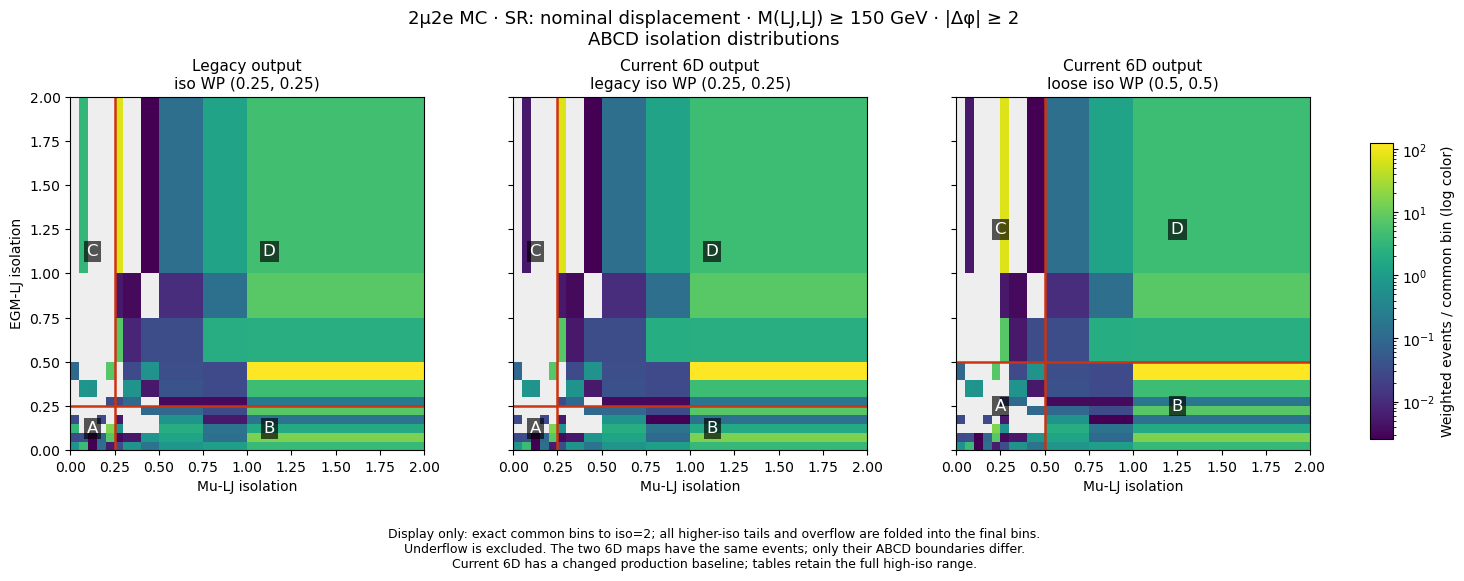

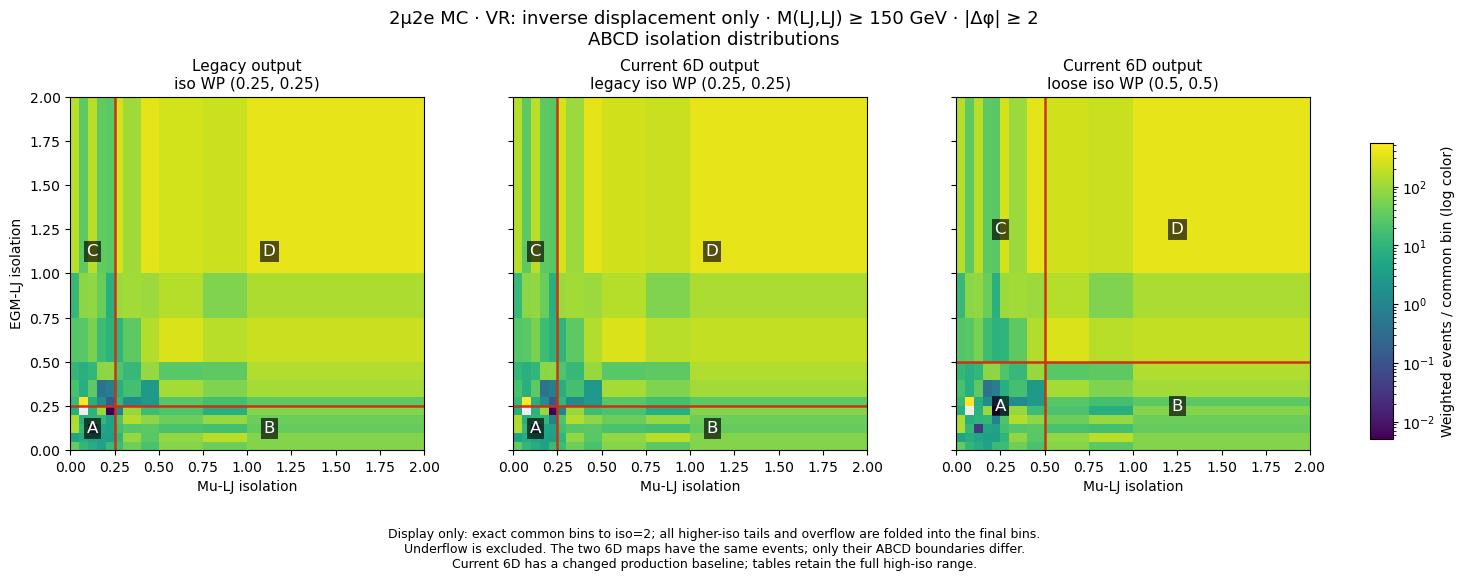

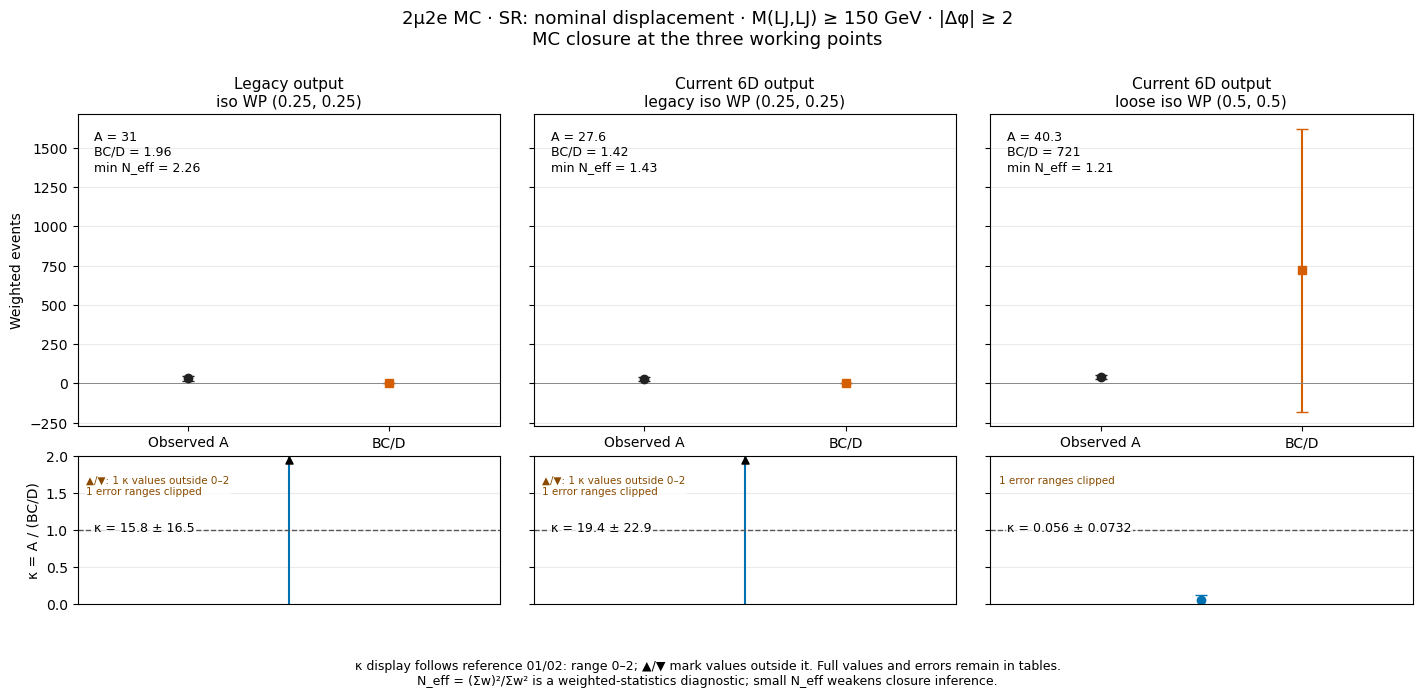

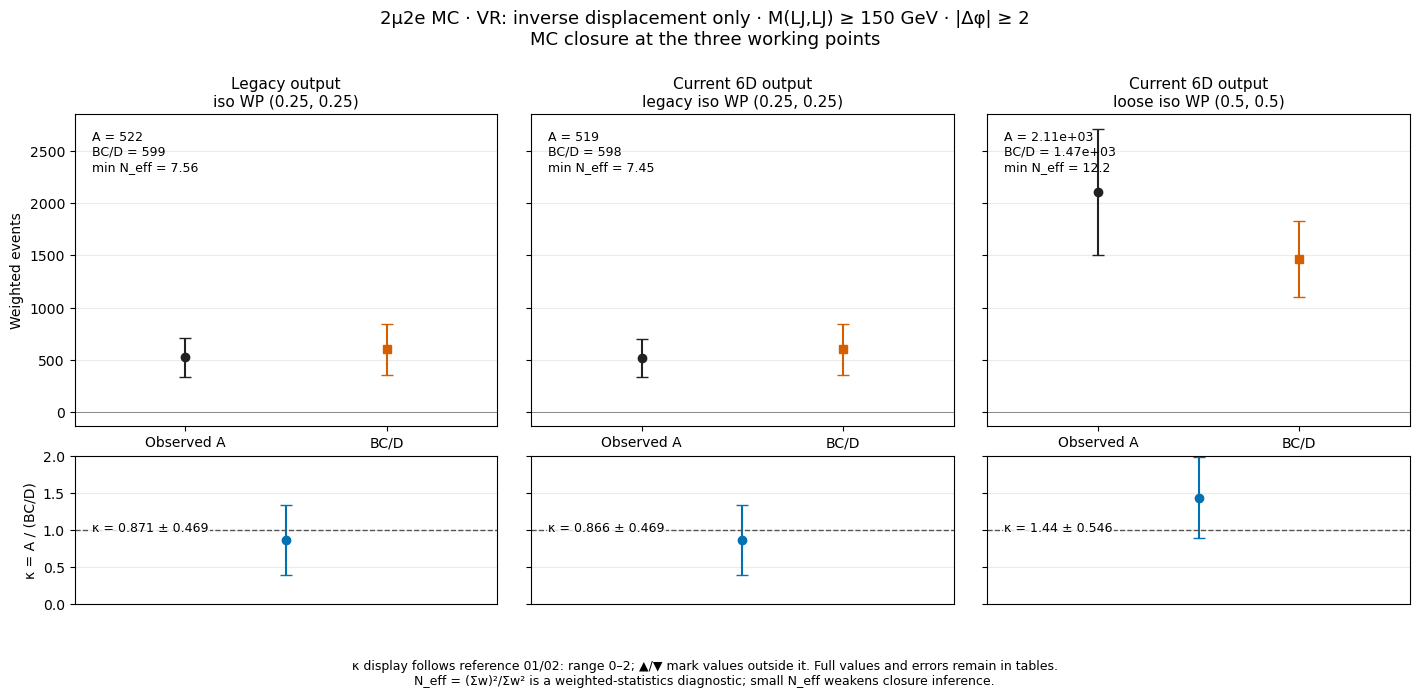

In [9]:
present_figures(plot_distributions(results, CONFIG))
present_figures(plot_closure(results, CONFIG))

## All available signal points: pooled 2D shape

Add a **pooled signal shape** using all 180 current signal samples, including both generated decay topologies. The existing golden legacy production contains 120 available models, so its pool uses those 120 and is labeled separately; old/current shape differences also reflect this grid-scope difference. Project every sample into the notebook's reconstructed topology and requested SR/VR/profile selection, sum the stored weighted bin contents first, then normalize the retained selected-plane sum to unit area for display. Do not normalize each sample separately before summation or apply another luminosity/cross-section factor. The inventory records the actual sample set, decay-topology balance, and retained weighted contributions for each source and profile.

This pool combines distinct physical hypotheses and is a visualization of the supplied signal library. It is **not a combined signal model**, an expected physical signal yield, or an input to S/B, leakage, WP selection, or the DATA gate. Those calculations continue to use the four displaced references individually. Differences between pooled shapes can reflect both event selection and the relative stored sample weights; state the source and sample inventory in the captions. Use the analysis's explicit flow policy for the normalization and fold bins for display only after forming the weighted pool.

Prompt-like samples may appear in this all-model visualization. They do not enter the four displaced-reference gate or its individual S/B/leakage diagnostics.

All-grid signal shapes legacy: 20/120, both generated topologies


All-grid signal shapes legacy: 40/120, both generated topologies


All-grid signal shapes legacy: 60/120, both generated topologies


All-grid signal shapes legacy: 80/120, both generated topologies


All-grid signal shapes legacy: 100/120, both generated topologies


...

All-grid signal shapes sixd: 100/180, both generated topologies


All-grid signal shapes sixd: 120/180, both generated topologies


All-grid signal shapes sixd: 140/180, both generated topologies


All-grid signal shapes sixd: 160/180, both generated topologies


All-grid signal shapes sixd: 180/180, both generated topologies


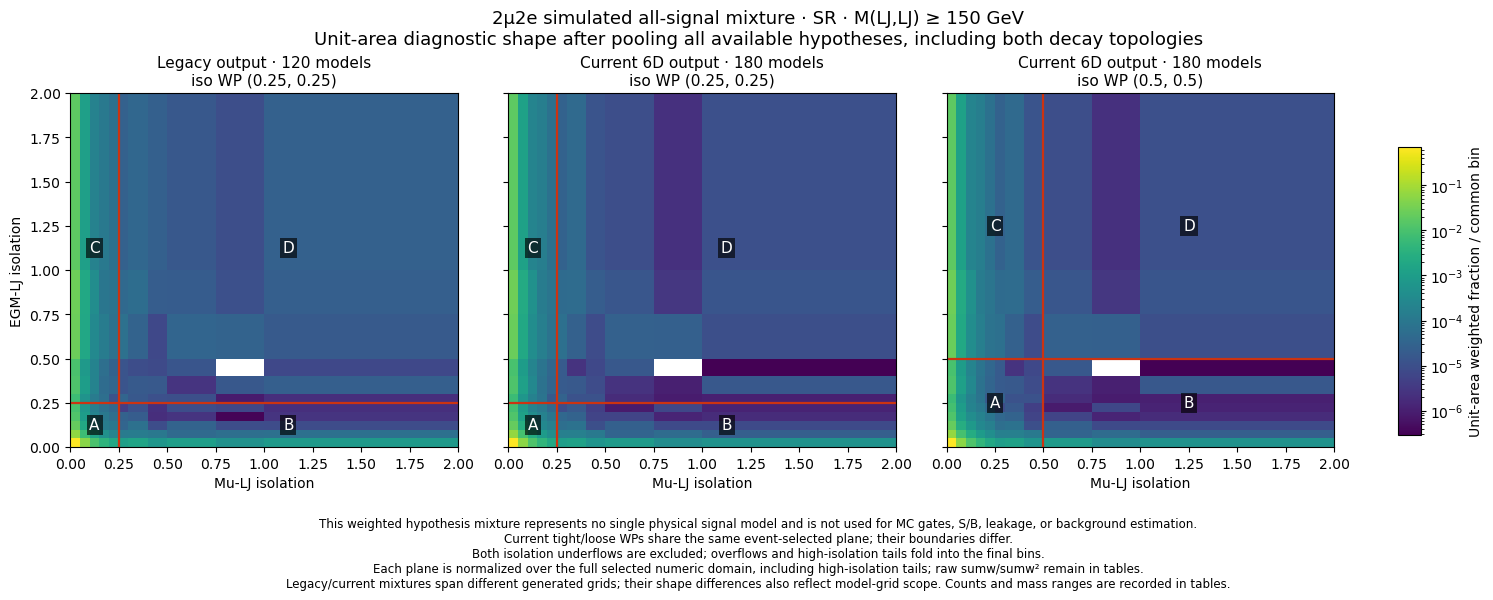

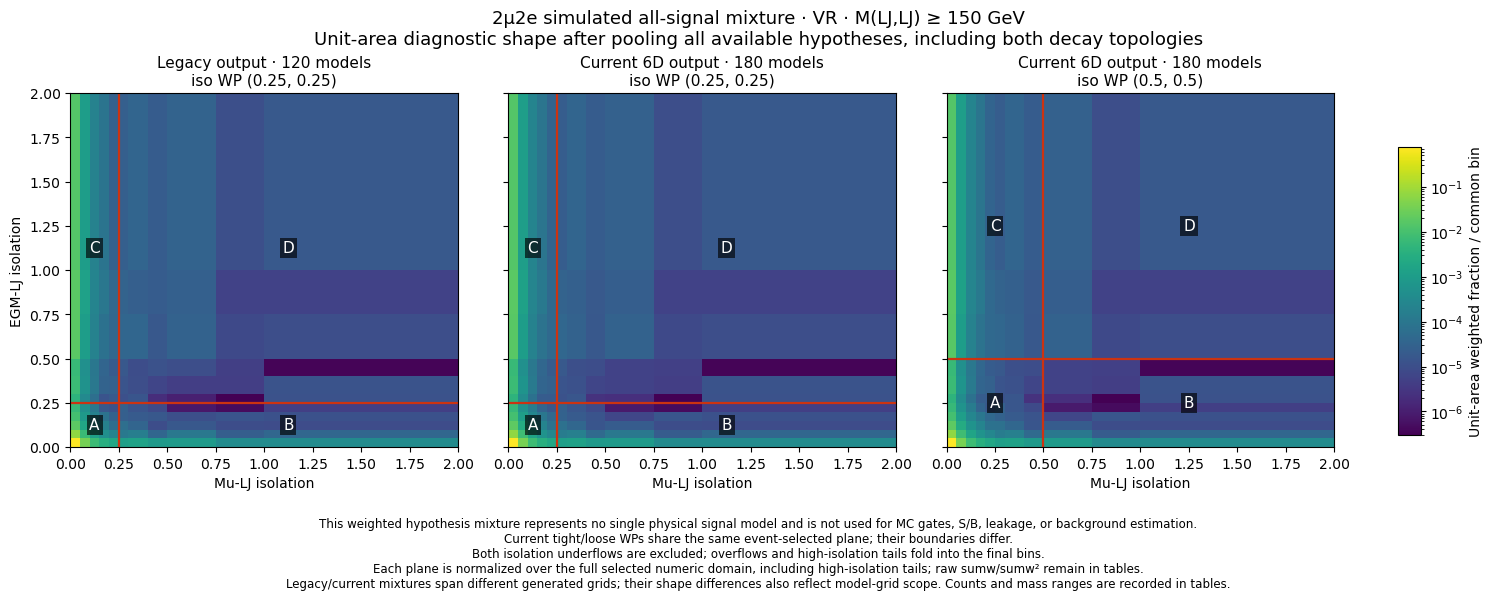

,benchmark,context,model_count,source,decay_topology_counts,bound_state_masses_GeV,raw_sumw,raw_sumw2,selected_sumw,selected_sumw2,...,neff,negative_selected_bins,mixed_hypotheses,unit_area_defined,normalization_status,xedges,yedges,display_normalization,flow_policy,purpose
0,legacy_025,SR,120,legacy,2Mu2E:60;4Mu:60,"[200.0, 500.0, 800.0, 1000.0]",472.479469,1.290071,471.454875,1.287381,...,172652.628535,0,True,True,DEFINED,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...","[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...",Plot layer normalizes the selected pooled nume...,Exclude isolation underflow on both axes; reta...,Mixed-model diagnostic shape; not a gate model...
1,legacy_025,VR,120,legacy,2Mu2E:60;4Mu:60,"[200.0, 500.0, 800.0, 1000.0]",843.124321,2.422476,840.332775,2.414829,...,292426.202664,0,True,True,DEFINED,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...","[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...",Plot layer normalizes the selected pooled nume...,Exclude isolation underflow on both axes; reta...,Mixed-model diagnostic shape; not a gate model...
2,sixd_025,SR,180,current6d,2Mu2E:90;4Mu:90,"[100.0, 150.0, 200.0, 500.0, 800.0, 1000.0]",442.840149,1.177890,441.834280,1.175386,...,166087.997758,0,True,True,DEFINED,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....","[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....",Plot layer normalizes the selected pooled nume...,Exclude isolation underflow on both axes; reta...,Mixed-model diagnostic shape; not a gate model...
3,sixd_025,VR,180,current6d,2Mu2E:90;4Mu:90,"[100.0, 150.0, 200.0, 500.0, 800.0, 1000.0]",836.152630,2.371186,833.296369,2.363610,...,293780.690468,0,True,True,DEFINED,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....","[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....",Plot layer normalizes the selected pooled nume...,Exclude isolation underflow on both axes; reta...,Mixed-model diagnostic shape; not a gate model...
4,sixd_050,SR,180,current6d,2Mu2E:90;4Mu:90,"[100.0, 150.0, 200.0, 500.0, 800.0, 1000.0]",442.840149,1.177890,441.834280,1.175386,...,166087.997758,0,True,True,DEFINED,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....","[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....",Plot layer normalizes the selected pooled nume...,Exclude isolation underflow on both axes; reta...,Mixed-model diagnostic shape; not a gate model...
5,sixd_050,VR,180,current6d,2Mu2E:90;4Mu:90,"[100.0, 150.0, 200.0, 500.0, 800.0, 1000.0]",836.152630,2.371186,833.296369,2.363610,...,293780.690468,0,True,True,DEFINED,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....","[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....",Plot layer normalizes the selected pooled nume...,Exclude isolation underflow on both axes; reta...,Mixed-model diagnostic shape; not a gate model...


In [10]:
all_signal_shapes = aggregate_initial_signal_shapes(CONFIG)
results["tables"].update({"all_signal_"+name: frame for name,frame in all_signal_shapes["tables"].items()})
present_figures(plot_initial_all_signal_shapes(all_signal_shapes, CONFIG), source="MC")
display(all_signal_shapes["tables"]["summary"])


## 6. Three-column isolation correlations

The correlation panels follow the All/A/B/C/D format of [01](01_Iso_iso_2mu2e_summary.ipynb) and [02](02_Iso_iso_4mu_summary.ipynb). For this old/current comparison, first coarsen both productions to **common exact isolation-bin edges over [0, 2]**, then calculate weighted Pearson $\rho$ at those common bin centres. Exclude isolation underflow, overflow, and the current regular [2, 5] tail; do not fold any excluded tail into the final correlation bin. The main panels report $\rho$ and $N_{\mathrm{eff}}$ for total background; individual-component values are retained in the numerical table. Permitted DATA is shown only in the VR section. Correlation is undefined for empty or nonpositive totals, zero axis spread, invalid moments, or any negative native or coarsened bin in the selected window. Preserve these cases as N/A with a status label; do not clip signed bin contents into a probability distribution. Keep low-statistics values visible with their diagnostic flag.

The native regular isolation domain is [0, 2] in the old histogram and [0, 5] in the current histogram; common support and common binning make the plotted comparison consistent. Bin-centre correlations remain approximate diagnostics rather than a measurement of event-level correlation. The two current 6D columns use the same selected plane, so their **All** correlation is identical; the A/B/C/D correlations can change when the isolation boundaries move. Small full-plane correlation does not establish ABCD closure. DATA correlations and full-plane distributions are displayed only when that column's named WP passes the MC signal-contamination gate. The correlation support differs from the ABCD yield calculation, which retains high-isolation overflow in the fail regions.

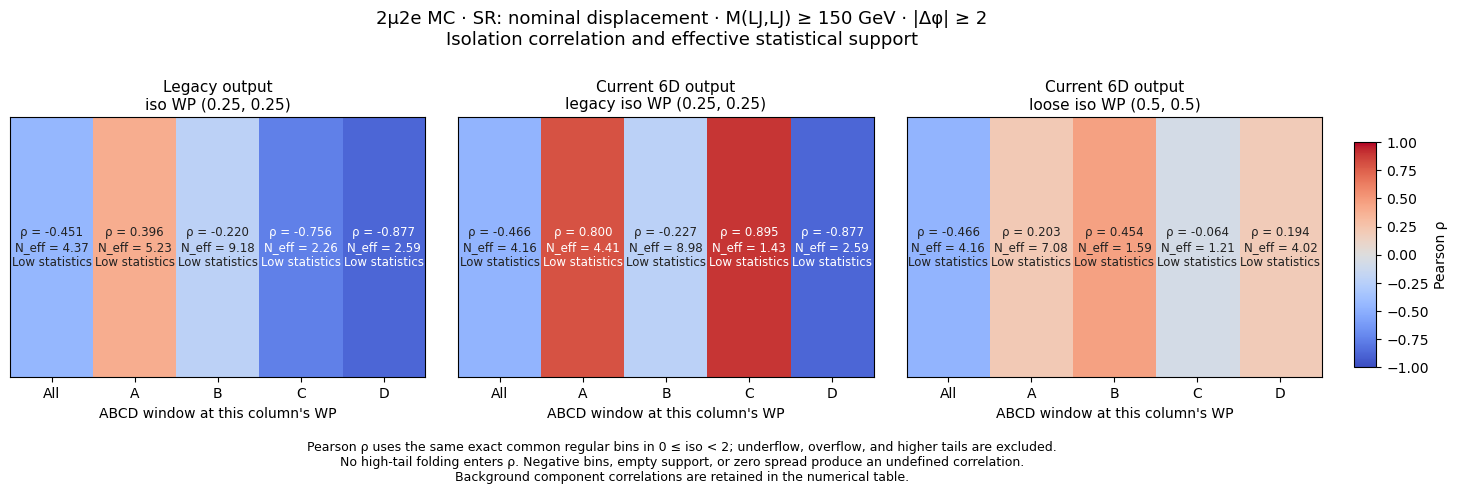

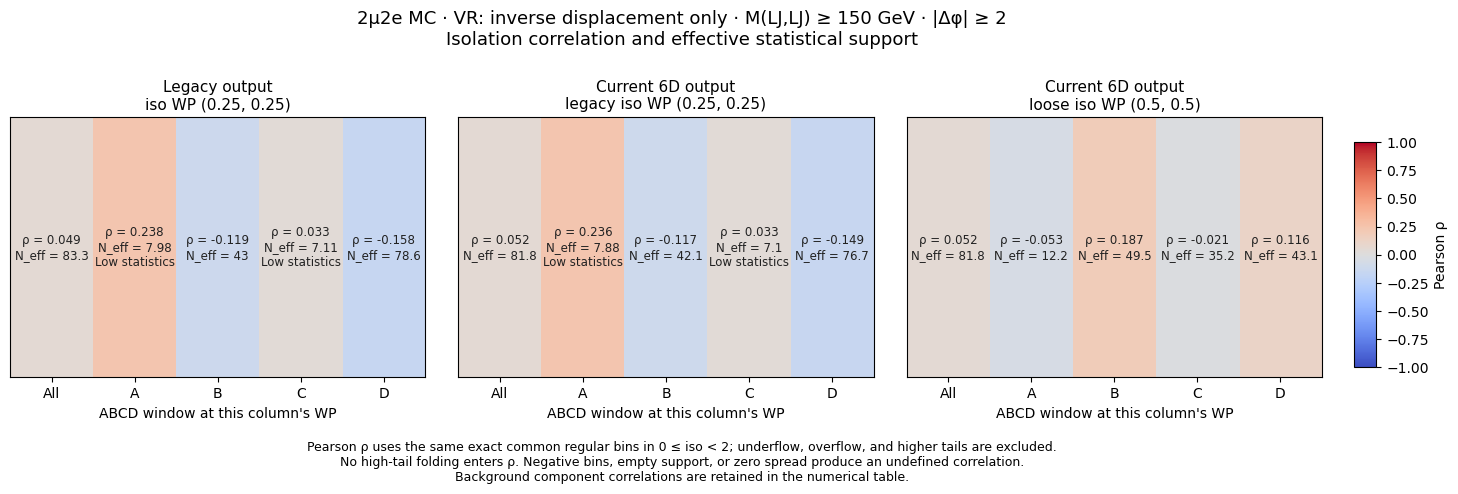

,benchmark,context,component,tx,ty,region,correlation,rho,neff,status,sumw,sumw2,negative_bins,native_negative_bins,display_binning,support
0,legacy_025,SR,Total,0.25,0.25,All,-0.451465,-0.451465,4.365580,LOW_STAT,291.588133,19475.908337,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Shared regular-bin support only; all flow and ...
1,legacy_025,SR,Total,0.25,0.25,A,0.395795,0.395795,5.233255,LOW_STAT,31.003767,183.677967,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Shared regular-bin support only; all flow and ...
2,legacy_025,SR,Total,0.25,0.25,B,-0.220142,-0.220142,9.176390,LOW_STAT,25.781790,72.435968,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Shared regular-bin support only; all flow and ...
3,legacy_025,SR,Total,0.25,0.25,C,-0.756092,-0.756092,2.256493,LOW_STAT,12.138317,65.295463,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Shared regular-bin support only; all flow and ...
4,legacy_025,SR,Total,0.25,0.25,D,-0.876558,-0.876558,2.588393,LOW_STAT,222.664260,19154.498939,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Shared regular-bin support only; all flow and ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,sixd_050,VR,Diboson,0.50,0.50,All,-0.006003,-0.006003,46.040162,OK,10.684690,2.479631,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Shared regular-bin support only; all flow and ...
146,sixd_050,VR,Diboson,0.50,0.50,A,0.109187,0.109187,41.678434,OK,9.484847,2.158486,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Shared regular-bin support only; all flow and ...
147,sixd_050,VR,Diboson,0.50,0.50,B,-0.003804,-0.003804,2.667619,LOW_STAT,0.806294,0.243704,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Shared regular-bin support only; all flow and ...
148,sixd_050,VR,Diboson,0.50,0.50,C,-1.000000,-1.000000,2.000000,LOW_STAT,0.393550,0.077441,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Shared regular-bin support only; all flow and ...


In [11]:
present_figures(plot_correlations(results, CONFIG))
display(tables["correlation_summary"])

## 7. Three-column 2D κ scans

The 2D $\kappa$ scans retain the blue–grey–red reference convention from [01](01_Iso_iso_2mu2e_summary.ipynb) and [02](02_Iso_iso_4mu_summary.ipynb), with colour limits $-3$ and $+3$ and $\kappa=1$ at the grey centre. Every finite cell shows its actual numerical value, including values beyond the colour limits. Mark the column's comparison WP and retain undefined or gate-blocked DATA cells as blank. Numerical uncertainties and statistical-status flags remain in the exported tables. Use only thresholds represented exactly by the applicable stored histogram edges; a scan does not interpolate a finer working point.

Moving the isolation boundaries changes the A/B/C/D partition of the same event-selected plane, rather than changing an isolation event preselection. The two current columns therefore share the same full 2D $\kappa$ grid but highlight different WPs. Retain all defined values rather than choosing cells with $\kappa$ near one. For 1D closure figures, display $0\le\kappa\le2$; mark central values outside the range with downward/upward triangles and report the numbers of off-scale central values and clipped error ranges. The saved numerical results remain unchanged by this display limit.

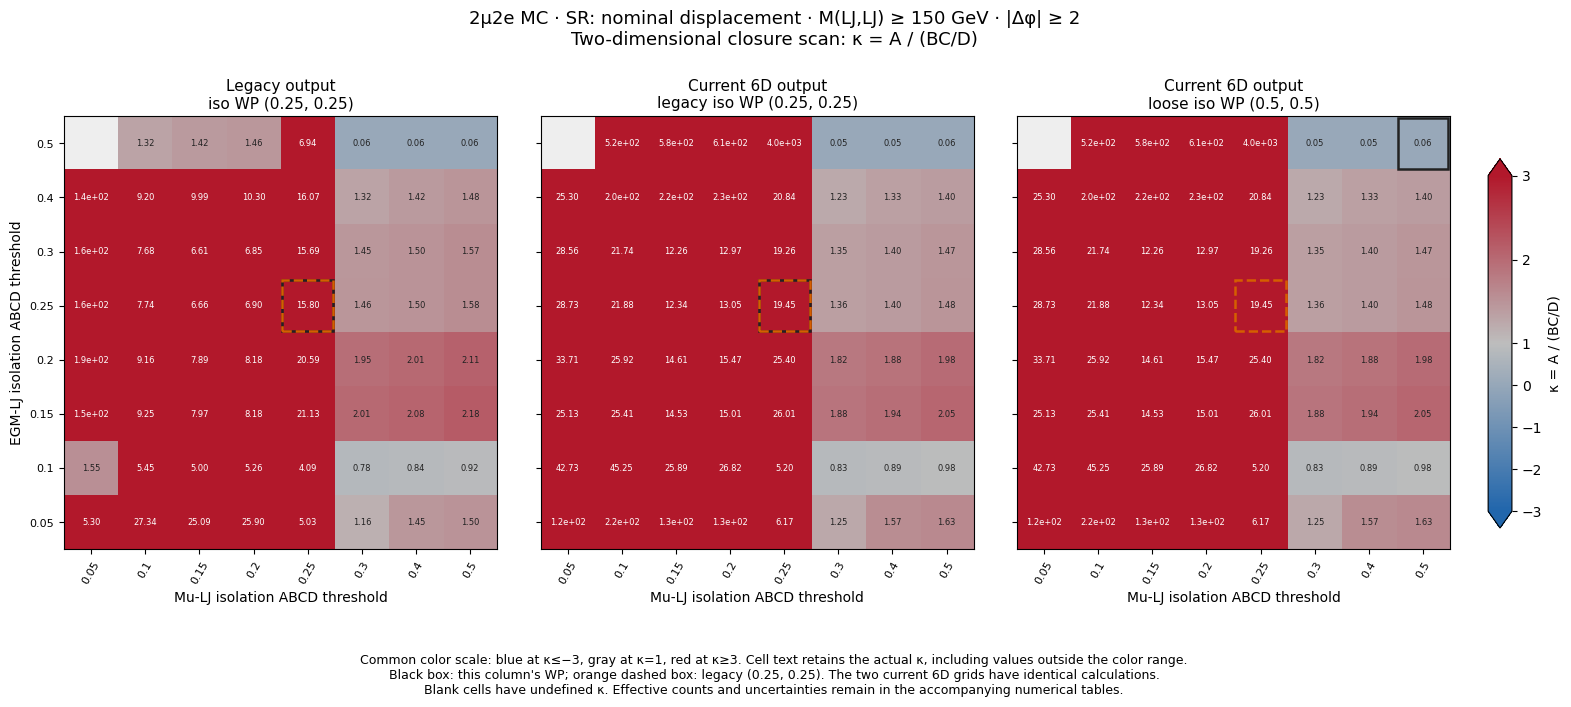

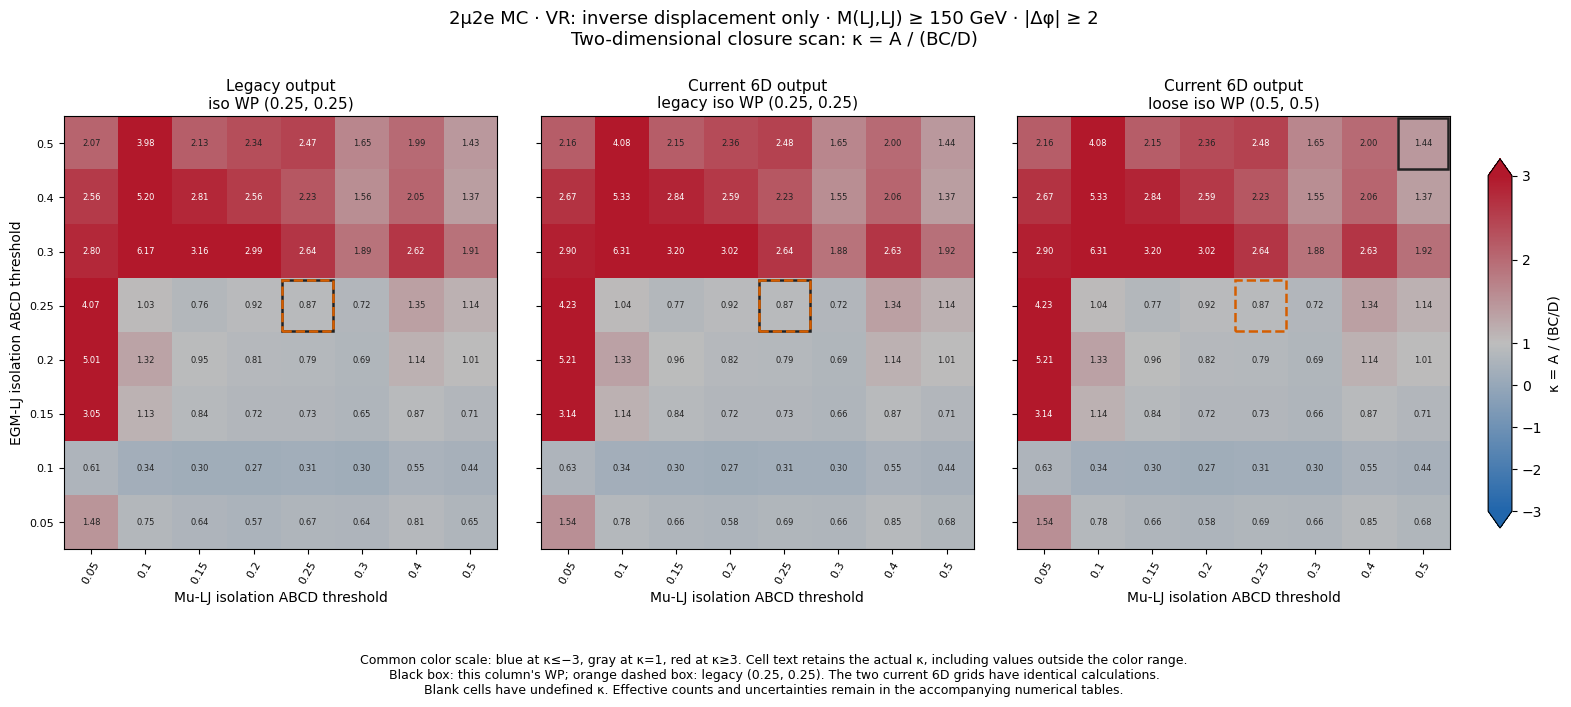

,benchmark,context,tx,ty,pred,pred_error,kappa,kappa_error,pull,status,...,C_error,neff_C,D,var_D,D_error,neff_D,neff_min,min_neff,min_sideband_neff,low_stat
0,legacy_025,SR,0.05,0.05,0.125236,0.140417,5.300940,7.936787,0.799709,LOW_STAT_SIDEBAND,...,3.275252,1.093900,293.392070,19517.718298,139.705828,4.410296,1.015642,1.015642,1.093900,True
1,legacy_025,SR,0.05,0.10,0.446917,0.510812,1.550720,2.306144,0.295082,LOW_STAT_SIDEBAND,...,3.275122,1.075431,268.754086,19396.047054,139.269692,3.723891,1.075431,1.075431,1.075431,True
2,legacy_025,SR,0.05,0.15,0.027333,0.027732,145.124475,191.327853,1.179621,LOW_STAT_SIDEBAND,...,0.098013,1.568334,248.730485,19285.580960,138.872535,3.207933,1.410981,1.410981,1.568334,True
3,legacy_025,SR,0.05,0.20,0.021232,0.025047,188.201461,272.085969,1.190147,LOW_STAT_SIDEBAND,...,0.093570,1.000000,247.873703,19285.136454,138.870935,3.185944,1.000000,1.000000,1.000000,True
4,legacy_025,SR,0.05,0.25,0.024879,0.029507,160.612467,233.033152,1.189042,LOW_STAT_SIDEBAND,...,0.093570,1.000000,240.241626,19231.423876,138.677409,3.001132,1.000000,1.000000,1.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,sixd_050,VR,0.50,0.20,909.236776,270.033255,1.010114,0.387586,0.026253,OK,...,643.127167,23.658559,2438.303117,71859.492575,268.066209,82.735375,16.941240,16.941240,23.658559,False
380,sixd_050,VR,0.50,0.25,996.047813,294.928962,1.137495,0.417272,0.356980,OK,...,634.986327,21.053950,2345.267121,71375.490353,267.161918,77.061157,21.053950,21.053950,21.053950,False
381,sixd_050,VR,0.50,0.30,897.091992,216.219550,1.917371,0.804998,1.307133,OK,...,337.287570,47.579959,2271.251823,70978.262956,266.417460,72.678375,8.461831,8.461831,42.890019,True
382,sixd_050,VR,0.50,0.40,1313.613157,319.020144,1.374451,0.560711,0.731610,OK,...,336.376511,44.389004,1984.070814,60267.448290,245.494294,65.317798,9.307005,9.307005,44.389004,True


In [12]:
present_figures(plot_kappa_grids(results, CONFIG))
display(tables["kappa_grid"])

## 8. Three-column one-axis isolation scans

Scan each production's **native stored isolation edges up to 1.0**, without interpolation or a finer artificial grid. The old 40-bin isolation histogram provides 20 thresholds from 0.05 to 1.00 in steps of 0.05; the current 6D histogram provides 10 thresholds: 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.75, and 1.00. Show the same horizontal range in all three columns while retaining their different point locations. The other ABCD boundary remains fixed at 0.25, 0.25, and 0.50, respectively.

Only the isolation partition changes along the scan. The selected plane, initial mass/angular/displacement cuts, and flow convention remain fixed. Native thresholds do not change the stored event binning, and overlapping scan points are not independent measurements. The 2D $\kappa$ grid uses its separately specified common threshold grid. Prepare the MC signal-contamination gate for every native 1D point before opening DATA payloads.

The bottom 1D panels show all four displaced hypotheses separately. Line styles and legend labels identify **$m_A=200$, 500, 800, and 1000 GeV**, rather than prompt/displaced categories. Plot $S/B_{\mathrm{MC}}=S_A/B_{\mathrm{MC},A}$ on the left axis and leakage $S_{B+C+D}/S_{A+B+C+D}$ on the right percentage axis. Each signal is compared with the background from the same production and selection. Retain stored signal weights and variances, with no additional luminosity or cross-section normalization.

The 15% leakage line remains a diagnostic guide and is not the DATA contamination condition. Keep all four curves individual; an envelope of contamination fractions may identify the limiting hypothesis in an audit, but a sum of signal yields is not used. The native 1D thresholds, initial mass/angular/displacement cuts, yield-display limits, and numerical flow conventions remain unchanged.

The SR observed-A and $BC/D$ yield panels use an upper display limit so a few extreme predictions do not compress the remaining comparison. Use series-coloured upward/downward triangles for central values outside the displayed range and report the number of off-scale values and clipped uncertainty ranges separately for observed A and the BC/D prediction. This changes the figure only: retain all original yields, predictions, variances, and status labels in the numerical tables. The $\kappa$ panel remains limited to 0–2, with its own off-scale markers and counts. No event selection, working point, or background-estimation formula is changed by either display limit.

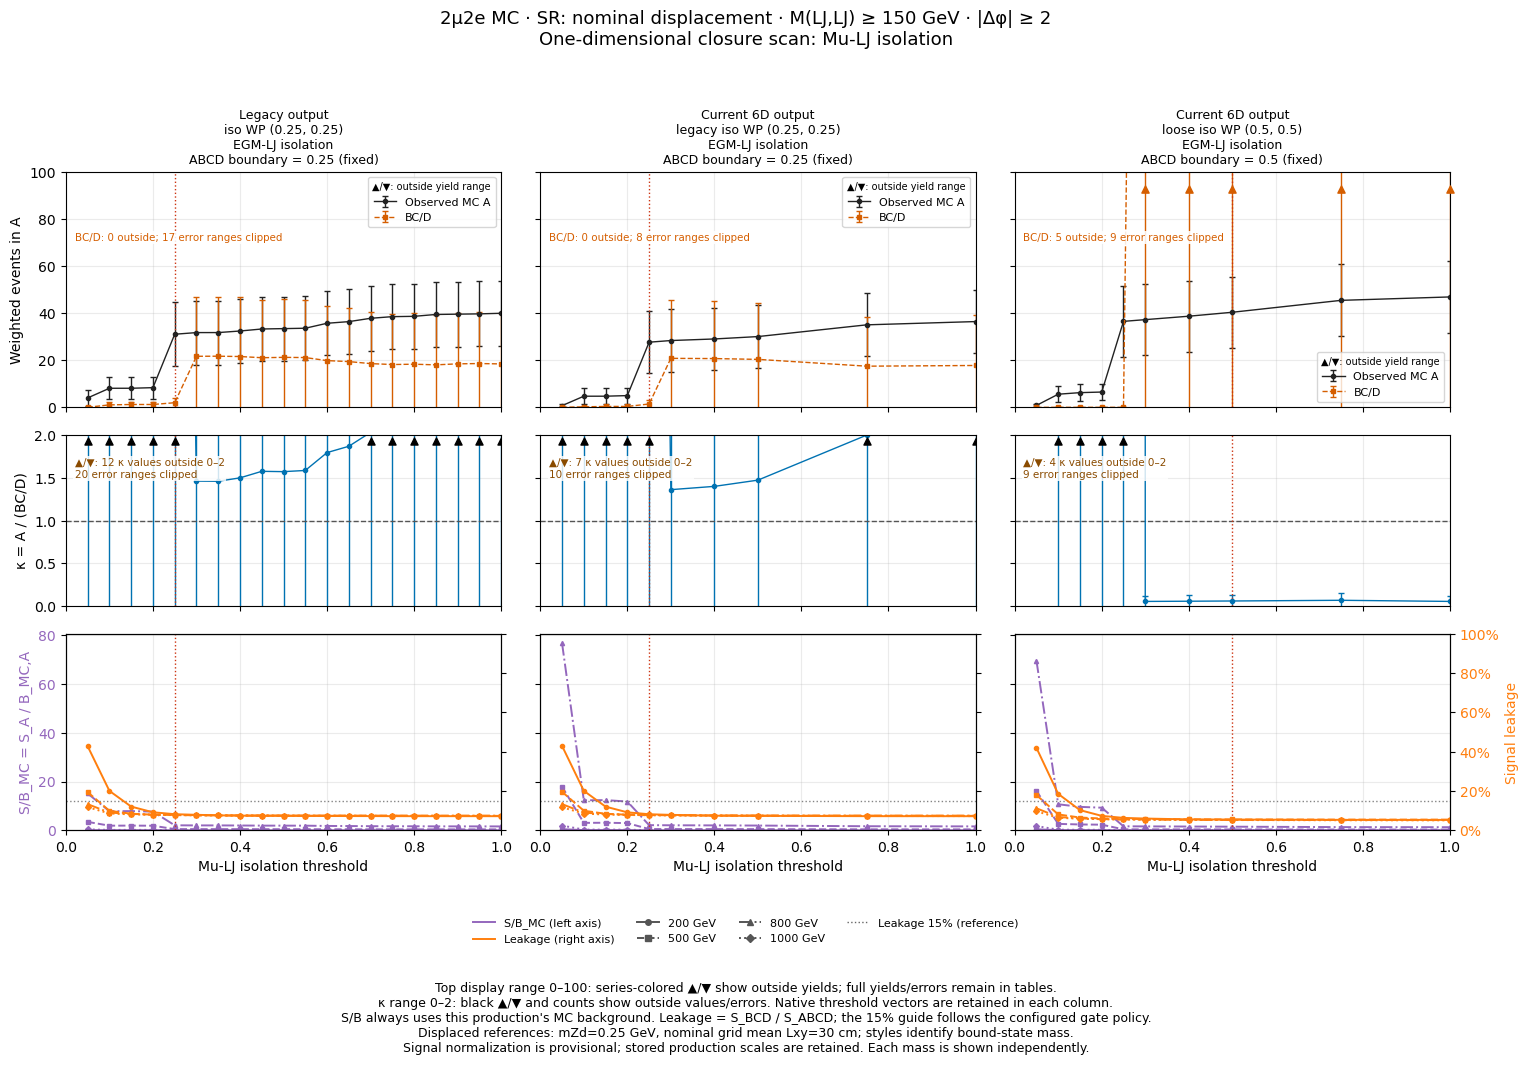

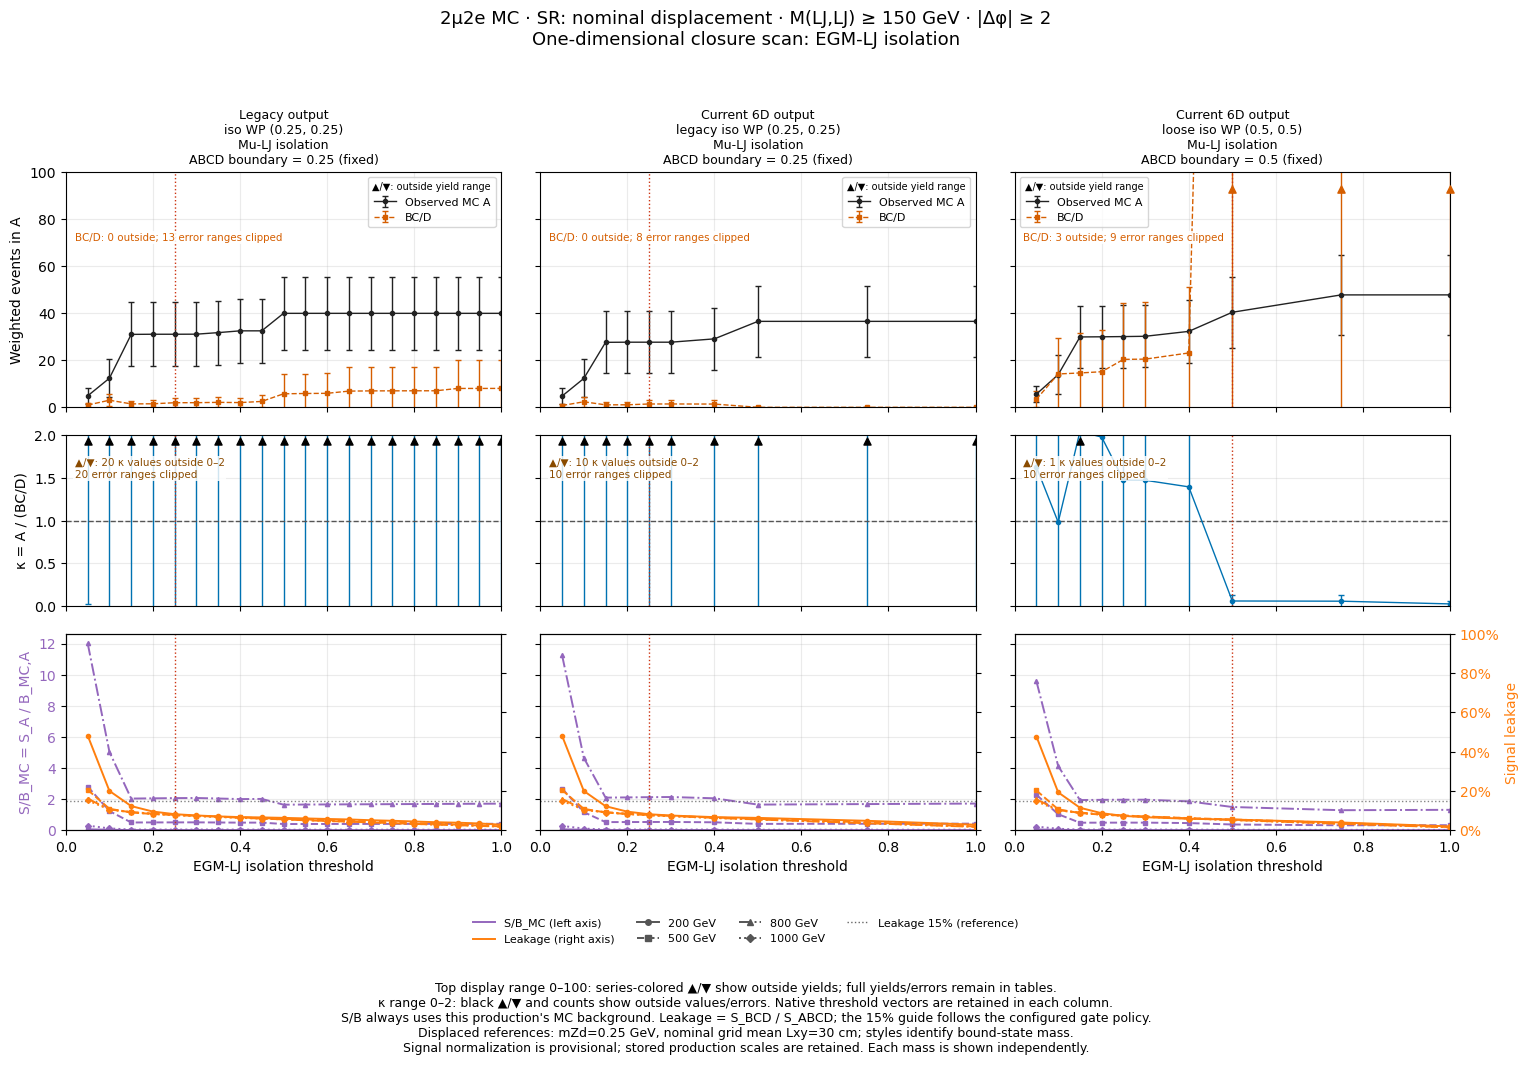

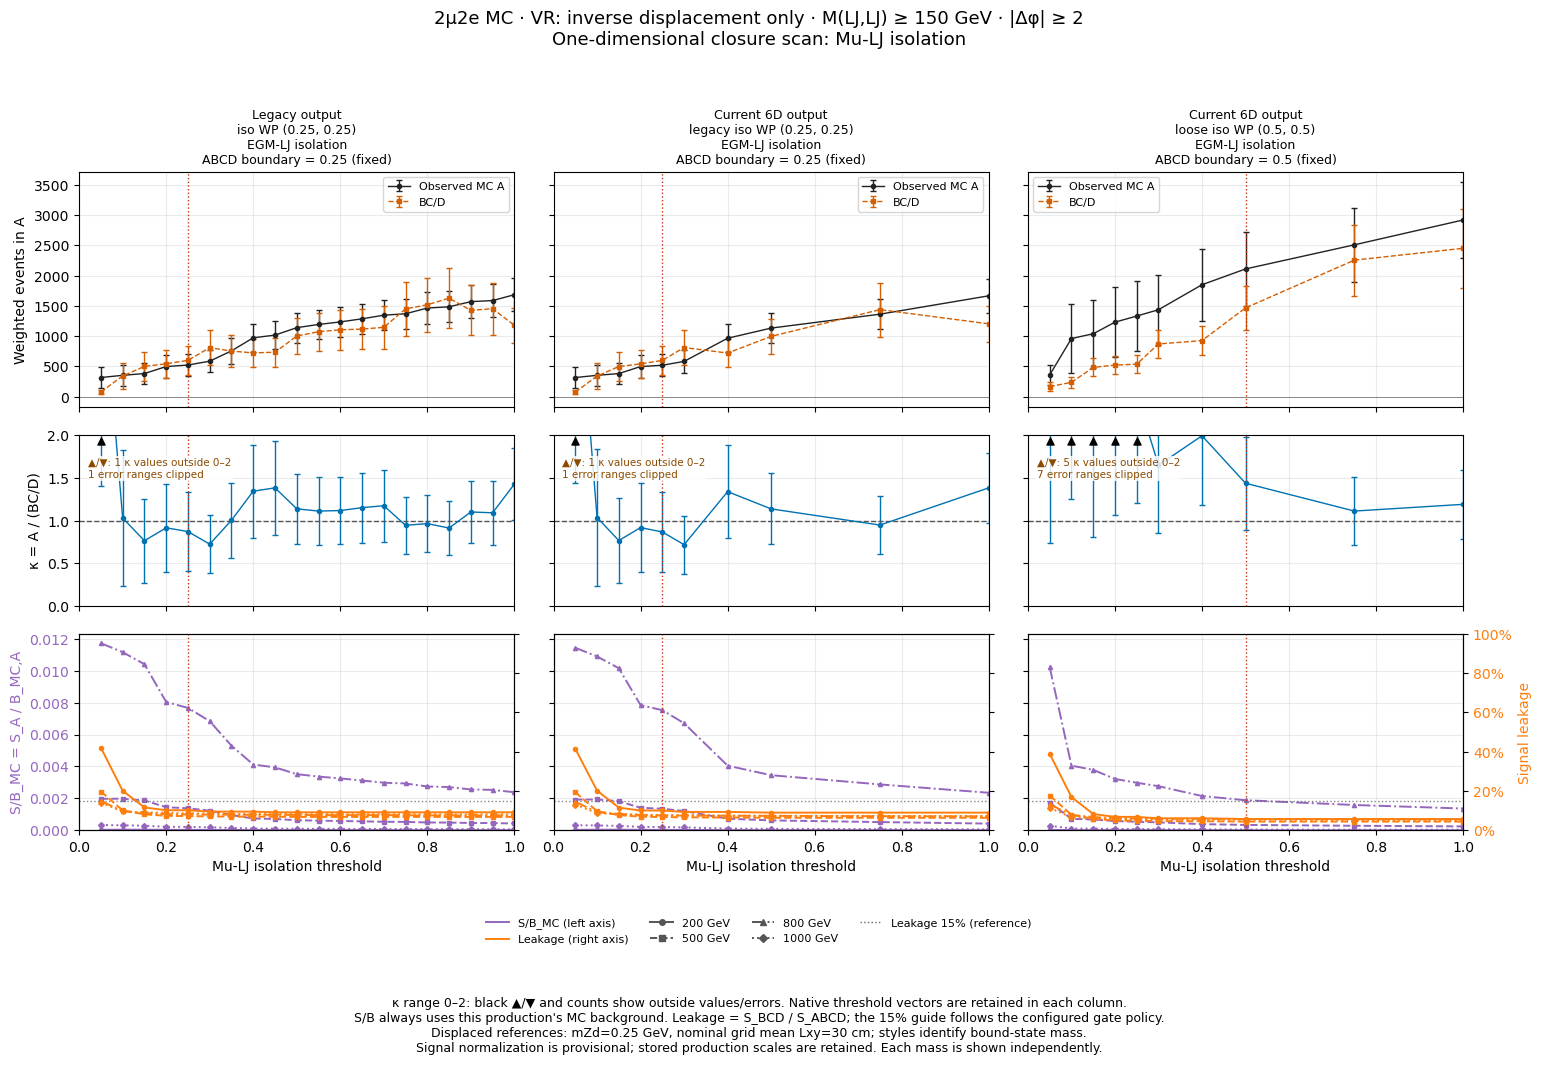

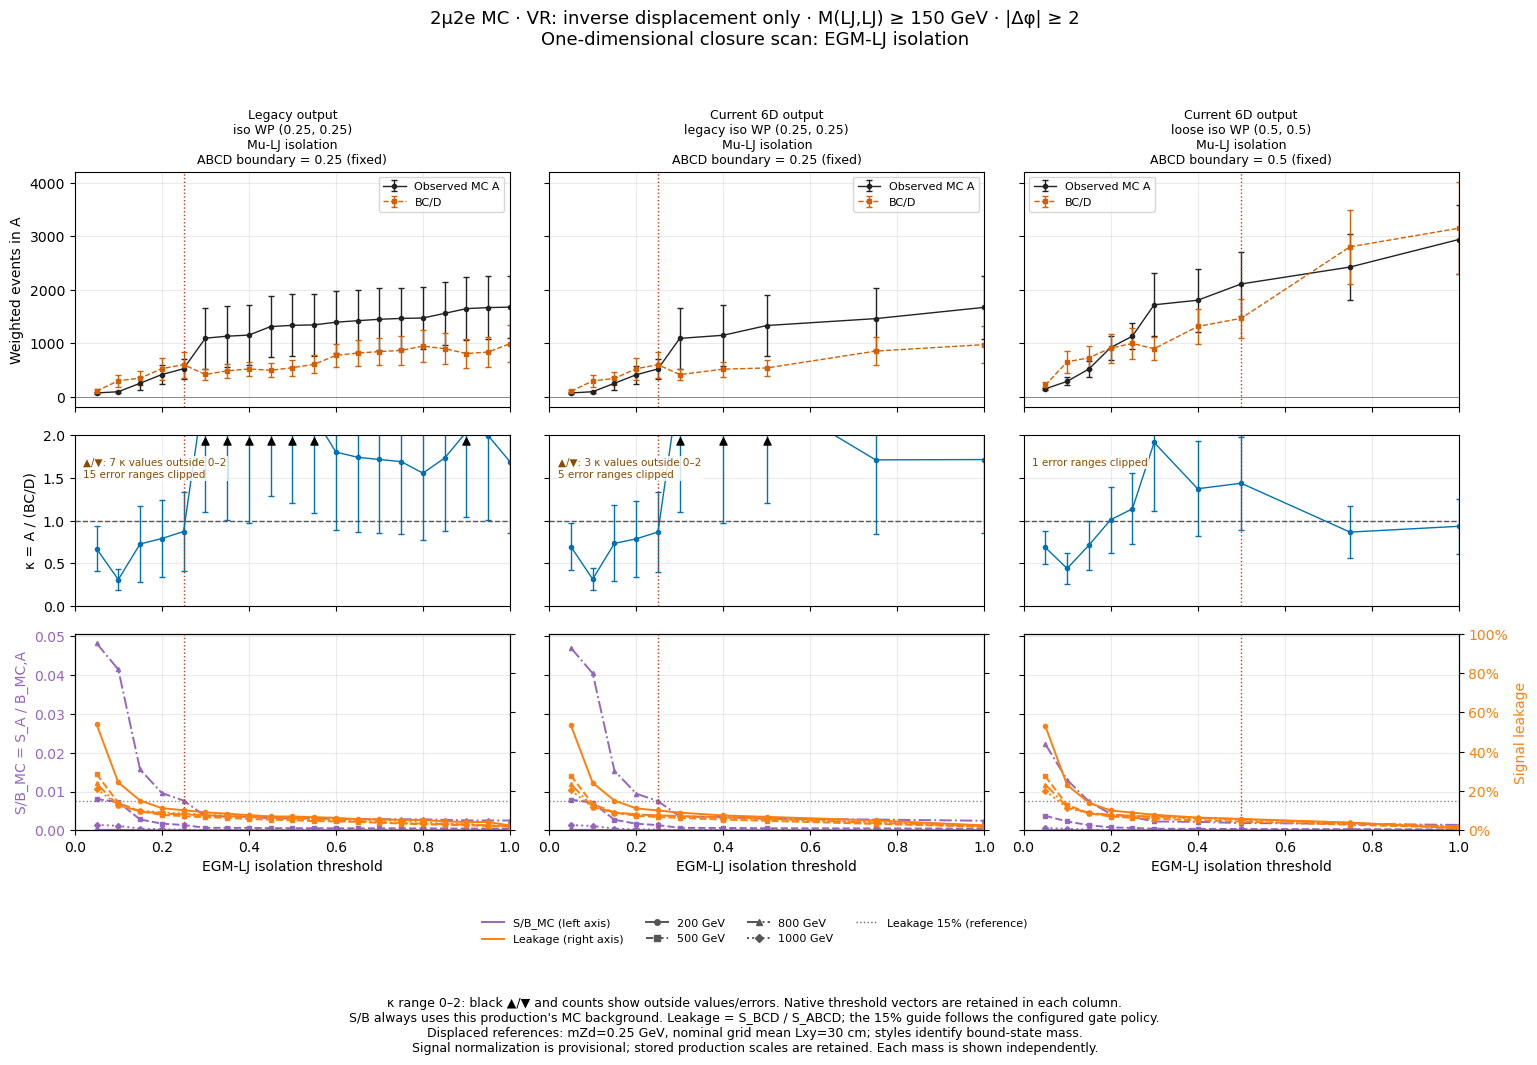

,benchmark,context,reference_role,role,sample,mA_GeV,mZd_GeV,ctau_mm,reference_kind,avg_transverse_cm,displacement_metadata,tx,ty,s_over_b,s_over_b_error,signal_to_background,leakage,leakage_error,leakage_percent,signal_total,status,signal_status,signal_A,signal_var_A,var_signal_A,signal_neff_A,background_A,signal_B,signal_var_B,var_signal_B,signal_neff_B,background_B,signal_C,signal_var_C,var_signal_C,signal_neff_C,background_C,signal_D,signal_var_D,var_signal_D,signal_neff_D,background_D,s_over_b_status,signal_neff_min,approved,gate_passed,gate_reason,gate_max_fraction,gate_worst,gate_worst_reference,gate_worst_context,gate_worst_region,gate_worst_criterion,gate_active_fraction,gate_active_limit,gate_worst_ratio_to_limit,gate_mode,gate_criterion,max_signal_fraction,contamination_gate_passed,contamination_gate_reason,contamination_gate_worst,leakage_gate_passed,leakage_gate_reason,gate_max_leakage,leakage_gate_worst,leakage_limit,leakage_contexts,leakage_comparison,vr_only_gate_passed,vr_only_gate_reason,vr_only_gate_max_fraction,vr_only_gate_worst,vr_only_gate_policy,reference_count,gate_reference_mode,envelope_policy,signal_normalization_verified,policy
0,legacy_025,SR,mA200,mA200,2Mu2E_200GeV_0p25GeV_1p0mm,200.0,0.25,1.00,displaced,30.0,Nominal signal-grid average transverse decay l...,0.25,0.25,0.018470,0.008076,0.018470,0.082298,0.002832,8.229797,0.623979,LOW_STAT,LOW_STAT,0.572627,0.000038,0.000038,8642.0,31.003767,0.006361,4.214886e-07,4.214886e-07,96.0,36.868713,0.044461,2.946029e-06,2.946029e-06,671.0,12.143459,0.000530,3.512405e-08,3.512405e-08,8.0,228.191738,OK,8.0,True,True,,0.296172,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.082298,0.15,0.548653,leakage,Signal leakage strictly < limit in configured ...,0.1,False,mA800_SR_C:signal_fraction_exceeds_limit,mA800_SR_C,True,,0.082298,mA200_SR,0.15,SR,strict <; equality fails,True,,0.007610,mA800_VR_A,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...
1,legacy_025,SR,mA500,mA500,2Mu2E_500GeV_0p25GeV_0p4mm,500.0,0.25,0.40,displaced,30.0,Nominal signal-grid average transverse decay l...,0.25,0.25,0.512314,0.223963,0.512314,0.077906,0.001230,7.790595,17.225633,OK,OK,15.883654,0.005759,0.005759,43805.0,31.003767,0.077596,2.813632e-05,2.813632e-05,214.0,36.868713,1.257856,4.560976e-04,4.560976e-04,3469.0,12.143459,0.006527,2.366606e-06,2.366606e-06,18.0,228.191738,OK,18.0,True,True,,0.296172,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.082298,0.15,0.548653,leakage,Signal leakage strictly < limit in configured ...,0.1,False,mA800_SR_C:signal_fraction_exceeds_limit,mA800_SR_C,True,,0.082298,mA200_SR,0.15,SR,strict <; equality fails,True,,0.007610,mA800_VR_A,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...
2,legacy_025,SR,mA800,mA800,2Mu2E_800GeV_0p25GeV_0p25mm,800.0,0.25,0.25,displaced,30.0,Nominal signal-grid average transverse decay l...,0.25,0.25,2.071065,0.905455,2.071065,0.078469,0.001862,7.846899,69.678427,OK,OK,64.210832,0.214596,0.214596,19213.0,31.003767,0.314153,1.049915e-03,1.049915e-03,94.0,36.868713,5.109996,1.707787e-02,1.707787e-02,1529.0,12.143459,0.043447,1.452010e-04,1.452010e-04,13.0,228.191738,OK,13.0,True,True,,0.296172,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.082298,0.15,0.548653,leakage,Signal leakage strictly < limit in configured ...,0.1,False,mA800_SR_C:signal_fraction_exceeds_limit,mA800_SR_C,True,,0.082298,mA200_SR,0.15,SR,strict <; equality fails,True,,0.007610,mA800_VR_A,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...
3,legacy_025,SR,mA1000,mA1000,2Mu2E_1000GeV_0p25GeV_0p2mm,1000.0,0.25,0.20,displa

In [13]:
present_figures(plot_one_d_scans(results, CONFIG))
with pd.option_context("display.max_columns", None):
    display(tables["signal_diagnostics"])


## 9. Background composition and effective statistics

Use the same process colors and A/B/C/D order in all columns. The total ABCD prediction is evaluated after summing background yields, not by summing component predictions. Neff is a statistical diagnostic; overlapping columns are not independent samples.

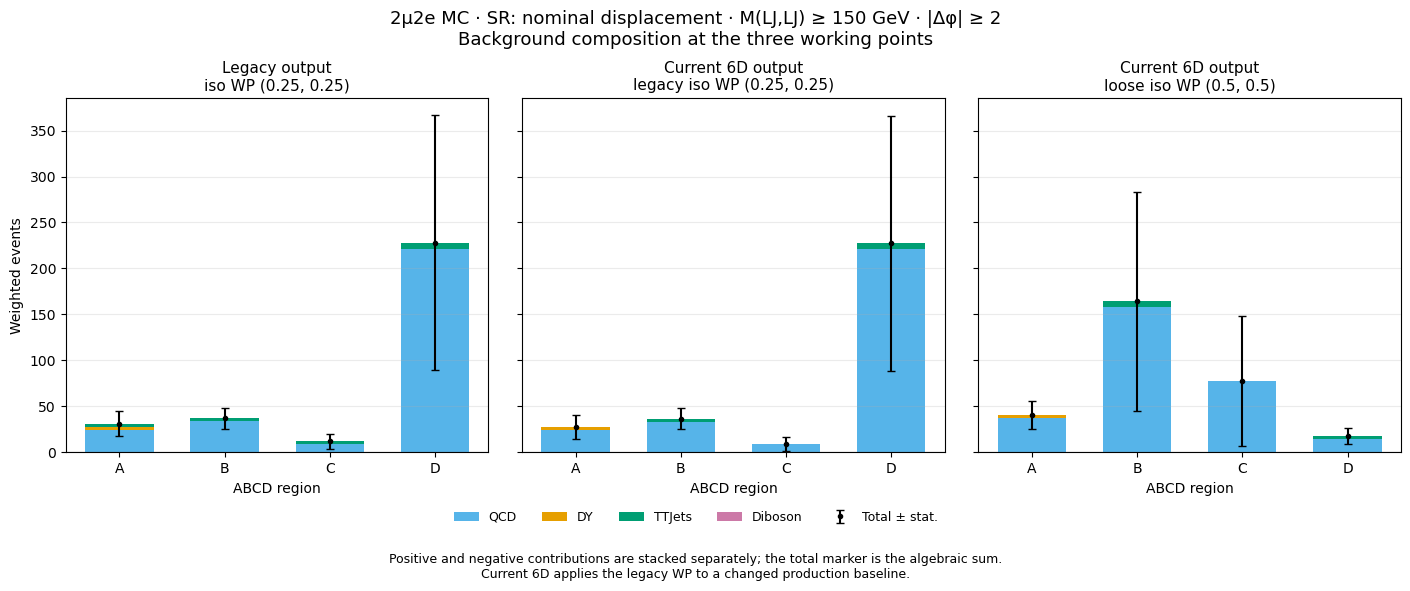

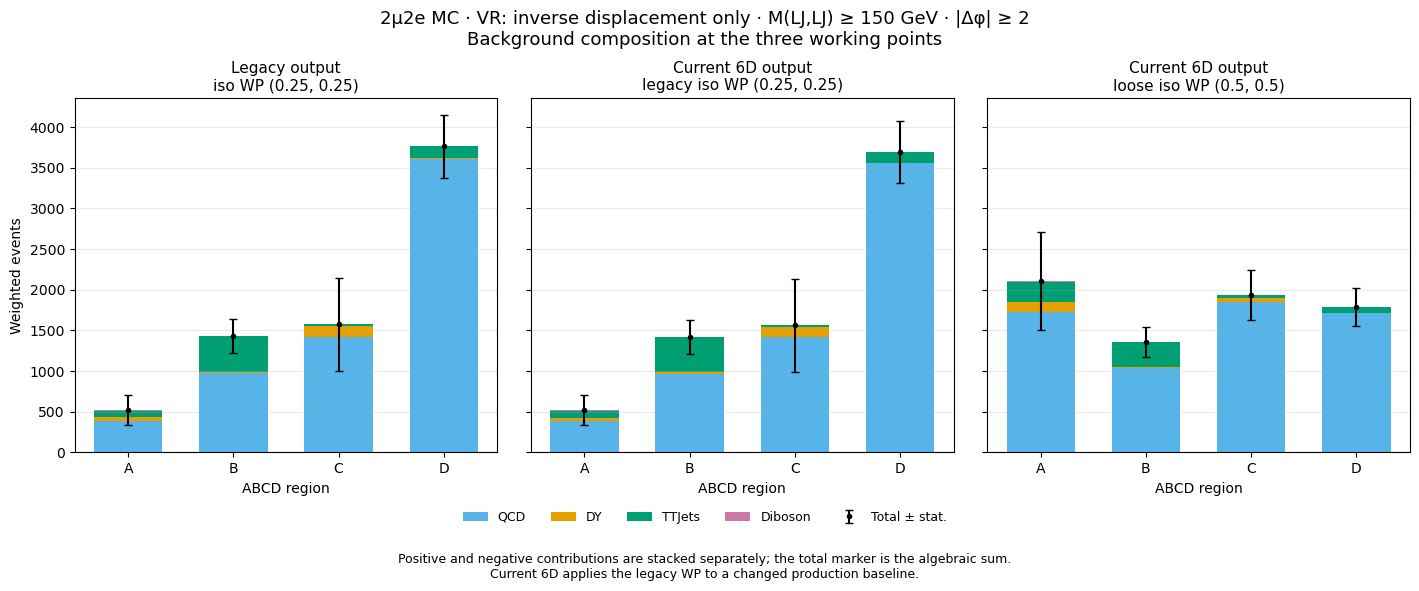

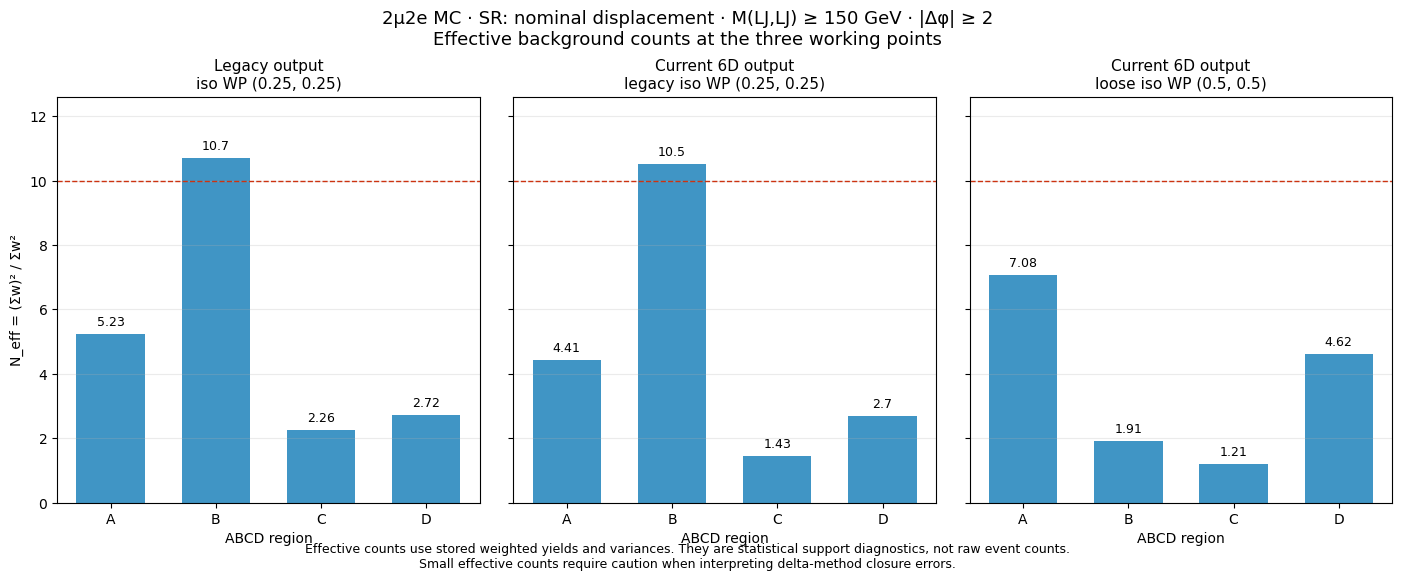

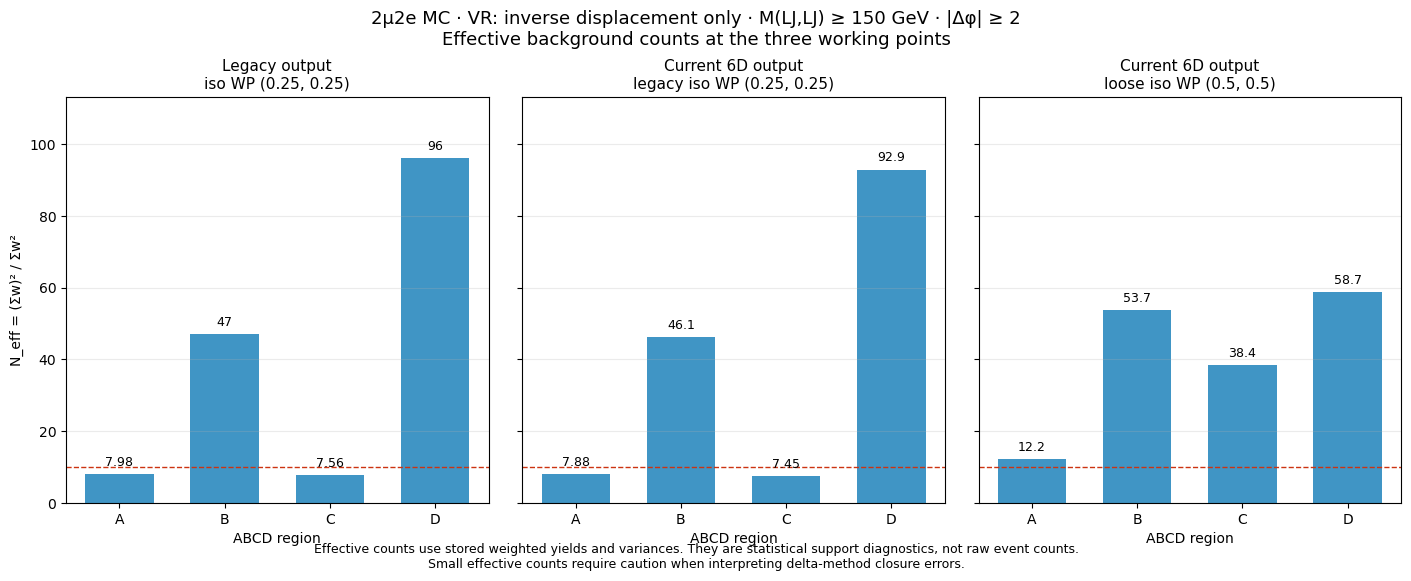

,benchmark,context,component,region,yield_value,variance,error,neff,yield
0,legacy_025,SR,Total,A,31.003767,183.677967,13.552784,5.233255,31.003767
1,legacy_025,SR,Total,B,36.868713,127.141241,11.275693,10.691275,36.868713
2,legacy_025,SR,Total,C,12.143459,65.295476,8.080562,2.258404,12.143459
3,legacy_025,SR,Total,D,228.191738,19166.137155,138.441819,2.716847,228.191738
4,legacy_025,SR,QCD,A,24.482073,162.411390,12.744073,3.690455,24.482073
...,...,...,...,...,...,...,...,...,...
115,sixd_050,VR,TTJets,D,75.294060,246.486760,15.699897,23.000000,75.294060
116,sixd_050,VR,Diboson,A,9.484847,2.158486,1.469179,41.678434,9.484847
117,sixd_050,VR,Diboson,B,1.013005,0.286433,0.535195,3.582606,1.013005
118,sixd_050,VR,Diboson,C,0.393550,0.077441,0.278282,2.000000,0.393550


In [14]:
present_figures(plot_composition(results, CONFIG))
present_figures(plot_effective_counts(results, CONFIG))
display(tables["region_yields"])


## 10. Production ratios, flow checks, and one-cut diagnostics

Report the old-to-6D change at the matched (0.25, 0.25) WP separately from the 6D change from (0.25, 0.25) to (0.50, 0.50). For each SR/VR and A/B/C/D region, retain the two yields, absolute difference, relative change or ratio when defined, and their individual statistical uncertainties. Extend the same comparison to $P$, $\kappa$, composition, and effective statistics.

A changed composition can alter closure even when the two isolation variables look weakly correlated in the full plane. Small effective statistics can also make a large $\kappa$ uncertain. Interpret the yield, composition, and statistical-support tables together. The current 01/02 results use an inclusive mass selection, so their saved numbers are contextual diagnostics and are not the results with matching selectable boundaries of this notebook.

In [15]:
with pd.option_context("display.max_columns", None):
    display(tables["production_ratios"])
    display(tables["closure_ratios"])
    display(tables["flow_diagnostic"])
    display(tables["cut_diagnostic"])
    display(tables["transferability"])


,comparison,numerator_benchmark,denominator_benchmark,context,component,region,ratio,numerator_yield,denominator_yield,difference,relative_change,absolute_difference,numerator_error,denominator_error,uncertainty_note
0,Current 0.25 / legacy 0.25,sixd_025,legacy_025,SR,Total,A,0.891227,27.631400,31.003767,-3.372367,-0.108773,3.372367,13.151136,13.552784,Individual uncertainties shown; event overlap ...
1,Current 0.25 / legacy 0.25,sixd_025,legacy_025,SR,Total,B,0.991492,36.555042,36.868713,-0.313671,-0.008508,0.313671,11.274832,11.275693,Individual uncertainties shown; event overlap ...
2,Current 0.25 / legacy 0.25,sixd_025,legacy_025,SR,Total,C,0.728016,8.840629,12.143459,-3.302829,-0.271984,3.302829,7.387680,8.080562,Individual uncertainties shown; event overlap ...
3,Current 0.25 / legacy 0.25,sixd_025,legacy_025,SR,Total,D,0.996877,227.479079,228.191738,-0.712660,-0.003123,0.712660,138.440248,138.441819,Individual uncertainties shown; event overlap ...
4,Current 0.25 / legacy 0.25,sixd_025,legacy_025,SR,QCD,A,0.995968,24.383360,24.482073,-0.098712,-0.004032,0.098712,12.743729,12.744073,Individual uncertainties shown; event overlap ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,Current 0.50 / current 0.25,sixd_050,sixd_025,VR,TTJets,D,0.560976,75.294060,134.219846,-58.925786,-0.439024,58.925786,15.699897,20.961618,Individual uncertainties shown; event overlap ...
76,Current 0.50 / current 0.25,sixd_050,sixd_025,VR,Diboson,A,1.206471,9.484847,7.861646,1.623201,0.206471,1.623201,1.469179,1.322072,Individual uncertainties shown; event overlap ...
77,Current 0.50 / current 0.25,sixd_050,sixd_025,VR,Diboson,B,0.556603,1.013005,1.819976,-0.806971,-0.443397,0.806971,0.535195,0.670323,Individual uncertainties shown; event overlap ...
78,Current 0.50 / current 0.25,sixd_050,sixd_025,VR,Diboson,C,0.325307,0.393550,1.209779,-0.816230,-0.674693,0.816230,0.278282,0.570223,Individual uncertainties shown; event overlap ...


,comparison,numerator_benchmark,denominator_benchmark,context,quantity,numerator_value,denominator_value,numerator_error,denominator_error,difference,absolute_difference,ratio,relative_change,uncertainty_note
0,Current 0.25 / legacy 0.25,sixd_025,legacy_025,SR,pred,1.420656,1.962007,1.532610,1.865866,-0.541350,0.541350,0.724083,-0.275917,Individual uncertainties shown; shared-event c...
1,Current 0.25 / legacy 0.25,sixd_025,legacy_025,SR,kappa,19.449743,15.802071,22.933769,16.539297,3.647672,3.647672,1.230835,0.230835,Individual uncertainties shown; shared-event c...
2,Current 0.25 / legacy 0.25,sixd_025,legacy_025,VR,pred,598.495968,599.098679,244.337661,242.558931,-0.602711,0.602711,0.998994,-0.001006,Individual uncertainties shown; shared-event c...
3,Current 0.25 / legacy 0.25,sixd_025,legacy_025,VR,kappa,0.866369,0.871446,0.469472,0.468643,-0.005077,0.005077,0.994174,-0.005826,Individual uncertainties shown; shared-event c...
4,Current 0.50 / current 0.25,sixd_050,sixd_025,SR,pred,720.635564,1.420656,902.711360,1.532610,719.214908,719.214908,507.255400,506.255400,Individual uncertainties shown; shared-event c...
5,Current 0.50 / current 0.25,sixd_050,sixd_025,SR,kappa,0.055956,19.449743,0.073182,22.933769,-19.393787,19.393787,0.002877,-0.997123,Individual uncertainties shown; shared-event c...
6,Current 0.50 / current 0.25,sixd_050,sixd_025,VR,pred,1466.813110,598.495968,364.400857,244.337661,868.317143,868.317143,2.450832,1.450832,Individual uncertainties shown; shared-event c...
7,Current 0.50 / current 0.25,sixd_050,sixd_025,VR,kappa,1.438902,0.866369,0.545675,0.469472,0.572533,0.572533,1.660842,0.660842,Individual uncertainties shown; shared-event c...


,benchmark,context,iso_flow_policy,include_iso_underflow,tx,ty,pred,pred_error,kappa,kappa_error,pull,status,kappa_status,A,var_A,A_error,neff_A,B,var_B,B_error,neff_B,C,var_C,C_error,neff_C,D,var_D,D_error,neff_D,neff_min,min_neff,min_sideband_neff,low_stat
0,sixd_025,SR,Legacy-compatible: exclude underflow,False,0.25,0.25,1.420656,1.532610,19.449743,22.933769,1.979643,LOW_STAT_SIDEBAND,LOW_STAT,27.631400,172.952382,13.151136,4.414477,36.555042,127.121831,11.274832,10.511736,8.840629,54.577810,7.387680,1.432024,227.479079,19165.702313,138.440248,2.699965,1.432024,1.432024,1.432024,True
1,sixd_025,SR,Include underflow,True,0.25,0.25,1.420656,1.532610,19.449743,22.933769,1.979643,LOW_STAT_SIDEBAND,LOW_STAT,27.631400,172.952382,13.151136,4.414477,36.555042,127.121831,11.274832,10.511736,8.840629,54.577810,7.387680,1.432024,227.479079,19165.702313,138.440248,2.699965,1.432024,1.432024,1.432024,True
2,sixd_025,VR,Legacy-compatible: exclude underflow,False,0.25,0.25,598.495968,244.337661,0.866369,0.469472,-0.261083,LOW_STAT_SIDEBAND,LOW_STAT,518.518398,34137.003618,184.762019,7.875950,1416.235383,43543.874406,208.671690,46.062108,1562.201202,327506.069154,572.281460,7.451687,3696.674225,147077.056450,383.506267,92.913202,7.451687,7.451687,7.451687,True
3,sixd_025,VR,Include underflow,True,0.25,0.25,598.535510,244.351705,0.882214,0.474616,-0.230021,LOW_STAT_SIDEBAND,LOW_STAT,528.036682,34227.601360,185.007031,8.146137,1416.328953,43543.883162,208.671711,46.068186,1562.201202,327506.069154,572.281460,7.451687,3696.674225,147077.056450,383.506267,92.913202,7.451687,7.451687,7.451687,True
4,sixd_050,SR,Legacy-compatible: exclude underflow,False,0.50,0.50,720.635564,902.711360,0.055956,0.073182,-0.753525,LOW_STAT_SIDEBAND,LOW_STAT,40.324241,229.739182,15.157150,7.077784,164.519639,14198.450413,119.157251,1.906314,77.881973,5023.769520,70.878555,1.207381,17.780297,68.395221,8.270140,4.622237,1.207381,1.207381,1.207381,True
5,sixd_050,SR,Include underflow,True,0.50,0.50,720.635564,902.711360,0.055956,0.073182,-0.753525,LOW_STAT_SIDEBAND,LOW_STAT,40.324241,229.739182,15.157150,7.077784,164.519639,14198.450413,119.157251,1.906314,77.881973,5023.769520,70.878555,1.207381,17.780297,68.395221,8.270140,4.622237,1.207381,1.207381,1.207381,True
6,sixd_050,VR,Legacy-compatible: exclude underflow,False,0.50,0.50,1466.813110,364.400857,1.438902,0.545675,0.911817,OK,OK,2110.600206,365716.393901,604.744900,12.180568,1356.548843,34284.097651,185.159654,53.675753,1936.007513,97687.039383,312.549259,38.368704,1790.472646,54576.472693,233.616080,58.739456,12.180568,12.180568,38.368704,False
7,sixd_050,VR,Include underflow,True,0.50,0.50,1466.914287,364.418419,1.445291,0.546728,0.925059,OK,OK,2120.118490,365806.991644,604.819801,12.287634,1356.642413,34284.106407,185.159678,53.683144,1936.007513,97687.039383,312.549259,38.368704,1790.472646,54576.472693,233.616080,58.739456,12.287634,12.287634,38.368704,False


,benchmark,context,diagnostic,mass_min,dphi_min,baseline_mass_min,baseline_dphi_min,interpretation,tx,ty,pred,pred_error,kappa,kappa_error,pull,status,kappa_status,A,var_A,A_error,neff_A,B,var_B,B_error,neff_B,C,var_C,C_error,neff_C,D,var_D,D_error,neff_D,neff_min,min_neff,min_sideband_neff,low_stat
0,sixd_025,SR,mass_inclusive,NaN,2.0,150.0,2.0,Current production only; change one axis cut w...,0.25,0.25,2.361131,2.116862,14.831255,14.550976,2.313995,LOW_STAT_SIDEBAND,LOW_STAT,35.018532,194.695609,13.953337,6.298537,50.755584,184.780854,13.593412,13.941538,12.093811,65.127584,8.070166,2.245750,259.972232,19382.240899,139.220117,3.486984,2.245750,2.245750,2.245750,True
1,sixd_025,SR,dphi_inclusive,150.0,NaN,150.0,2.0,Current production only; change one axis cut w...,0.25,0.25,4.528611,3.788903,9.391237,8.683715,2.213566,LOW_STAT_SIDEBAND,LOW_STAT,42.529259,280.355679,16.743825,6.451583,53.490395,185.344908,13.614144,15.437286,20.115176,119.254806,10.920385,3.392906,237.593541,19220.740469,138.638885,2.936968,2.936968,2.936968,2.936968,True
2,sixd_025,VR,mass_inclusive,NaN,2.0,150.0,2.0,Current production only; change one axis cut w...,0.25,0.25,556.006477,194.541376,2.029434,1.245231,0.952196,OK,LOW_STAT,1128.378578,323483.503615,568.756102,3.936022,1891.748778,63705.655636,252.399793,56.175757,1977.575869,356693.769628,597.238453,10.964044,6728.476897,607322.867688,779.309225,74.544207,3.936022,3.936022,10.964044,True
3,sixd_025,VR,dphi_inclusive,150.0,NaN,150.0,2.0,Current production only; change one axis cut w...,0.25,0.25,616.649575,233.832880,0.905530,0.456390,-0.195220,LOW_STAT_SIDEBAND,LOW_STAT,558.394521,34369.434515,185.389953,9.072143,1540.298174,48704.048109,220.689937,48.712962,1736.378857,341770.091246,584.611060,8.821754,4337.214019,186370.241388,431.706198,100.935779,8.821754,8.821754,8.821754,True
4,sixd_050,SR,mass_inclusive,NaN,2.0,150.0,2.0,Current production only; change one axis cut w...,0.50,0.50,464.030582,528.694408,0.104256,0.123611,-0.785833,LOW_STAT_SIDEBAND,LOW_STAT,48.377813,251.916350,15.871873,9.290436,194.352245,14363.949179,119.849694,2.629694,81.130013,5034.319281,70.952937,1.307442,33.980088,176.660136,13.291356,6.535976,1.307442,1.307442,1.307442,True
5,sixd_050,SR,dphi_inclusive,150.0,NaN,150.0,2.0,Current production only; change one axis cut w...,0.50,0.50,581.157079,648.852129,0.099248,0.115242,-0.806452,LOW_STAT_SIDEBAND,LOW_STAT,57.678666,338.481102,18.397856,9.828698,179.414762,14255.356885,119.395799,2.258074,89.121394,5088.445647,71.333342,1.560913,27.513549,123.412227,11.109106,6.133877,1.560913,1.560913,1.560913,True
6,sixd_050,VR,mass_inclusive,NaN,2.0,150.0,2.0,Current production only; change one axis cut w...,0.50,0.50,1724.776594,462.222476,1.842232,0.689405,1.529161,OK,OK,3177.438785,688799.479108,829.939443,14.657556,2079.164963,82577.354717,287.362758,52.350029,2933.424118,175117.812954,418.470803,49.138217,3536.152257,404711.149788,636.169120,30.897031,14.657556,14.657556,30.897031,False
7,sixd_050,VR,dphi_inclusive,150.0,NaN,150.0,2.0,Current production only; change one axis cut w...,0.50,0.50,1656.388104,397.808187,1.321887,0.483974,0.736289,OK,OK,2189.557905,366114.231239,605.073740,13.094721,1520.142776,39686.871460,199.215641,58.226662,2326.995330,131084.563116,362.056022,41.308505,2135.589559,74328.149443,272.631894,61.359563,13.094721,13.094721,41.308505,False


,benchmark,kappa_SR,kappa_SR_error,kappa_VR,kappa_VR_error,kappa_SR_over_VR,neff_min_SR,neff_min_VR,SR_raw_prediction,SR_raw_prediction_error,SR_prediction_times_VR_MC_kappa,SR_prediction_times_SR_MC_kappa,interpretation
0,legacy_025,15.802071,16.539297,0.871446,0.468643,18.133152,2.258404,7.562783,1.962007,1.865866,1.709784,31.003767,MC transferability diagnostic only; the VR DAT...
1,sixd_025,19.449743,22.933769,0.866369,0.469472,22.449720,1.432024,7.451687,1.420656,1.532610,1.230813,27.631400,MC transferability diagnostic only; the VR DAT...
2,sixd_050,0.055956,0.073182,1.438902,0.545675,0.038888,1.207381,12.180568,720.635564,902.711360,1036.923899,40.324241,MC transferability diagnostic only; the VR DAT...


## Conditional DATA VR preparation

The DATA gate uses **SR signal leakage only**. Each of the four displaced references must independently satisfy
\(S_{BCD}/S_{ABCD}<0.15\); equality fails. Contamination \(S/(S+B_{MC})\) and VR leakage remain diagnostics and do not veto a point in this mode.
An empty, negative, or nonfinite signal support remains unsupported. `MC gate blocked` marks a failed reference-signal criterion, not a missing DATA file or an observed DATA closure test.


The current **configured criterion** is leakage-only: every one of the four displaced references must have SR leakage S_BCD/S_ABCD **strictly below 15%**; equality fails. Contamination and VR leakage remain diagnostics. Record the active mode, threshold, and contexts with each result. In **contamination** mode, every reference must satisfy S/(S+B_MC)≤10% in SR MC B/C/D and VR MC A/B/C/D. In **leakage** mode, require the strict leakage bound in each configured context. In **both** mode, both requirements must pass. Leakage contexts can be SR only or SR+VR. These are distinct tests and are not interchangeable.

Evaluate every hypothesis independently before opening DATA; do not sum references or use the pooled shape. Undefined/negative signal inputs or a nonpositive signal total make leakage unsupported. In leakage-only mode, a nonpositive MC background is a contamination diagnostic and does not independently veto a supported signal-leakage test. The criterion audit marks the active leakage requirements separately from inactive contamination rows and reports failure reasons and the limiting reference/context. DATA remains VR only, with failed points kept as NaN and the same masks on all curves. The selected four references have provisional normalization and do not establish safety for the full signal grid.

In [16]:
DATA_RESULTS = run_vr_data(results, extension, dict(CONFIG, run_data=RUN_DATA))
results["tables"].update(extension["tables"])
results["tables"].update({"data_VR_" + name: frame for name, frame in DATA_RESULTS["tables"].items()
    if name not in {"data_gate", "data_manifest", "data_access"}})
data_tables = DATA_RESULTS["tables"]
DATA_CONFIG = dict(CONFIG, source_label="DATA")
with pd.option_context("display.max_columns", None):
    display(data_tables["data_access"])
    display(data_tables["closure_summary"])
    display(tables["data_gate"])
print("Only DATA VR metrics are evaluated. SR DATA is excluded from the analysis.")

data_scan_status = data_tables["data_scan_status"]
missing_data_points = data_scan_status.loc[~data_scan_status.status.str.startswith("AVAILABLE")].copy()
missing_keys = missing_data_points[["benchmark", "tx", "ty"]].round({"tx":12,"ty":12}).drop_duplicates()
requirement_audit = tables["data_gate_region_audit"].copy()
# Round lookup coordinates only; histogram edges, cuts, and physical values remain native.
requirement_audit[["tx","ty"]] = requirement_audit[["tx","ty"]].round(12)
failed_requirements = requirement_audit.loc[
    requirement_audit.required_for_current_gate & ~requirement_audit.passes_requirement].merge(
    missing_keys, on=["benchmark","tx","ty"], how="inner", validate="many_to_one")
tables["missing_data_mc_gate_requirements"] = failed_requirements
with pd.option_context("display.max_columns", None, "display.max_colwidth", 100):
    display(data_scan_status.groupby(["benchmark","scan_axis","status"],sort=False).size().rename("points").reset_index())
    display(missing_data_points)
    display(failed_requirements)
print("Grey x flags mark MC-gate exclusions, not zero DATA yields or missing input files.")
print("The active gate requires SR leakage strictly below 15% for every displaced reference; contamination remains diagnostic.")


legacy: loaded DATA VR 20/68 after the reference MC gate


legacy: loaded DATA VR 40/68 after the reference MC gate


legacy: loaded DATA VR 60/68 after the reference MC gate


legacy: loaded DATA VR 68/68 after the reference MC gate


sixd: loaded DATA VR 20/68 after the reference MC gate


...

Only DATA VR metrics are evaluated. SR DATA is excluded from the analysis.


,benchmark,scan_axis,status,points
0,legacy_025,x,GATE_BLOCKED,2
1,legacy_025,x,AVAILABLE,18
2,legacy_025,y,GATE_BLOCKED,2
3,legacy_025,y,AVAILABLE,18
4,sixd_025,x,GATE_BLOCKED,2
5,sixd_025,x,AVAILABLE,8
6,sixd_025,y,GATE_BLOCKED,2
7,sixd_025,y,AVAILABLE,8
8,sixd_050,x,GATE_BLOCKED,2
9,sixd_050,x,AVAILABLE,8


,benchmark,context,direction,scan_axis,threshold,fixed_threshold,tx,ty,approved,gate_passed,worst,gatefraction,gate_max_fraction,vr_only_gate_passed,vr_only_gate_policy,A,pred,kappa,data_A,data_pred,data_kappa,data_A_available,data_prediction_available,data_kappa_available,raw_status,raw_kappa_status,signal_normalization_verified,gate_mode,gate_criterion,gate_max_leakage,leakage_limit,leakage_contexts,gate_active_fraction,gate_active_limit,gate_worst_ratio_to_limit,gate_worst_reference,gate_worst_context,gate_worst_region,gate_worst_criterion,contamination_gate_passed,contamination_gate_reason,leakage_gate_passed,leakage_gate_reason,status,reason
0,legacy_025,VR,x,x,0.05,0.25,0.05,0.25,False,False,mA200_SR,0.428162,0.980836,True,Hypothetical contamination diagnostic; does not set the active DATA criterion,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,GATE_BLOCKED,GATE_BLOCKED,False,leakage,Signal leakage strictly < limit in configured contexts,0.428162,0.15,SR,0.428162,0.15,2.854412,mA200,SR,BCD/ABCD,leakage,False,mA200_SR_C:signal_fraction_exceeds_limit; mA500_SR_C:signal_fraction_exceeds_limit; mA800_SR_C:s...,False,mA200_SR:leakage_not_strictly_below_limit; mA500_SR:leakage_not_strictly_below_limit,GATE_BLOCKED,mA200_SR:leakage_not_strictly_below_limit; mA500_SR:leakage_not_strictly_below_limit
1,legacy_025,VR,x,x,0.10,0.25,0.10,0.25,False,False,mA200_SR,0.200807,0.549069,True,Hypothetical contamination diagnostic; does not set the active DATA criterion,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,GATE_BLOCKED,GATE_BLOCKED,False,leakage,Signal leakage strictly < limit in configured contexts,0.200807,0.15,SR,0.200807,0.15,1.338714,mA200,SR,BCD/ABCD,leakage,False,mA500_SR_C:signal_fraction_exceeds_limit; mA800_SR_C:signal_fraction_exceeds_limit,False,mA200_SR:leakage_not_strictly_below_limit,GATE_BLOCKED,mA200_SR:leakage_not_strictly_below_limit
20,legacy_025,VR,y,y,0.05,0.25,0.25,0.05,False,False,mA200_SR,0.482744,0.221376,True,Hypothetical contamination diagnostic; does not set the active DATA criterion,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,GATE_BLOCKED,GATE_BLOCKED,False,leakage,Signal leakage strictly < limit in configured contexts,0.482744,0.15,SR,0.482744,0.15,3.218293,mA200,SR,BCD/ABCD,leakage,False,mA800_SR_C:signal_fraction_exceeds_limit,False,mA200_SR:leakage_not_strictly_below_limit; mA500_SR:leakage_not_strictly_below_limit; mA800_SR:l...,GATE_BLOCKED,mA200_SR:leakage_not_strictly_below_limit; mA500_SR:leakage_not_strictly_below_limit; mA800_SR:l...
21,legacy_025,VR,y,y,0.10,0.25,0.25,0.10,False,False,mA200_SR,0.200701,0.186626,True,Hypothetical contamination diagnostic; does not set the active DATA criterion,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,GATE_BLOCKED,GATE_BLOCKED,False,leakage,Signal leakage strictly < limit in configured contexts,0.200701,0.15,SR,0.200701,0.15,1.338006,mA200,SR,BCD/ABCD,leakage,False,mA800_SR_C:signal_fraction_exceeds_limit,False,mA200_SR:leakage_not_strictly_below_limit,GATE_BLOCKED,mA200_SR:leakage_not_strictly_below_limit
40,sixd_025,VR,x,x,0.05,0.25,0.05,0.25,False,False,mA200_SR,0.429889,0.979230,True,Hypothetical contamination diagnostic; does not set the active DATA criterion,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,GATE_BLOCKED,GATE_BLOCKED,False,leakage,Signal leakage strictly < limit in configured contexts,0.429889,0.15,SR,0.429889,0.15,2.865923,mA200,SR,BCD/ABCD,leakage,False,mA200_SR_C:signal_fraction_exceeds_limit; mA500_SR_C:signal_fraction_exceeds_limit; mA800_SR_C:s...,False,mA200_SR:leakage_not_strictly_below_limit; mA500_SR:leakage_not_strictly_below_limit,GATE_BLOCKED,mA200_SR:leakage_not_strictly_below_limit; mA500_SR:leakage_not_strictly_below_limit
41,sixd_025,VR,x,x,0.10,0.25,0.10,0.25,False,False,mA200_SR,0.201222,0.844273,True,Hypothetical contamination diagnostic; does not set the active DATA criterion,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,GATE_BLOCKED,GATE_BLOCKED,False,leakage,Signal leakage strictly < limit in configured contexts,0.201222,0.15,SR,0.2012

,benchmark,tx,ty,mc_context,region,reference_role,role,criterion_type,gate_mode,comparison,criterion_limit,background,signal,fraction,signal_fraction,background_variance,signal_variance,background_neff,signal_neff,status,passes_requirement,required_for_current_gate,required_for_vr_only_gate,required_for_contamination_gate,max_signal_fraction,signal_normalization_verified,mA_GeV,mZd_GeV,ctau_mm,reference_kind,avg_transverse_cm,displacement_metadata,leakage,leakage_error,signal_total,signal_BCD,signal_total_variance,signal_BCD_variance,supported,leakage_limit,leakage_contexts
0,legacy_025,0.05,0.25,SR,BCD/ABCD,mA200,mA200,leakage,leakage,strict <,0.15,NaN,0.267164,0.428162,NaN,NaN,0.000018,NaN,9417.0,LEAKAGE_NOT_STRICTLY_BELOW_LIMIT,False,True,False,False,0.1,False,200.0,0.25,1.00,displaced,30.0,Nominal signal-grid average transverse decay length; not an event-level requirement,0.428162,0.005099,0.623979,0.267164,0.000041,0.000018,True,0.15,SR
1,legacy_025,0.05,0.25,SR,BCD/ABCD,mA500,mA500,leakage,leakage,strict <,0.15,NaN,3.351866,0.194586,NaN,NaN,0.001215,NaN,47506.0,LEAKAGE_NOT_STRICTLY_BELOW_LIMIT,False,True,False,False,0.1,False,500.0,0.25,0.40,displaced,30.0,Nominal signal-grid average transverse decay length; not an event-level requirement,0.194586,0.001816,17.225633,3.351866,0.006246,0.001215,True,0.15,SR
2,legacy_025,0.10,0.25,SR,BCD/ABCD,mA200,mA200,leakage,leakage,strict <,0.15,NaN,0.125299,0.200807,NaN,NaN,0.000008,NaN,9417.0,LEAKAGE_NOT_STRICTLY_BELOW_LIMIT,False,True,False,False,0.1,False,200.0,0.25,1.00,displaced,30.0,Nominal signal-grid average transverse decay length; not an event-level requirement,0.200807,0.004128,0.623979,0.125299,0.000041,0.000008,True,0.15,SR
3,legacy_025,0.25,0.05,SR,BCD/ABCD,mA200,mA200,leakage,leakage,strict <,0.15,NaN,0.301222,0.482744,NaN,NaN,0.000020,NaN,9417.0,LEAKAGE_NOT_STRICTLY_BELOW_LIMIT,False,True,False,False,0.1,False,200.0,0.25,1.00,displaced,30.0,Nominal signal-grid average transverse decay length; not an event-level requirement,0.482744,0.005149,0.623979,0.301222,0.000041,0.000020,True,0.15,SR
4,legacy_025,0.25,0.05,SR,BCD/ABCD,mA500,mA500,leakage,leakage,strict <,0.15,NaN,3.555647,0.206416,NaN,NaN,0.001289,NaN,47506.0,LEAKAGE_NOT_STRICTLY_BELOW_LIMIT,False,True,False,False,0.1,False,500.0,0.25,0.40,displaced,30.0,Nominal signal-grid average transverse decay length; not an event-level requirement,0.206416,0.001857,17.225633,3.555647,0.006246,0.001289,True,0.15,SR
5,legacy_025,0.25,0.05,SR,BCD/ABCD,mA800,mA800,leakage,leakage,strict <,0.15,NaN,11.242661,0.161351,NaN,NaN,0.037574,NaN,20849.0,LEAKAGE_NOT_STRICTLY_BELOW_LIMIT,False,True,False,False,0.1,False,800.0,0.25,0.25,displaced,30.0,Nominal signal-grid average transverse decay length; not an event-level requirement,0.161351,0.002548,69.678427,11.242661,0.232869,0.037574,True,0.15,SR
6,legacy_025,0.25,0.05,SR,BCD/ABCD,mA1000,mA1000,leakage,leakage,strict <,0.15,NaN,0.266103,0.152265,NaN,NaN,0.000028,NaN,16642.0,LEAKAGE_NOT_STRICTLY_BELOW_LIMIT,False,True,False,False,0.1,False,1000.0,0.25,0.20,displaced,30.0,Nominal signal-grid average transverse decay length; not an event-level requirement,0.152265,0.002785,1.747625,0.266103,0.000184,0.000028,True,0.15,SR
7,legacy_025,0.25,0.10,SR,BCD/ABCD,mA200,mA200,leakage,leakage,strict <,0.15,NaN,0.125233,0.200701,NaN,NaN,0.000008,NaN,9417.0,LEAKAGE_NOT_STRICTLY_BELOW_LIMIT,False,True,False,False,0.1,False,200.0,0.25,1.00,displaced,30.0,Nominal signal-grid average transverse decay length; not an event-level requirement,0.200701,0.004127,0.623979,0.125233,0.000041,0.000008,True,0.15,SR
8,sixd_025,0.05,0.25,SR,BCD/ABCD,mA200,mA200,leakage,leakage,strict <,0.15,NaN,0.265706,0.429889,NaN,NaN,0.000018,NaN,9328.0,LEAKAGE_NOT_STRICTLY_BELOW_LIMIT,False,True,False,False,0.1,False,200.0,0.25,1.00,displaced,30.0,Nominal signal-grid average transverse decay length; not an event-level requirement,0.429889,0.005126,0.618082,0.265706,0.000041,0.000018,True,0.15,SR
9,sixd_025,0.05,0.25,SR,BCD/ABCD,m

Grey x flags mark MC-gate exclusions, not zero DATA yields or missing input files.
The active gate requires SR leakage strictly below 15% for every displaced reference; contamination remains diagnostic.


## 12. Three-column DATA VR validation

Apply the same three-column comparison to VR DATA distributions, observed A versus DATA BC/D, 1D closure with MC signal diagnostics, correlations, and the 2D κ scan. All displayed values obey their previously prepared MC gate. The named WP must pass before displaying a full-plane distribution or correlation. Pointwise gaps in scans and grids remain blank.

Signal S/B curves use the corresponding background MC denominator, including on DATA figures. MC effective statistics remain in the earlier section and exported numerical tables. The two current DATA columns share one VR plane but use different ABCD boundaries.


The 1D scan uses native thresholds through iso=1.0. Grey × flags below the κ frame mark MC-gate exclusions, open ◇ flags mark undefined κ, and open □ flags mark unavailable DATA. Full point-by-point reasons are recorded in `data_scan_status` and `missing_data_mc_gate_requirements`.

The DATA gate uses **SR signal leakage only**. Each of the four displaced references must independently satisfy
\(S_{BCD}/S_{ABCD}<0.15\); equality fails. Contamination \(S/(S+B_{MC})\) and VR leakage remain diagnostics and do not veto a point in this mode.
An empty, negative, or nonfinite signal support remains unsupported. `MC gate blocked` marks a failed reference-signal criterion, not a missing DATA file or an observed DATA closure test.


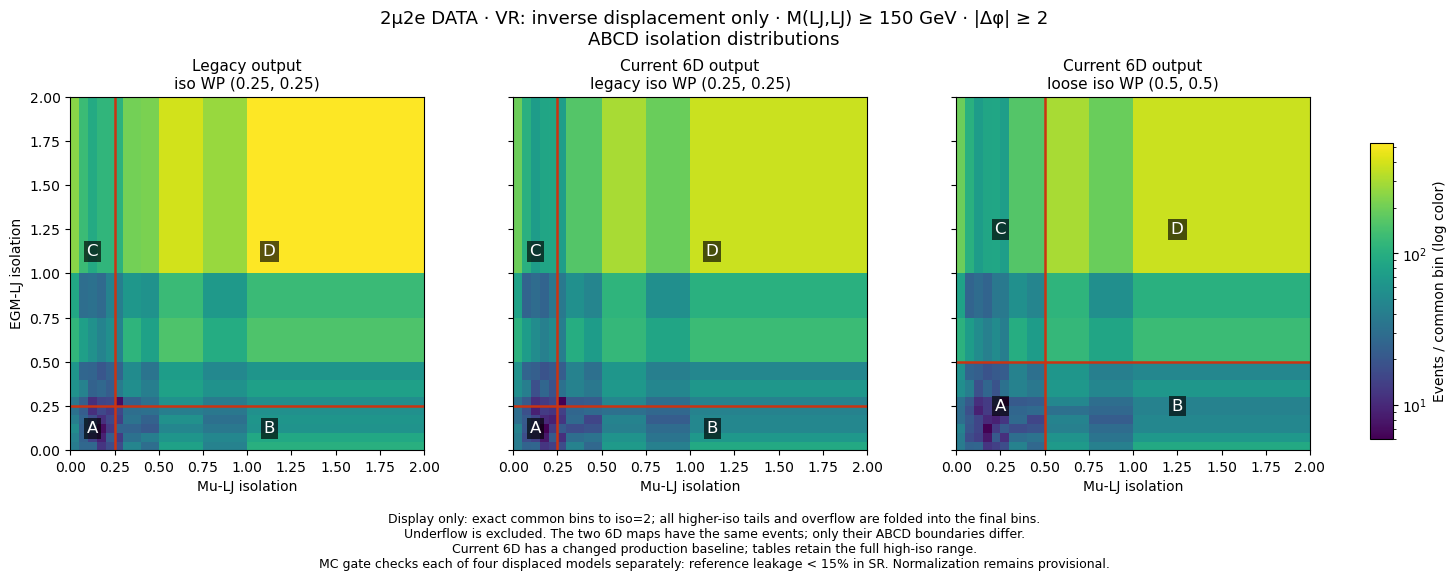

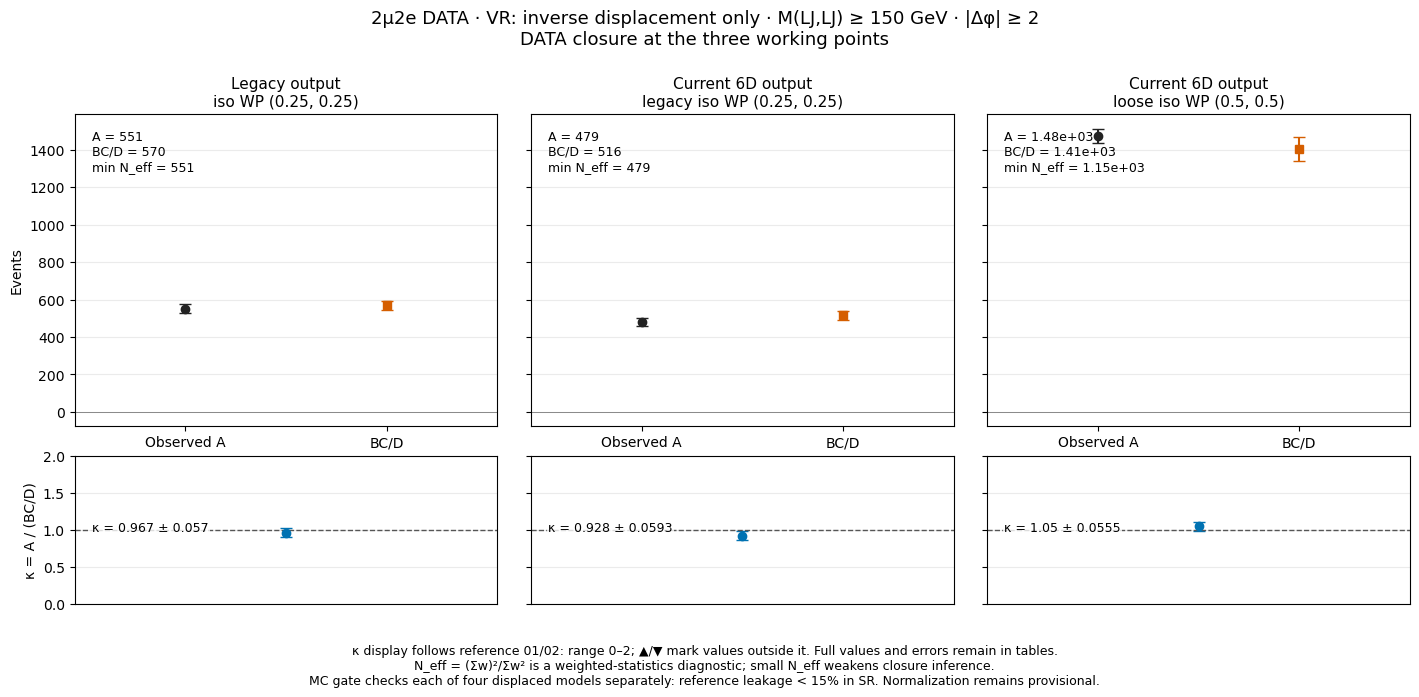

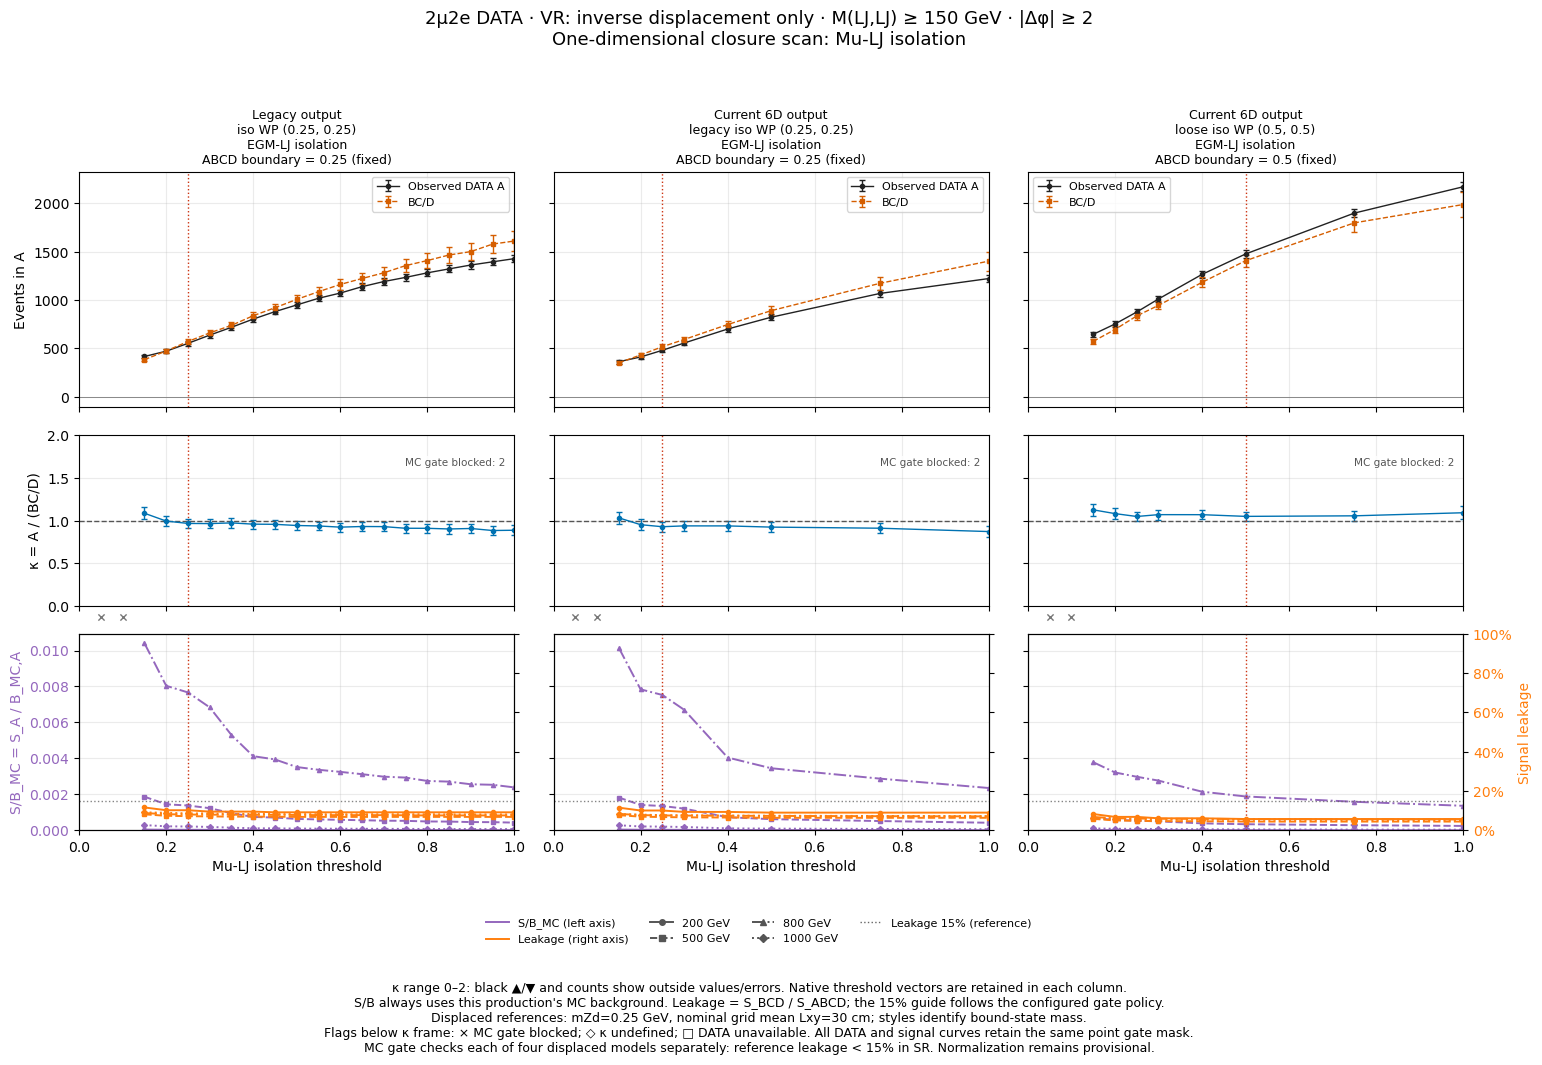

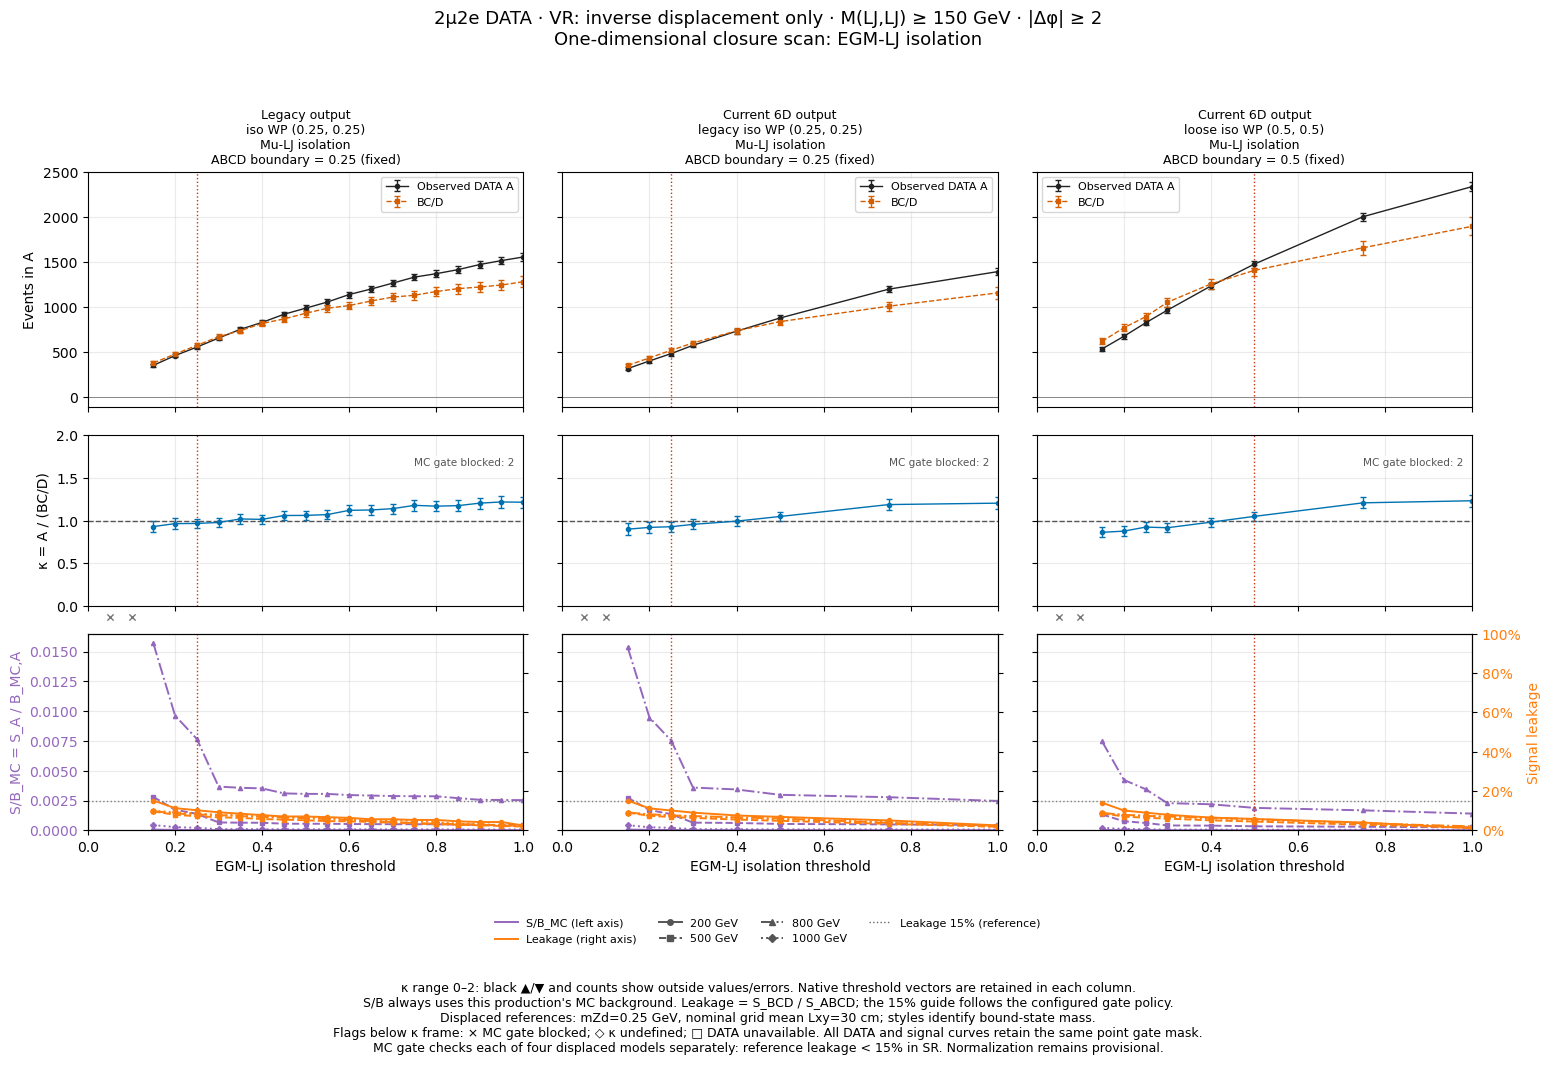

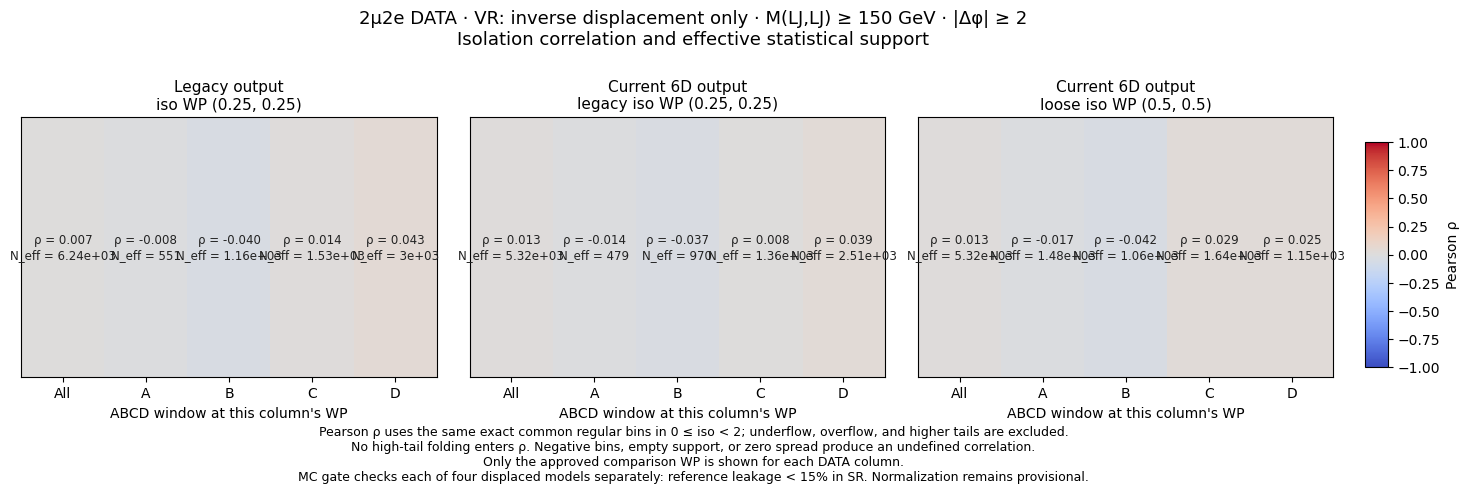

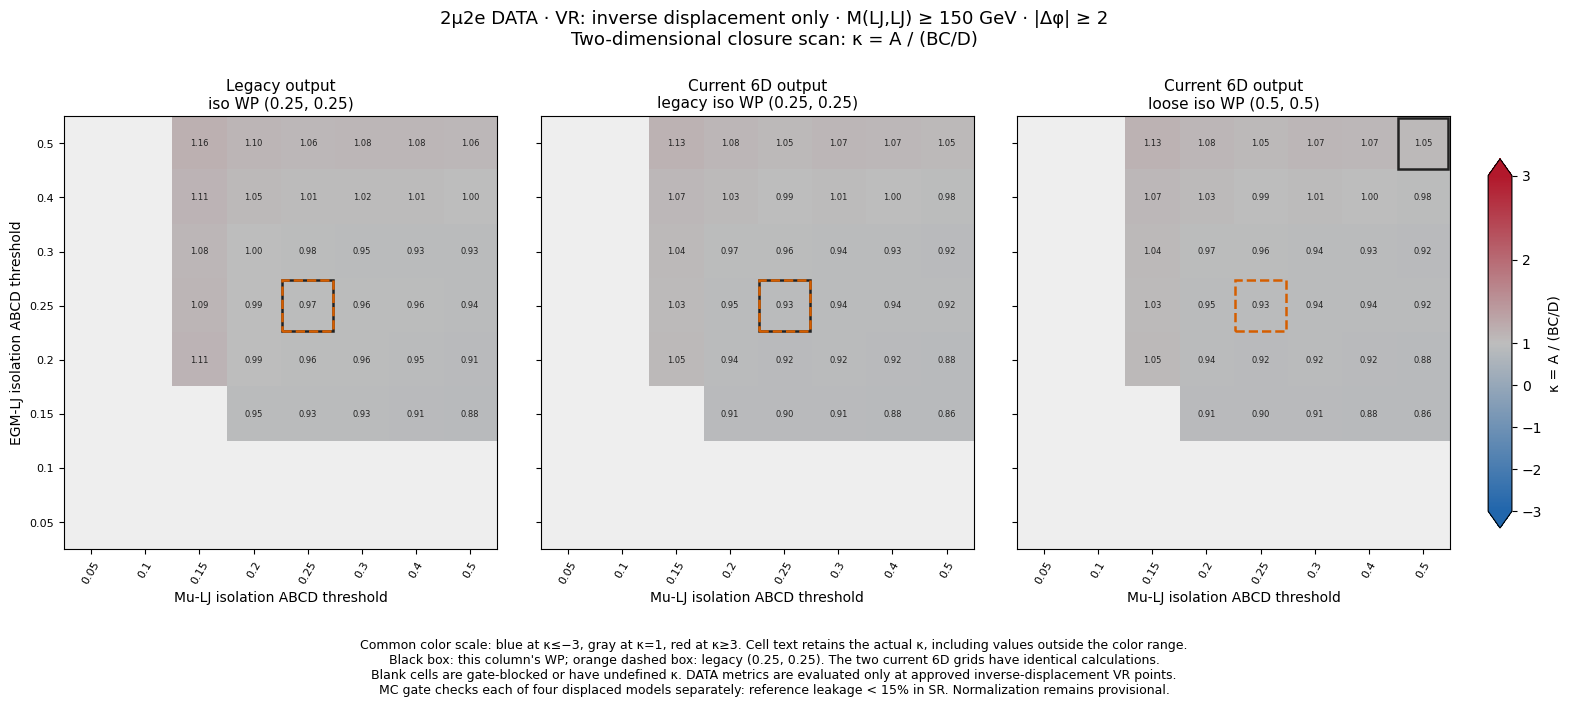

In [17]:
if RUN_DATA:
    present_figures(plot_distributions(DATA_RESULTS, DATA_CONFIG), source="DATA")
    present_figures(plot_closure(DATA_RESULTS, DATA_CONFIG), source="DATA")
    present_figures(plot_one_d_scans(DATA_RESULTS, DATA_CONFIG), source="DATA")
    present_figures(plot_correlations(DATA_RESULTS, DATA_CONFIG), source="DATA")
    present_figures(plot_kappa_grids(DATA_RESULTS, DATA_CONFIG), source="DATA")
else:
    print("DATA VR comparison disabled by RUN_DATA=False.")


## 13. Background-estimation strategy and slide foundations

The initial strategy starts with the raw SR control-region estimate $P_{\mathrm{SR,Data}}=B_{\mathrm{Data}}C_{\mathrm{Data}}/D_{\mathrm{Data}}$. Validate the iso–iso construction in the displacement-inverted VR, then examine MC transferability through $R_\kappa=\kappa_{\mathrm{SR,MC}}/\kappa_{\mathrm{VR,MC}}$. A/B/C/D are disjoint within each individual plane. Legacy SR and VR can share multi-LJ events after their separate LJ filtering and pair reselection, so the historical transfer-ratio uncertainty neglects an unavailable covariance; for the current fixed pair, nominal and double-inverse displacement selections are disjoint. Notebook 10 compared the raw SR prediction, $\kappa_{\mathrm{VR,Data}}P_{\mathrm{SR,Data}}$, and $\kappa_{\mathrm{SR,MC}}P_{\mathrm{SR,Data}}$ as candidate estimates; it did not establish a final correction or modelling uncertainty. The MC comparison and conditional VR DATA validation do not select or fit one of those SR candidates.

| Stage | Implemented construction | Role and limitation |
|---|---|---|
| [Initial closure study — 10](../ABCD_Study/10_ABCD_CV_full_analysis.ipynb) | Raw $BC/D$, VR closure, MC SR/VR $\kappa$ transfer, corrected prediction candidates | Defines the initial (0.25, 0.25) comparison; DATA SR A stays blinded |
| [MC counting baseline — 11](../ABCD_Study/11_ABCD_CV_MC_Counting_Expected_Limit.ipynb) | Direct SR A MC background in a counting model | Background-only Asimov expected-limit baseline |
| [Plug-in ABCD — 12](../ABCD_Study/12_ABCD_CV_Plugin_ABCD_Expected_Limit.ipynb) | SR MC $\kappa$ times DATA $BC/D$; propagated background variance | Intermediate counting approximation; DATA SR A excluded |
| [Simultaneous ABCD — 13](../ABCD_Study/13_ABCD_CV_Simultaneous_ABCD_Expected_Limit.ipynb) | B/C/D Poisson terms, A=$\kappa BC/D$, signal in all four regions | MC background Asimov study; closure modelling uncertainty not yet included |
| Current 6D comparison — 05/06 | Initial cuts projected from 6D, compared with old output and a loose iso case | Tests reproduction and documents selection/output changes |
| Pending decisions | Final baseline/WP, VR validity, transfer model, uncertainties, DATA scope | Require evidence beyond a matched MC projection |

The 2μ2e WP in notebooks 11–13 is (0.25, 0.10); their likelihood studies therefore do not set this notebook's WP. Their 4μ WP is (0.25, 0.25). Keep these historical alternatives distinct from the two-channel initial reproduction.

The 6D summary studies and [03](03_Iso_iso_VR_data_safety_study.ipynb) also leave signal-normalization evidence, contamination criteria, and the protected SR/DATA release scope under review. Validation in a VR does not alone establish an unbiased SR estimate. Use the tables here to show what was reproduced, what changed, what is limited by MC statistics, and what decision remains open.

In [18]:
estimation_strategy = pd.DataFrame([('Initial study (10)', 'P = B*C/D; kappa = A/P', 'VR DATA closure, SR DATA B/C/D prediction; MC composition and transferability', 'Correction and modeling uncertainty not finalized', '0.25 / 0.25 in both channels'), ('MC counting (11)', 'Direct SR-A MC background', 'Background-only MC Asimov baseline', 'Not the final DATA-driven estimator', '2mu2e 0.25 / 0.10; historical reference only'), ('Plug-in ABCD (12)', 'kappa_SR_MC * B_DATA*C_DATA/D_DATA', 'DATA sidebands plus an MC closure factor', 'Propagated uncertainties collapsed into one background variance', '2mu2e 0.25 / 0.10; historical reference only'), ('Simultaneous ABCD (13)', 'A = kappa*B*C/D; fit four regions jointly', 'MC-only background Asimov; signal in ABCD included', 'Actual DATA fit and closure modeling uncertainty not established', '2mu2e 0.25 / 0.10; historical reference only'), ('Current 6D reproduction (05/06)', 'Compare P and kappa at legacy and loose isolation boundaries', 'Fresh legacy/current MC and conditional VR DATA with explicit selection and flow audit', 'Upstream baseline/pair differences prevent exact event equality', '0.25 / 0.25 and 0.50 / 0.50, mass>=150 and abs(dphi)>=2')],
    columns=["stage", "estimator", "inputs_and_role", "remaining_limit", "working_point_scope"])
slide_facts = make_slide_facts(results)
analysis_status = pd.DataFrame([
    ("Initial MC result", "Verified by fresh legacy reduction", "legacy_regression"),
    ("Visible cut boundaries", "Matched in 6D: mass>=150, abs(dphi)>=2, pixel/lost and isolation", "selection_audit"),
    ("Upstream event selection", "Differs: pass flags and fixed pair versus post-LJ reselection", "cutflow_audit"),
    ("6D object-cut provenance", "Unverified: production definitions absent from metadata", "selection_audit"),
    ("Statistics", "Per-region Neff and first-order uncertainties retained", "region_yields"),
    ("DATA comparison", "Late VR-only conditional validation; no SR DATA evaluation", "data_access"),
    ("Final background estimator", "Kappa correction and modeling uncertainty remain undecided", "estimation_strategy"),
], columns=["question", "current_status", "evidence_table"])
with pd.option_context("display.max_columns", None, "display.max_colwidth", 110):
    display(slide_facts)
    display(estimation_strategy)
    display(analysis_status)

data_slide_facts = data_tables["closure_summary"].copy()
data_slide_facts["source"] = "DATA VR"
data_slide_facts["scope"] = "Conditional two-reference signal gate; SR DATA excluded"
results["tables"]["data_VR_slide_facts"] = data_slide_facts
display(data_slide_facts)


,benchmark,context,tx,ty,A,B,C,D,pred,pred_error,kappa,kappa_error,neff_A,neff_min,status,mass_min_GeV,abs_dphi_min,data_loaded,interpretation
0,legacy_025,SR,0.25,0.25,31.003767,36.868713,12.143459,228.191738,1.962007,1.865866,15.802071,16.539297,5.233255,2.258404,LOW_STAT_SIDEBAND,150.0,2.0,False,Fresh legacy MC at the initial working point
1,legacy_025,VR,0.25,0.25,522.082398,1431.711980,1574.024265,3761.566297,599.098679,242.558931,0.871446,0.468643,7.982075,7.562783,LOW_STAT_SIDEBAND,150.0,2.0,False,Fresh legacy MC at the initial working point
2,sixd_025,SR,0.25,0.25,27.631400,36.555042,8.840629,227.479079,1.420656,1.532610,19.449743,22.933769,4.414477,1.432024,LOW_STAT_SIDEBAND,150.0,2.0,False,Initial working point on the current fixed-pair 6D baseline
3,sixd_025,VR,0.25,0.25,518.518398,1416.235383,1562.201202,3696.674225,598.495968,244.337661,0.866369,0.469472,7.875950,7.451687,LOW_STAT_SIDEBAND,150.0,2.0,False,Initial working point on the current fixed-pair 6D baseline
4,sixd_050,SR,0.50,0.50,40.324241,164.519639,77.881973,17.780297,720.635564,902.711360,0.055956,0.073182,7.077784,1.207381,LOW_STAT_SIDEBAND,150.0,2.0,False,Isolation boundary changed to 0.5 on the same current baseline
5,sixd_050,VR,0.50,0.50,2110.600206,1356.548843,1936.007513,1790.472646,1466.813110,364.400857,1.438902,0.545675,12.180568,12.180568,OK,150.0,2.0,False,Isolation boundary changed to 0.5 on the same current baseline


,stage,estimator,inputs_and_role,remaining_limit,working_point_scope
0,Initial study (10),P = B*C/D; kappa = A/P,"VR DATA closure, SR DATA B/C/D prediction; MC composition and transferability",Correction and modeling uncertainty not finalized,0.25 / 0.25 in both channels
1,MC counting (11),Direct SR-A MC background,Background-only MC Asimov baseline,Not the final DATA-driven estimator,2mu2e 0.25 / 0.10; historical reference only
2,Plug-in ABCD (12),kappa_SR_MC * B_DATA*C_DATA/D_DATA,DATA sidebands plus an MC closure factor,Propagated uncertainties collapsed into one background variance,2mu2e 0.25 / 0.10; historical reference only
3,Simultaneous ABCD (13),A = kappa*B*C/D; fit four regions jointly,MC-only background Asimov; signal in ABCD included,Actual DATA fit and closure modeling uncertainty not established,2mu2e 0.25 / 0.10; historical reference only
4,Current 6D reproduction (05/06),Compare P and kappa at legacy and loose isolation boundaries,Fresh legacy/current MC and conditional VR DATA with explicit selection and flow audit,Upstream baseline/pair differences prevent exact event equality,"0.25 / 0.25 and 0.50 / 0.50, mass>=150 and abs(dphi)>=2"


,question,current_status,evidence_table
0,Initial MC result,Verified by fresh legacy reduction,legacy_regression
1,Visible cut boundaries,"Matched in 6D: mass>=150, abs(dphi)>=2, pixel/lost and isolation",selection_audit
2,Upstream event selection,Differs: pass flags and fixed pair versus post-LJ reselection,cutflow_audit
3,6D object-cut provenance,Unverified: production definitions absent from metadata,selection_audit
4,Statistics,Per-region Neff and first-order uncertainties retained,region_yields
5,DATA comparison,Late VR-only conditional validation; no SR DATA evaluation,data_access
6,Final background estimator,Kappa correction and modeling uncertainty remain undecided,estimation_strategy


,benchmark,context,tx,ty,pred,pred_error,kappa,kappa_error,pull,status,...,vr_only_gate_max_fraction,vr_only_gate_worst,vr_only_gate_policy,reference_count,gate_reference_mode,envelope_policy,signal_normalization_verified,policy,source,scope
0,legacy_025,VR,0.25,0.25,569.894366,23.259684,0.966846,0.057041,-0.571766,OK,...,0.007610,mA800_VR_A,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,DATA VR,Conditional two-reference signal gate; SR DATA...
1,sixd_025,VR,0.25,0.25,516.008922,23.060151,0.928279,0.059329,-1.164073,OK,...,0.007472,mA800_VR_A,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,DATA VR,Conditional two-reference signal gate; SR DATA...
2,sixd_050,VR,0.50,0.50,1405.102459,64.585264,1.049746,0.055455,0.930211,OK,...,0.001882,mA800_VR_A,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,DATA VR,Conditional two-reference signal gate; SR DATA...


## 14. Export and interpretation

Save MC and conditional DATA VR tables, the signal reference and DATA access manifests, correlation summaries, complete κ grids/scans, and all three-column figures as CSV/PNG/PDF. Full κ values and uncertainties are retained even when the 1D display is limited to 0–2. Settings and hashes accompany the outputs.

The DATA section only selects, projects, integrates, displays, and exports the inverse-displacement VR. It never evaluates SR DATA. The four displaced-reference gate is a conditional diagnostic under provisional signal normalization, rather than a completed full-signal release policy or a final SR background estimate.


The DATA gate uses **SR signal leakage only**. Each of the four displaced references must independently satisfy
\(S_{BCD}/S_{ABCD}<0.15\); equality fails. Contamination \(S/(S+B_{MC})\) and VR leakage remain diagnostics and do not veto a point in this mode.
An empty, negative, or nonfinite signal support remains unsupported. `MC gate blocked` marks a failed reference-signal criterion, not a missing DATA file or an observed DATA closure test.


In [19]:
figure_audit = pd.DataFrame(FIGURE_RECORDS)
export_comparison(results, {"slide_facts": slide_facts,
    "estimation_strategy": estimation_strategy, "analysis_status": analysis_status,
    "figure_audit": figure_audit})
print("Complete: legacy / 6D / loose comparison, signal diagnostics and conditional VR DATA validation.")


Saved CSV tables and manifest to /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/05_Initial_ABCD_2mu2e_6D_comparison_outputs
Complete: legacy / 6D / loose comparison, signal diagnostics and conditional VR DATA validation.
